In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
pd.set_option('display.max_rows',1000)

In [2]:
def linear_regression(x, y):
    meanx = np.mean(x)
    meany = np.mean(y)
    sigmax  = np.std(x)
    sigmay  = np.std(y)
    sigmaxy = np.sum(np.multiply(x-meanx,y-meany))/(len(x)-1)
    m = sigmaxy/(sigmax*sigmax) 
    q = meany-m*meanx
    return m,q

In [3]:
def correlation_coefficient(df, col1, col2):
    x = df[col1]
    y = df[col2]

    mean_x = np.mean(x)
    mean_y = np.mean(y)

    numerator = np.sum((x - mean_x) * (y - mean_y))
    denominator_x = np.sum((x - mean_x)**2)
    denominator_y = np.sum((y - mean_y)**2)

    correlation_coefficient = numerator / np.sqrt(denominator_x * denominator_y)

    return correlation_coefficient

In [4]:
df_women = pd.read_csv('children-per-woman-un.csv')
df_gdp = pd.read_csv('gdp-per-capita-worldbank.csv')

In [5]:
df_women

,Entity,Code,Year,Fertility rate - Sex: all - Age: all - Variant: estimates
0,Afghanistan,AFG,1950,7.2484
1,Afghanistan,AFG,1951,7.2596
2,Afghanistan,AFG,1952,7.2601
3,Afghanistan,AFG,1953,7.2662
4,Afghanistan,AFG,1954,7.2542
...,...,...,...,...
18355,Zimbabwe,ZWE,2017,3.7064
18356,Zimbabwe,ZWE,2018,3.6591
18357,Zimbabwe,ZWE,2019,3.5994
18358,Zimbabwe,ZWE,2020,3.5451


In [6]:
#Testing merging on different columns
df_gdp

,Entity,Code,Year,"GDP per capita, PPP (constant 2017 international $)"
0,Afghanistan,AFG,2002,1280.4631
1,Afghanistan,AFG,2003,1292.3335
2,Afghanistan,AFG,2004,1260.0605
3,Afghanistan,AFG,2005,1352.3207
4,Afghanistan,AFG,2006,1366.9932
...,...,...,...,...
6341,Zimbabwe,ZWE,2017,2331.7808
6342,Zimbabwe,ZWE,2018,2399.6216
6343,Zimbabwe,ZWE,2019,2203.3967
6344,Zimbabwe,ZWE,2020,1990.3195


In [7]:
#Testing merging on different columns
df_women_gdp = pd.merge(df_women, df_gdp, on='Year', how='inner')

df_women_gdp_ = pd.merge(df_women, df_gdp, on='Code', how='inner')

#Merged on two columns
#It automatically removes any rows that do not have a match

df_women_gdp_2 = pd.merge(df_women, df_gdp, on=['Code', 'Year'], how='inner')

#Re-assigned the name to df_women_gdp

df_women_gdp = df_women_gdp_2

df_women_gdp

,Entity_x,Code,Year,Fertility rate - Sex: all - Age: all - Variant: estimates,Entity_y,"GDP per capita, PPP (constant 2017 international $)"
0,Afghanistan,AFG,2002,7.3394,Afghanistan,1280.4631
1,Afghanistan,AFG,2003,7.2199,Afghanistan,1292.3335
2,Afghanistan,AFG,2004,7.0686,Afghanistan,1260.0605
3,Afghanistan,AFG,2005,6.9047,Afghanistan,1352.3207
4,Afghanistan,AFG,2006,6.7215,Afghanistan,1366.9932
...,...,...,...,...,...,...
12997,Zimbabwe,ZWE,2017,3.7064,Zimbabwe,2331.7808
12998,Zimbabwe,ZWE,2018,3.6591,Zimbabwe,2399.6216
12999,Zimbabwe,ZWE,2019,3.5994,Zimbabwe,2203.3967
13000,Zimbabwe,ZWE,2020,3.5451,Zimbabwe,1990.3195


In [8]:
#Removing any duplicate data in the dataset
df_no_duplicates = df_women_gdp.drop_duplicates(subset=['Code', 'Year'])

df_no_duplicates

,Entity_x,Code,Year,Fertility rate - Sex: all - Age: all - Variant: estimates,Entity_y,"GDP per capita, PPP (constant 2017 international $)"
0,Afghanistan,AFG,2002,7.3394,Afghanistan,1280.4631
1,Afghanistan,AFG,2003,7.2199,Afghanistan,1292.3335
2,Afghanistan,AFG,2004,7.0686,Afghanistan,1260.0605
3,Afghanistan,AFG,2005,6.9047,Afghanistan,1352.3207
4,Afghanistan,AFG,2006,6.7215,Afghanistan,1366.9932
...,...,...,...,...,...,...
12997,Zimbabwe,ZWE,2017,3.7064,Zimbabwe,2331.7808
12998,Zimbabwe,ZWE,2018,3.6591,Zimbabwe,2399.6216
12999,Zimbabwe,ZWE,2019,3.5994,Zimbabwe,2203.3967
13000,Zimbabwe,ZWE,2020,3.5451,Zimbabwe,1990.3195


In [9]:
#Shows all unique names in the dataset
#Testing to see if merge worked 

unique_names_list = df_no_duplicates['Entity_x'].unique().tolist()
print(unique_names_list)
print('')
print(df_women_gdp.columns)


['Afghanistan', 'Africa (UN)', 'Albania', 'Algeria', 'Angola', 'Antigua and Barbuda', 'Argentina', 'Armenia', 'Aruba', 'Australia', 'Austria', 'Azerbaijan', 'Bahamas', 'Bahrain', 'Bangladesh', 'Barbados', 'Belarus', 'Belgium', 'Belize', 'Benin', 'Bermuda', 'Bhutan', 'Bolivia', 'Bosnia and Herzegovina', 'Botswana', 'Brazil', 'Brunei', 'Bulgaria', 'Burkina Faso', 'Burundi', 'Cambodia', 'Cameroon', 'Canada', 'Cape Verde', 'Cayman Islands', 'Central African Republic', 'Chad', 'Chile', 'China', 'Colombia', 'Comoros', 'Congo', 'Costa Rica', "Cote d'Ivoire", 'Croatia', 'Curacao', 'Cyprus', 'Czechia', 'Democratic Republic of Congo', 'Denmark', 'Djibouti', 'Dominica', 'Dominican Republic', 'East Timor', 'Ecuador', 'Egypt', 'El Salvador', 'Equatorial Guinea', 'Estonia', 'Eswatini', 'Ethiopia', 'Fiji', 'Finland', 'France', 'Gabon', 'Gambia', 'Georgia', 'Germany', 'Ghana', 'Greece', 'Grenada', 'Guatemala', 'Guinea', 'Guinea-Bissau', 'Guyana', 'Haiti', 'Honduras', 'Hong Kong', 'Hungary', 'Iceland',

In [10]:
# Continent mapping
continent_mapping = {
    'Afghanistan': 'Asia', 'Africa (UN)': 'Africa', 'Albania': 'Europe', 'Algeria': 'Africa', 'Angola': 'Africa', 'Antigua and Barbuda': 'North America',
    'Argentina': 'South America', 'Armenia': 'Asia', 'Aruba': 'North America', 'Australia': 'Oceania', 'Austria': 'Europe', 'Azerbaijan': 'Asia',
    'Bahamas': 'North America', 'Bahrain': 'Asia', 'Bangladesh': 'Asia', 'Barbados': 'North America', 'Belarus': 'Europe', 'Belgium': 'Europe',
    'Belize': 'North America', 'Benin': 'Africa', 'Bermuda': 'North America', 'Bhutan': 'Asia', 'Bolivia': 'South America', 'Bosnia and Herzegovina': 'Europe',
    'Botswana': 'Africa', 'Brazil': 'South America', 'Brunei': 'Asia', 'Bulgaria': 'Europe', 'Burkina Faso': 'Africa', 'Burundi': 'Africa', 'Cambodia': 'Asia',
    'Cameroon': 'Africa', 'Canada': 'North America', 'Cape Verde': 'Africa', 'Cayman Islands': 'North America', 'Central African Republic': 'Africa',
    'Chad': 'Africa', 'Chile': 'South America', 'China': 'Asia', 'Colombia': 'South America', 'Comoros': 'Africa', 'Congo': 'Africa', 'Costa Rica': 'North America',
    "Cote d'Ivoire": 'Africa', 'Croatia': 'Europe', 'Curacao': 'North America', 'Cyprus': 'Asia', 'Czechia': 'Europe', 'Democratic Republic of Congo': 'Africa',
    'Denmark': 'Europe', 'Djibouti': 'Africa', 'Dominica': 'North America', 'Dominican Republic': 'North America', 'East Timor': 'Asia', 'Ecuador': 'South America',
    'Egypt': 'Africa', 'El Salvador': 'North America', 'Equatorial Guinea': 'Africa', 'Estonia': 'Europe', 'Eswatini': 'Africa', 'Ethiopia': 'Africa', 'Fiji': 'Oceania',
    'Finland': 'Europe', 'France': 'Europe', 'Gabon': 'Africa', 'Gambia': 'Africa', 'Georgia': 'Asia', 'Germany': 'Europe', 'Ghana': 'Africa', 'Greece': 'Europe',
    'Grenada': 'North America', 'Guatemala': 'North America', 'Guinea': 'Africa', 'Guinea-Bissau': 'Africa', 'Guyana': 'South America', 'Haiti': 'North America',
    'Honduras': 'North America', 'Hong Kong': 'Asia', 'Hungary': 'Europe', 'Iceland': 'Europe', 'India': 'Asia', 'Indonesia': 'Asia', 'Iran': 'Asia', 'Iraq': 'Asia',
    'Ireland': 'Europe', 'Israel': 'Asia', 'Italy': 'Europe', 'Jamaica': 'North America', 'Japan': 'Asia', 'Jordan': 'Asia', 'Kazakhstan': 'Asia', 'Kenya': 'Africa',
    'Kiribati': 'Oceania', 'Kosovo': 'Europe', 'Kuwait': 'Asia', 'Kyrgyzstan': 'Asia', 'Laos': 'Asia', 'Latvia': 'Europe', 'Lebanon': 'Asia', 'Lesotho': 'Africa',
    'Liberia': 'Africa', 'Libya': 'Africa', 'Lithuania': 'Europe', 'Luxembourg': 'Europe', 'Macao': 'Asia', 'Madagascar': 'Africa', 'Malawi': 'Africa', 'Malaysia': 'Asia',
    'Maldives': 'Asia', 'Mali': 'Africa', 'Malta': 'Europe', 'Marshall Islands': 'Oceania', 'Mauritania': 'Africa', 'Mauritius': 'Africa', 'Mexico': 'North America',
    'Micronesia (country)': 'Oceania', 'Moldova': 'Europe', 'Mongolia': 'Asia', 'Montenegro': 'Europe', 'Morocco': 'Africa', 'Mozambique': 'Africa', 'Myanmar': 'Asia',
    'Namibia': 'Africa', 'Nauru': 'Oceania', 'Nepal': 'Asia', 'Netherlands': 'Europe', 'New Zealand': 'Oceania', 'Nicaragua': 'North America', 'Niger': 'Africa',
    'Nigeria': 'Africa', 'North Macedonia': 'Europe', 'Norway': 'Europe', 'Oman': 'Asia', 'Pakistan': 'Asia', 'Palau': 'Oceania', 'Palestine': 'Asia',
    'Panama': 'North America', 'Papua New Guinea': 'Oceania', 'Paraguay': 'South America', 'Peru': 'South America', 'Philippines': 'Asia', 'Poland': 'Europe',
    'Portugal': 'Europe', 'Puerto Rico': 'North America', 'Qatar': 'Asia', 'Romania': 'Europe', 'Russia': 'Europe', 'Rwanda': 'Africa', 'Saint Kitts and Nevis': 'North America',
    'Saint Lucia': 'North America', 'Saint Vincent and the Grenadines': 'North America', 'Samoa': 'Oceania', 'San Marino': 'Europe', 'Sao Tome and Principe': 'Africa',
    'Saudi Arabia': 'Asia', 'Senegal': 'Africa', 'Serbia': 'Europe', 'Seychelles': 'Africa', 'Sierra Leone': 'Africa', 'Singapore': 'Asia',
    'Sint Maarten (Dutch part)': 'North America', 'Slovakia': 'Europe', 'Slovenia': 'Europe', 'Solomon Islands': 'Oceania', 'Somalia': 'Africa',
    'South Africa': 'Africa', 'South Korea': 'Asia', 'Spain': 'Europe', 'Sri Lanka': 'Asia', 'Sudan': 'Africa', 'Suriname': 'South America', 'Sweden': 'Europe',
    'Switzerland': 'Europe', 'Tajikistan': 'Asia', 'Tanzania': 'Africa', 'Thailand': 'Asia', 'Togo': 'Africa', 'Tonga': 'Oceania', 'Trinidad and Tobago': 'North America',
    'Tunisia': 'Africa', 'Turkey': 'Asia', 'Turkmenistan': 'Asia', 'Turks and Caicos Islands': 'North America', 'Tuvalu': 'Oceania', 'Uganda': 'Africa', 'Ukraine': 'Europe',
    'United Arab Emirates': 'Asia', 'United Kingdom': 'Europe', 'United States': 'North America', 'Uruguay': 'South America', 'Uzbekistan': 'Asia', 'Vanuatu': 'Oceania',
    'Vietnam': 'Asia', 'World': 'World', 'Zambia': 'Africa', 'Zimbabwe': 'Africa'
}

# Convert the dictionary to a DataFrame
continent_mapping_df = pd.DataFrame(list(continent_mapping.items()), columns=['Entity_x', 'Continent'])

# Merging the original DataFrame with the continent mapping
df_women_gdp = pd.merge(df_women_gdp, continent_mapping_df, on='Entity_x', how='left')

print(df_women_gdp)


          Entity_x Code  Year  \
0      Afghanistan  AFG  2002   
1      Afghanistan  AFG  2003   
2      Afghanistan  AFG  2004   
3      Afghanistan  AFG  2005   
4      Afghanistan  AFG  2006   
...            ...  ...   ...   
12997     Zimbabwe  ZWE  2017   
12998     Zimbabwe  ZWE  2018   
12999     Zimbabwe  ZWE  2019   
13000     Zimbabwe  ZWE  2020   
13001     Zimbabwe  ZWE  2021   

       Fertility rate - Sex: all - Age: all - Variant: estimates     Entity_y  \
0                                                 7.3394          Afghanistan   
1                                                 7.2199          Afghanistan   
2                                                 7.0686          Afghanistan   
3                                                 6.9047          Afghanistan   
4                                                 6.7215          Afghanistan   
...                                                  ...                  ...   
12997                               

In [11]:
# Display the original column names
print("Original Column Names:")
print(df_women_gdp.columns)

# Rename columns
df_women_gdp = df_women_gdp.rename(columns={'Fertility rate - Sex: all - Age: all - Variant: estimates': 'Fertility_rate', 'GDP per capita, PPP (constant 2017 international $)': 'GDP_Per_Capita'})

# Display the updated column names
print("\nUpdated Column Names:")
print(df_women_gdp.columns)


Original Column Names:
Index(['Entity_x', 'Code', 'Year',
       'Fertility rate - Sex: all - Age: all - Variant: estimates', 'Entity_y',
       'GDP per capita, PPP (constant 2017 international $)', 'Continent'],
      dtype='object')

Updated Column Names:
Index(['Entity_x', 'Code', 'Year', 'Fertility_rate', 'Entity_y',
       'GDP_Per_Capita', 'Continent'],
      dtype='object')


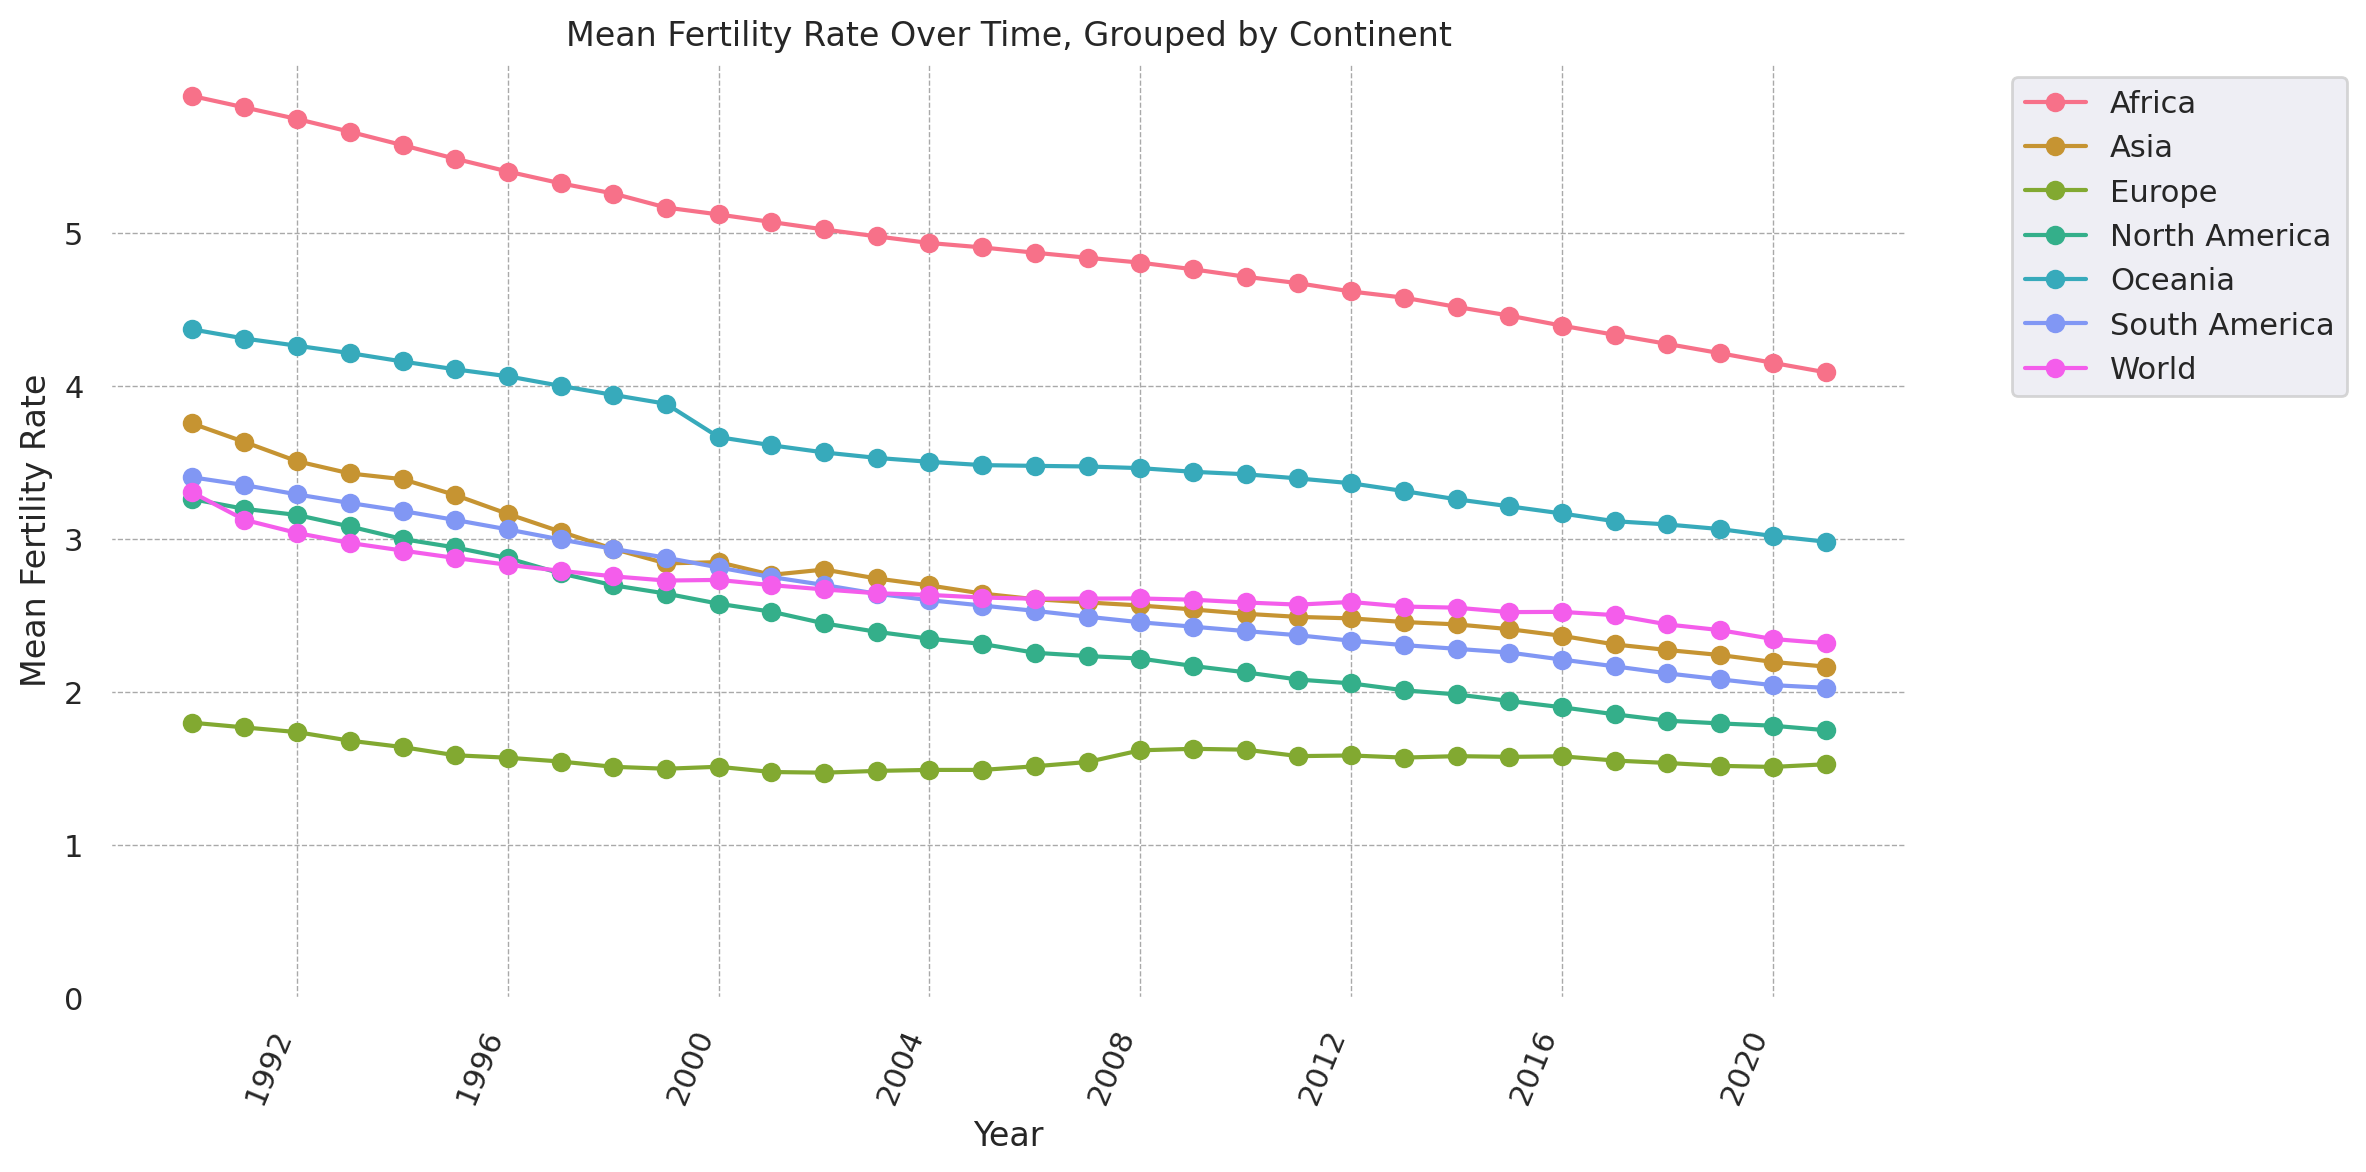

In [12]:
df_women_gdp['Year'] = pd.to_datetime(df_women_gdp['Year'], format='%Y')

# Using seaborn for a better appearance
sns.set(style="darkgrid")

# Grouping the data by continent and year, calculating the mean fertility rate
numeric_columns = df_women_gdp.select_dtypes(include='number').columns
grouped_df = df_women_gdp.groupby(['Continent', 'Year'])[numeric_columns].mean().reset_index()

# Plotting the mean fertility rate against Year for each continent
plt.figure(figsize=(12, 6))

# Define a color palette for each continent
palette = sns.color_palette("husl", n_colors=len(grouped_df['Continent'].unique()))

for i, (name, group) in enumerate(grouped_df.groupby('Continent')):
    plt.plot(group['Year'], group['Fertility_rate'], marker='o', label=name, color=palette[i])

plt.title('Mean Fertility Rate Over Time, Grouped by Continent')
plt.xlabel('Year')
plt.ylabel('Mean Fertility Rate')

# Move the legend outside the plot
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

# Include each year in the plot and set y-axis to start from 0
plt.xticks(rotation=67.5, ha='right')
plt.yticks(range(0, int(grouped_df['Fertility_rate'].max()) + 1))
plt.grid(True)
plt.tight_layout()

plt.gca().set_facecolor('white')

plt.grid(color='darkgrey', linestyle='dashed', linewidth=0.5)

plt.show()


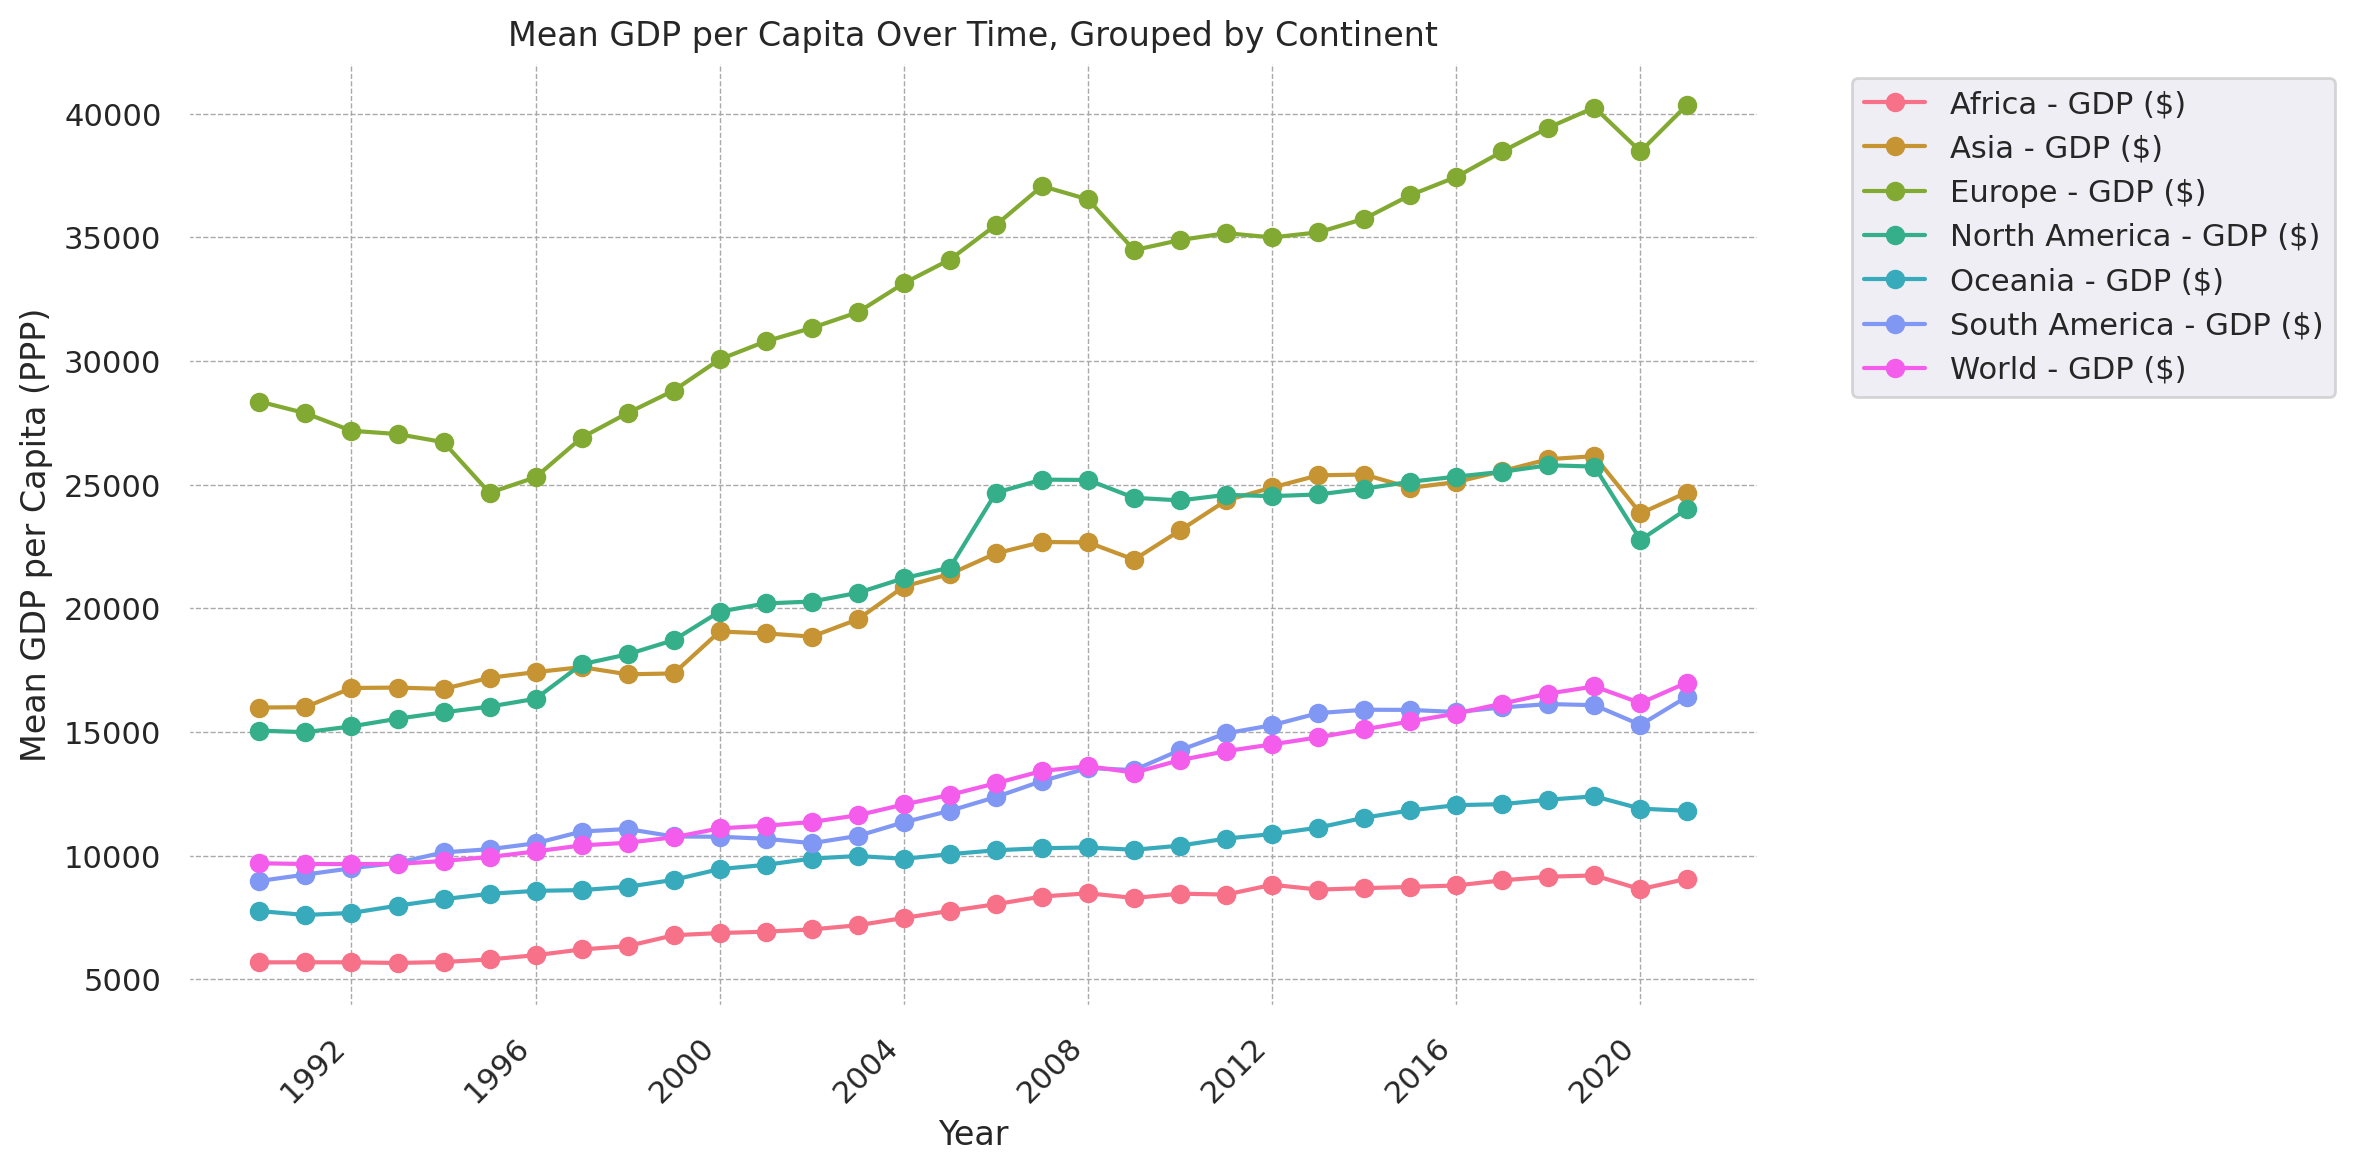

In [13]:
df_women_gdp['Year'] = pd.to_datetime(df_women_gdp['Year'], format='%Y')

# Using seaborn for a better appearance
sns.set(style="darkgrid")

# Grouping the data by continent and year, calculating the mean GDP per capita
numeric_columns = df_women_gdp.select_dtypes(include='number').columns
grouped_df = df_women_gdp.groupby(['Continent', 'Year'])[numeric_columns].mean().reset_index()

# Plotting the mean GDP per capita against Year for each continent
plt.figure(figsize=(12, 6))

# Define a color palette for each continent
palette = sns.color_palette("husl", n_colors=len(grouped_df['Continent'].unique()))

for i, (name, group) in enumerate(grouped_df.groupby('Continent')):
    plt.plot(group['Year'], group['GDP_Per_Capita'], marker='o', label=f'{name} - GDP ($)', color=palette[i])

plt.title('Mean GDP per Capita Over Time, Grouped by Continent')
plt.xlabel('Year')
plt.ylabel('Mean GDP per Capita (PPP)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=45, ha='right')
plt.grid(True)
plt.tight_layout()

plt.gca().set_facecolor('white')

plt.grid(color='darkgrey', linestyle='dashed', linewidth=0.5)

plt.show()


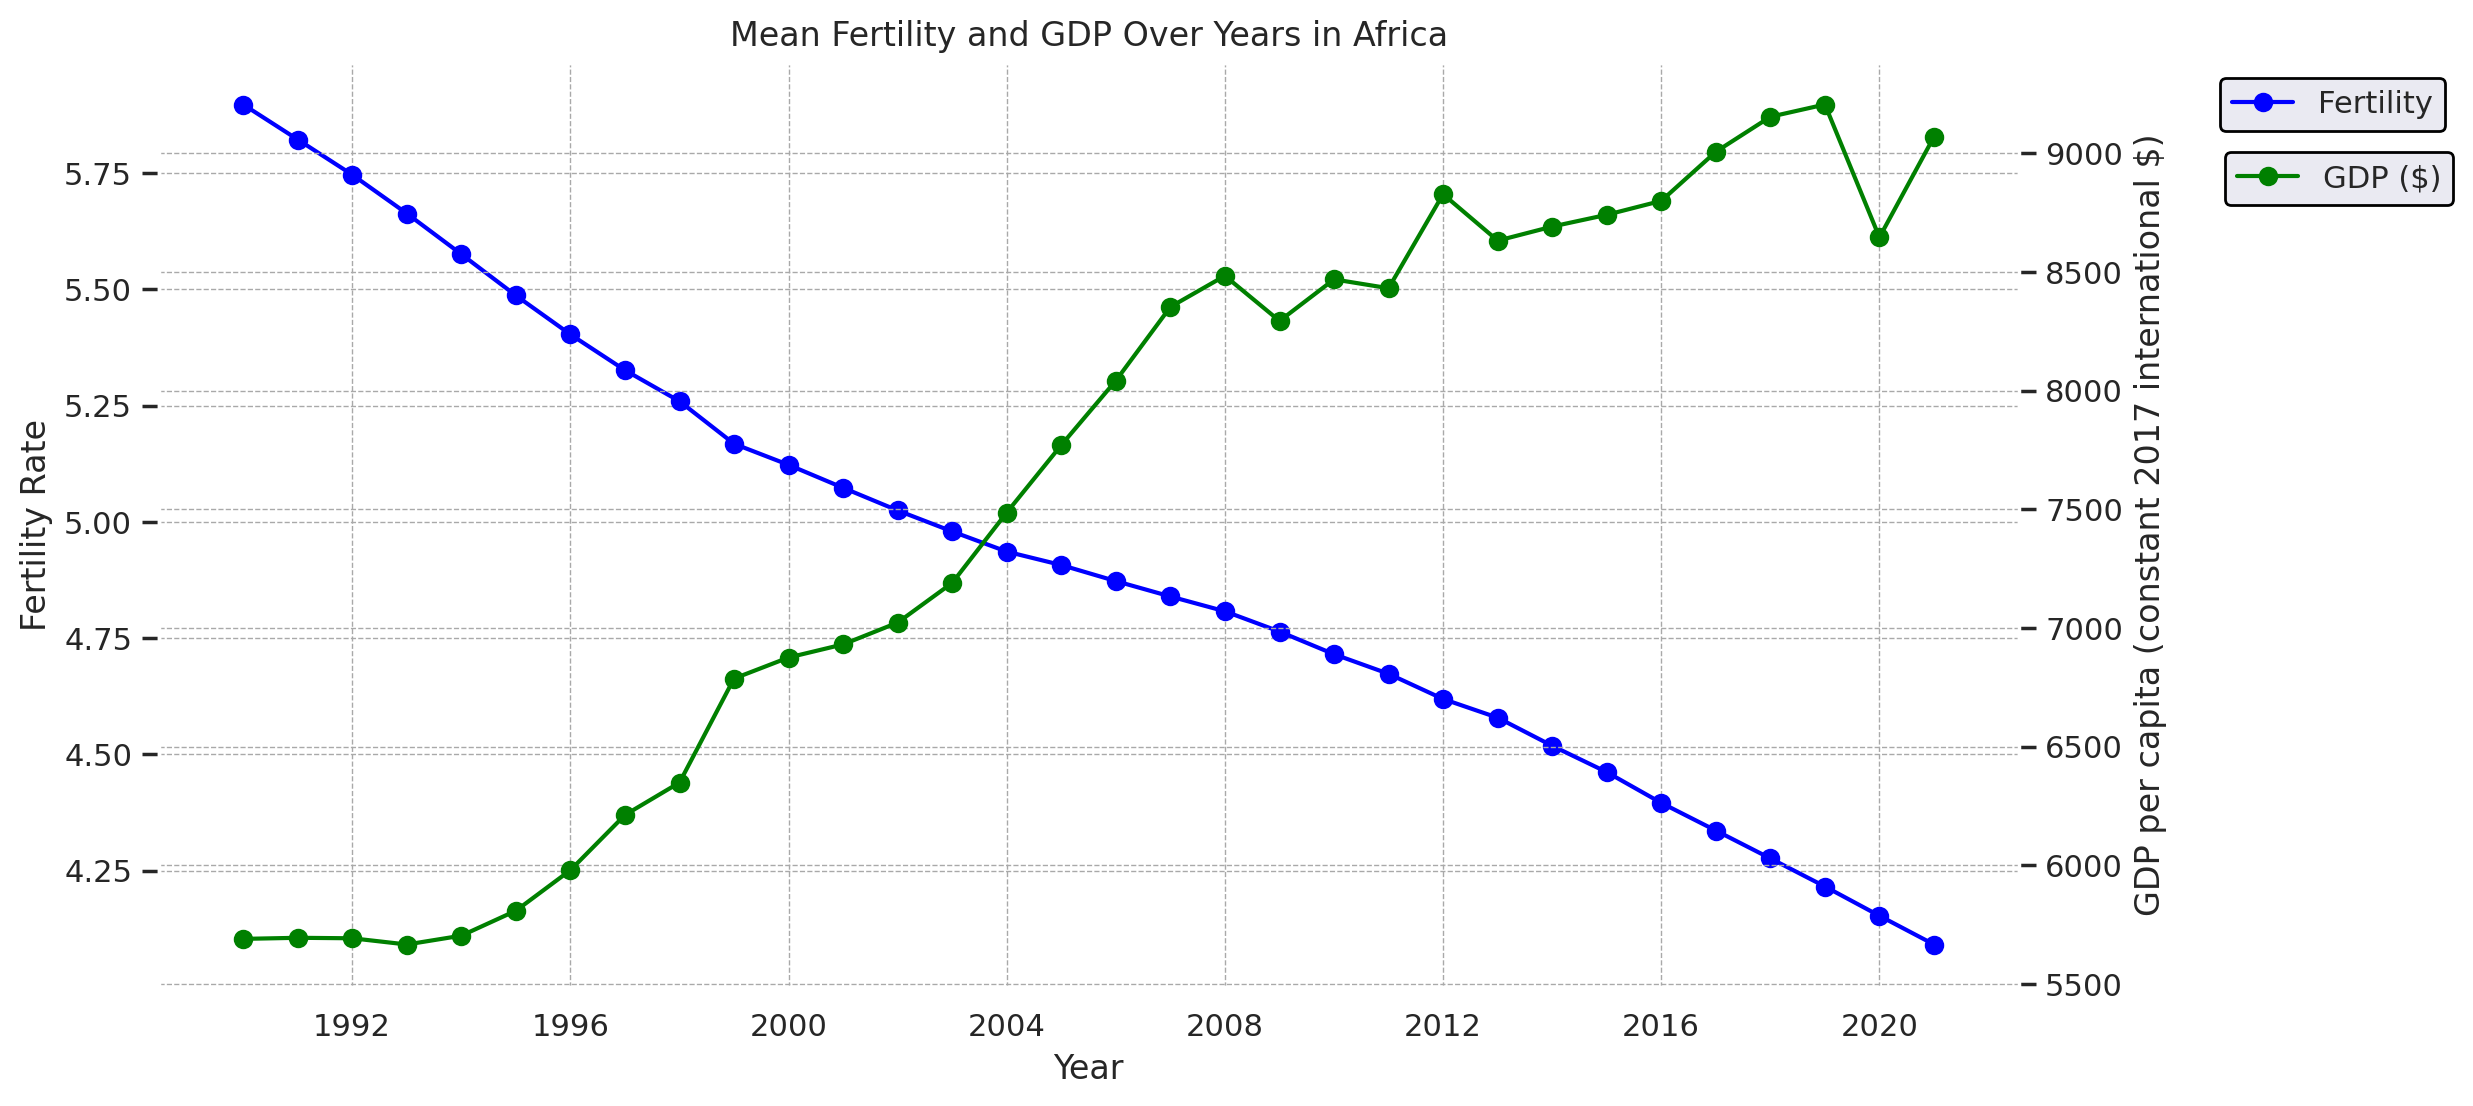

In [14]:
# Filter data for Africa
africa_df = df_women_gdp[df_women_gdp['Continent'] == 'Africa']

# Grouping by Year and calculating the mean for each column
numeric_columns = africa_df.select_dtypes(include='number').columns
mean_by_year = africa_df.groupby('Year')[numeric_columns].mean().reset_index()

# Create a figure with a secondary y-axis
fig, ax1 = plt.subplots(figsize=(12, 6))

# Plotting Fertility against Year on the primary y-axis
ax1.plot(mean_by_year['Year'],
         mean_by_year['Fertility_rate'],
         color='blue',
         marker='o',
         label='Fertility')

ax1.set_xlabel('Year')
ax1.set_ylabel('Fertility Rate')

# Create a secondary y-axis for GDP
ax2 = ax1.twinx()
ax2.plot(mean_by_year['Year'],
         mean_by_year['GDP_Per_Capita'],
         color='green',
         marker='o',
         label='GDP ($)')

ax2.set_ylabel('GDP per capita (constant 2017 international $)')

# Set background color to white
ax1.set_facecolor('white')
ax2.set_facecolor('white')

# Set grid color to dark grey and grid style to dashed
ax1.grid(color='darkgrey', linestyle='dashed', linewidth=0.5)
ax2.grid(color='darkgrey', linestyle='dashed', linewidth=0.5)

# Move the legends to the top right with a black box around them
ax1.legend(bbox_to_anchor=(1.1, 1), loc='upper left', frameon=True, framealpha=1, edgecolor='black')
ax2.legend(bbox_to_anchor=(1.242, 0.92), loc='upper right', frameon=True, framealpha=1, edgecolor='black')

plt.title('Mean Fertility and GDP Over Years in Africa')
plt.show()


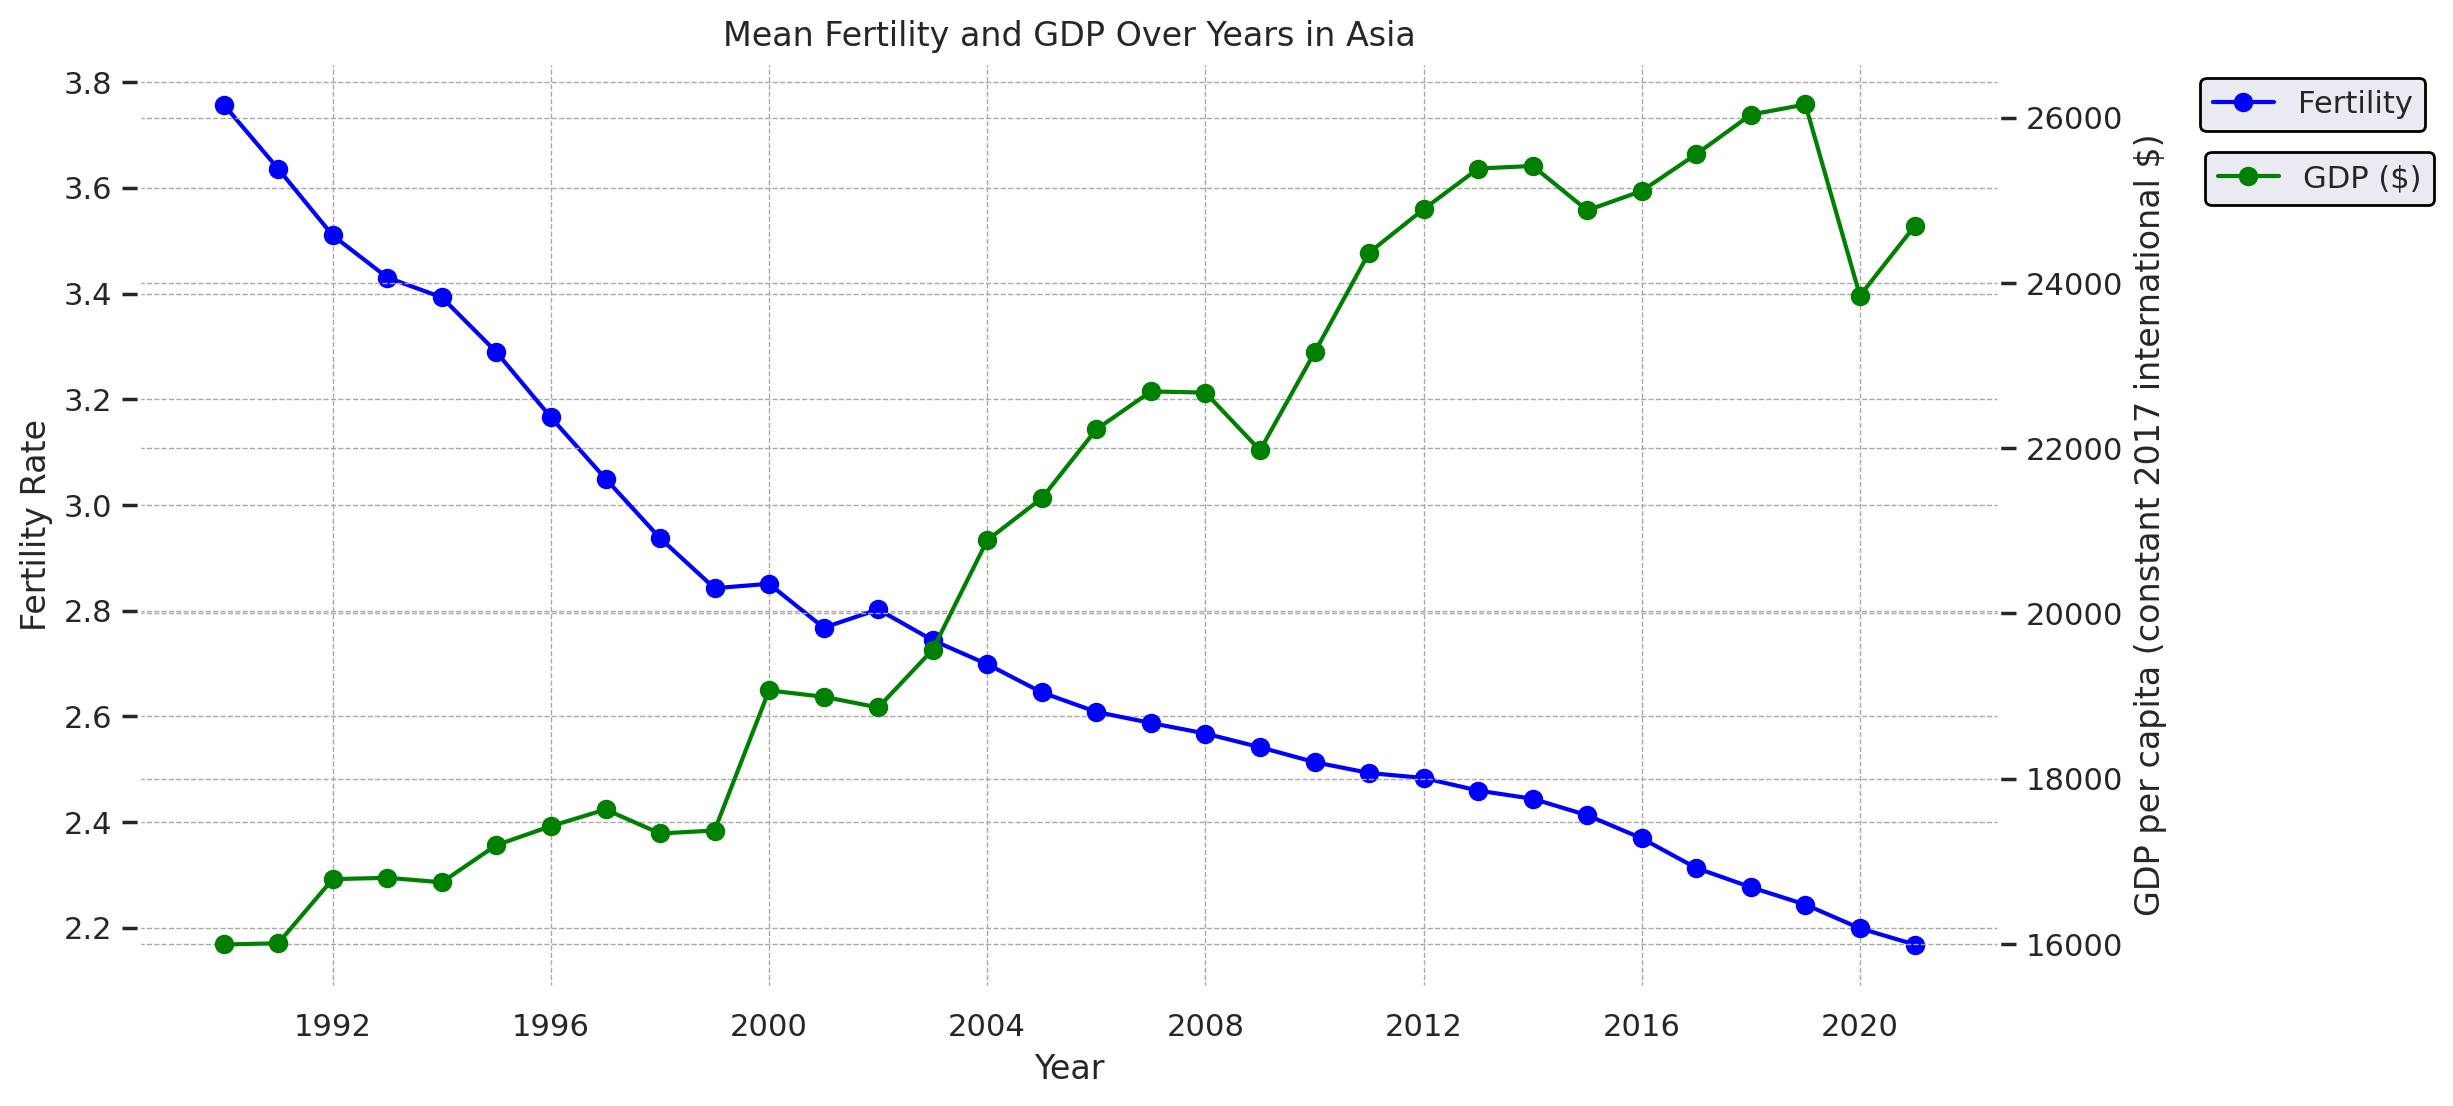

In [15]:
# Filter data for Asia
asia_df = df_women_gdp[df_women_gdp['Continent'] == 'Asia']

# Grouping by Year and calculating the mean for each column
numeric_columns = asia_df.select_dtypes(include='number').columns
mean_by_year_asia = asia_df.groupby('Year')[numeric_columns].mean().reset_index()

# Create a figure with a secondary y-axis
fig, ax1 = plt.subplots(figsize=(12, 6))

# Plotting Fertility against Year on the primary y-axis
ax1.plot(mean_by_year_asia['Year'],
         mean_by_year_asia['Fertility_rate'],
         color='blue',
         marker='o',
         label='Fertility')

ax1.set_xlabel('Year')
ax1.set_ylabel('Fertility Rate')

# Create a secondary y-axis for GDP
ax2 = ax1.twinx()
ax2.plot(mean_by_year_asia['Year'],
         mean_by_year_asia['GDP_Per_Capita'],
         color='green',
         marker='o',
         label='GDP ($)')

ax2.set_ylabel('GDP per capita (constant 2017 international $)')

# Set background color to white
ax1.set_facecolor('white')
ax2.set_facecolor('white')

# Set grid color to dark grey and grid style to dashed
ax1.grid(color='darkgrey', linestyle='dashed', linewidth=0.5)
ax2.grid(color='darkgrey', linestyle='dashed', linewidth=0.5)

# Move the legends to the top right with a black box around them
ax1.legend(bbox_to_anchor=(1.1, 1), loc='upper left', frameon=True, framealpha=1, edgecolor='black')
ax2.legend(bbox_to_anchor=(1.242, 0.92), loc='upper right', frameon=True, framealpha=1, edgecolor='black')

plt.title('Mean Fertility and GDP Over Years in Asia')
plt.show()


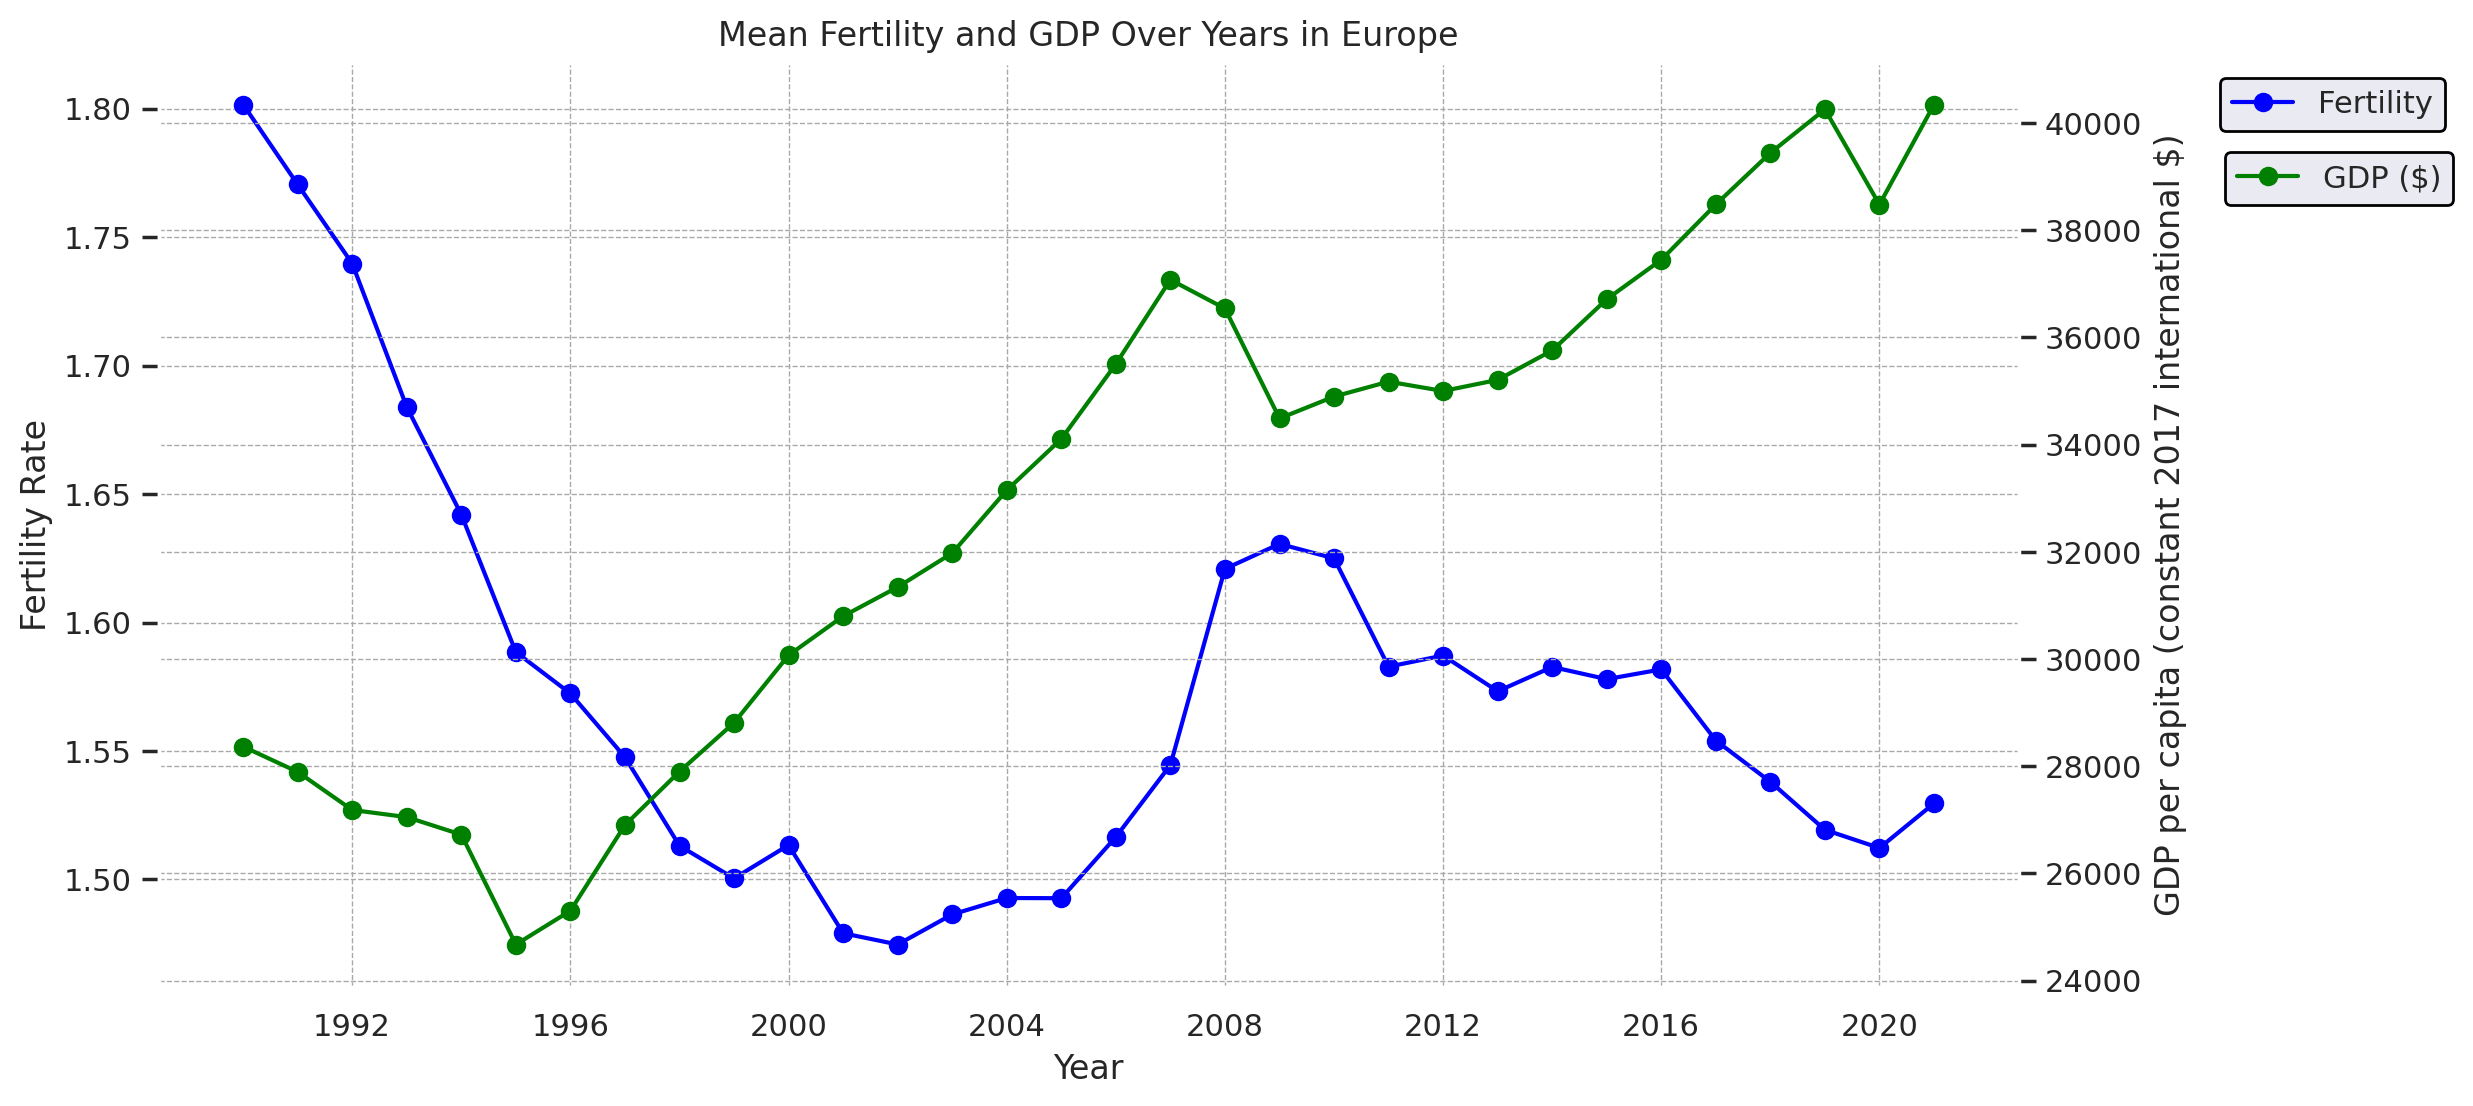

In [16]:
# Filter data for Europe
europe_df = df_women_gdp[df_women_gdp['Continent'] == 'Europe']

# Grouping by Year and calculating the mean for each column
numeric_columns = europe_df.select_dtypes(include='number').columns
mean_by_year_europe = europe_df.groupby('Year')[numeric_columns].mean().reset_index()

# Create a figure with a secondary y-axis
fig, ax1 = plt.subplots(figsize=(12, 6))

# Plotting Fertility against Year on the primary y-axis
ax1.plot(mean_by_year_europe['Year'],
         mean_by_year_europe['Fertility_rate'],
         color='blue',
         marker='o',
         label='Fertility')

ax1.set_xlabel('Year')
ax1.set_ylabel('Fertility Rate')

# Create a secondary y-axis for GDP
ax2 = ax1.twinx()
ax2.plot(mean_by_year_europe['Year'],
         mean_by_year_europe['GDP_Per_Capita'],
         color='green',
         marker='o',
         label='GDP ($)')

ax2.set_ylabel('GDP per capita (constant 2017 international $)')

# Set background color to white
ax1.set_facecolor('white')
ax2.set_facecolor('white')

# Set grid color to dark grey and grid style to dashed
ax1.grid(color='darkgrey', linestyle='dashed', linewidth=0.5)
ax2.grid(color='darkgrey', linestyle='dashed', linewidth=0.5)

# Move the legends to the top right with a black box around them
ax1.legend(bbox_to_anchor=(1.1, 1), loc='upper left', frameon=True, framealpha=1, edgecolor='black')
ax2.legend(bbox_to_anchor=(1.242, 0.92), loc='upper right', frameon=True, framealpha=1, edgecolor='black')

plt.title('Mean Fertility and GDP Over Years in Europe')
plt.show()


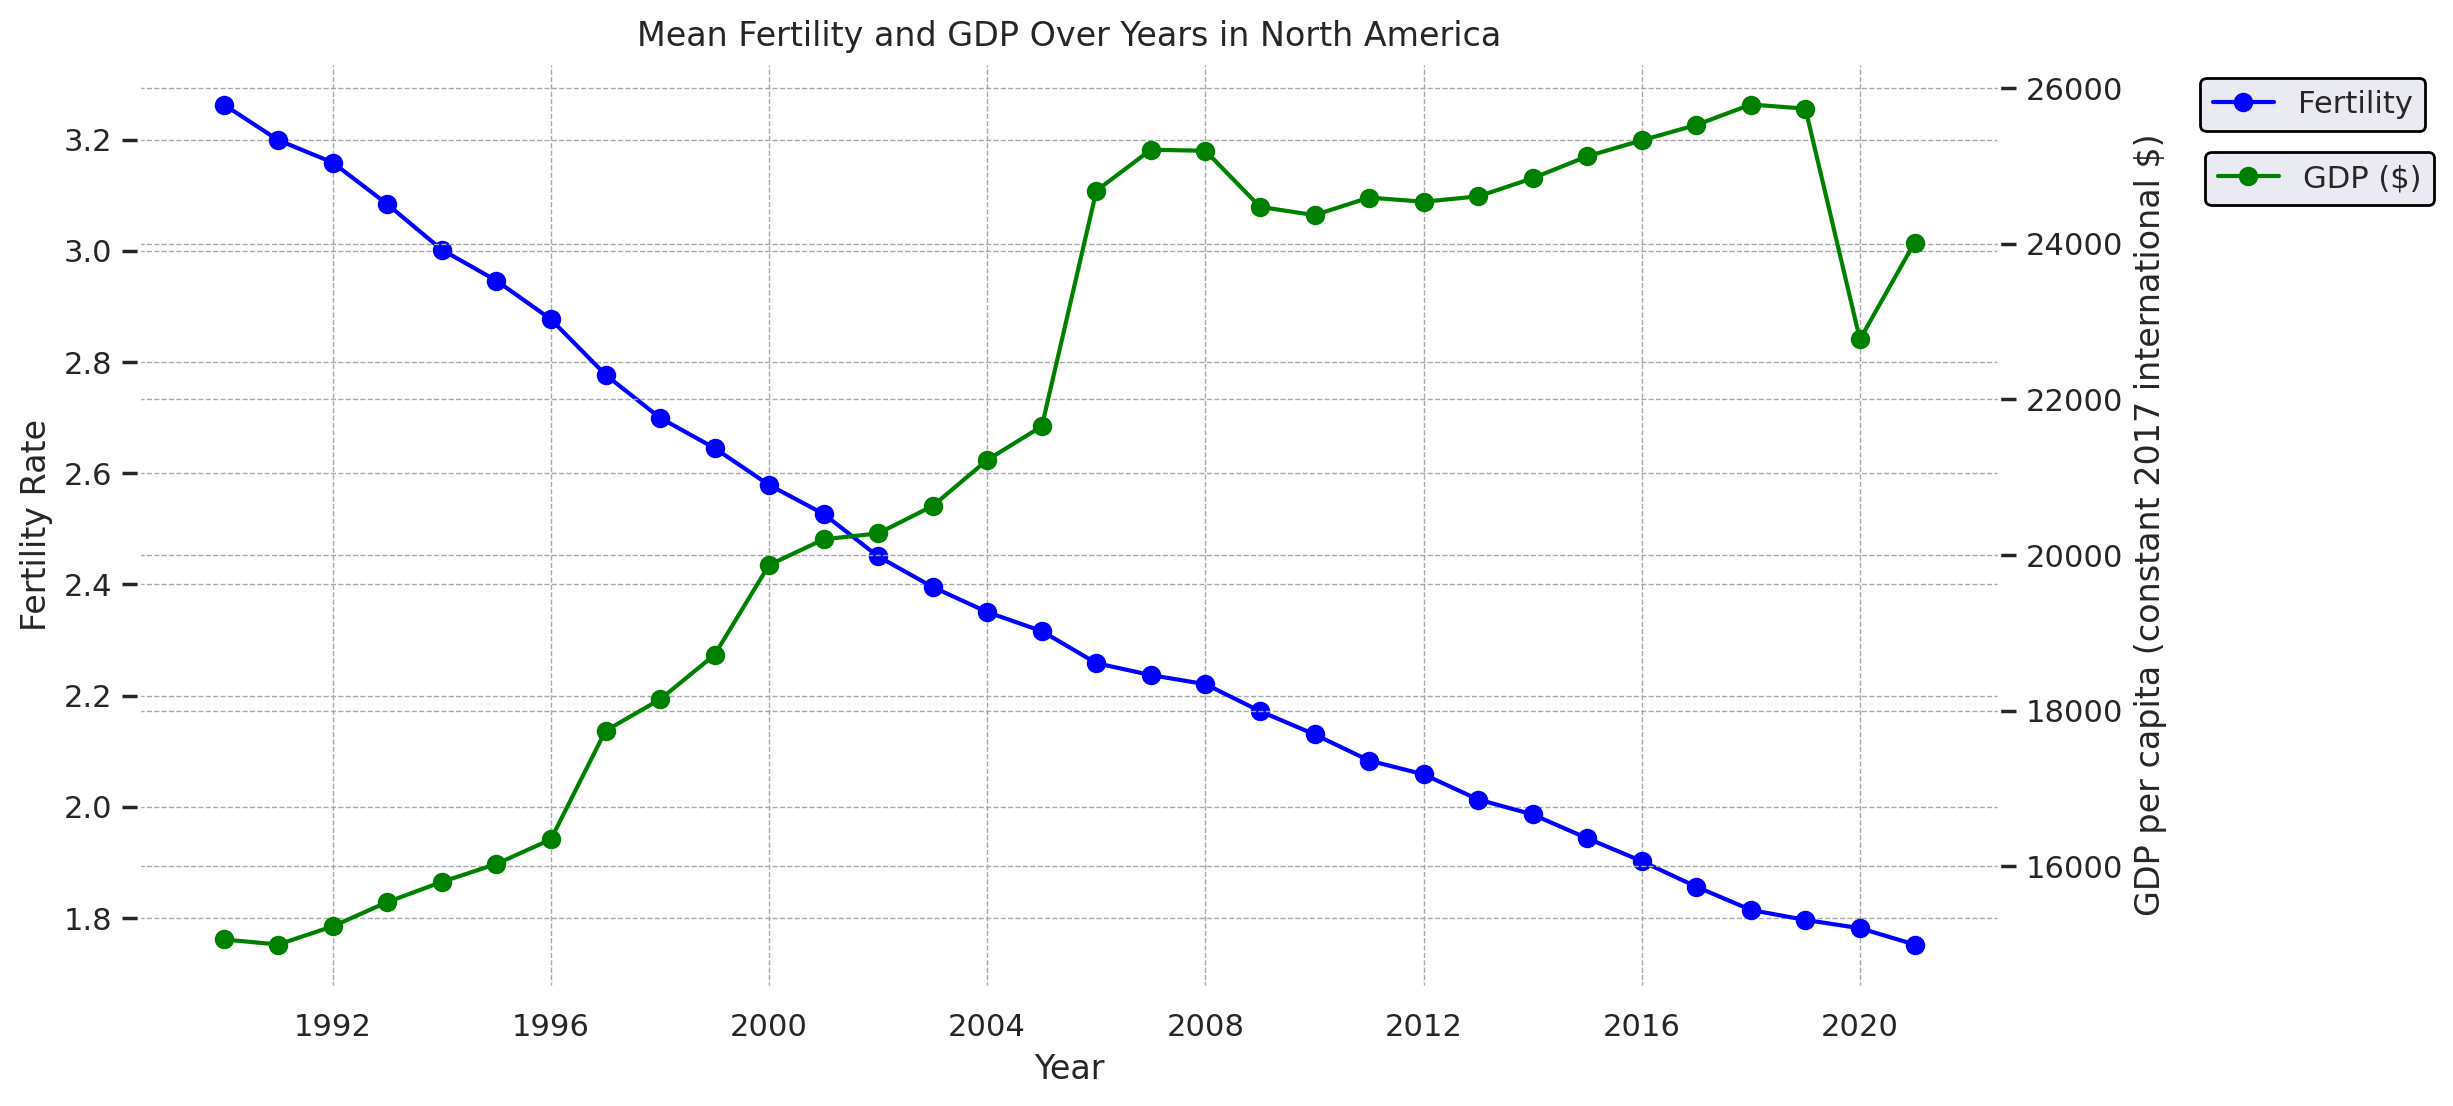

In [17]:
# Filter data for North America
north_america_df = df_women_gdp[df_women_gdp['Continent'] == 'North America']

# Grouping by Year and calculating the mean for each column
numeric_columns = north_america_df.select_dtypes(include='number').columns
mean_by_year_north_america = north_america_df.groupby('Year')[numeric_columns].mean().reset_index()

# Create a figure with a secondary y-axis
fig, ax1 = plt.subplots(figsize=(12, 6))

# Plotting Fertility against Year on the primary y-axis
ax1.plot(mean_by_year_north_america['Year'],
         mean_by_year_north_america['Fertility_rate'],
         color='blue',
         marker='o',
         label='Fertility')

ax1.set_xlabel('Year')
ax1.set_ylabel('Fertility Rate')

# Create a secondary y-axis for GDP
ax2 = ax1.twinx()
ax2.plot(mean_by_year_north_america['Year'],
         mean_by_year_north_america['GDP_Per_Capita'],
         color='green',
         marker='o',
         label='GDP ($)')

ax2.set_ylabel('GDP per capita (constant 2017 international $)')

# Set background color to white
ax1.set_facecolor('white')
ax2.set_facecolor('white')

# Set grid color to dark grey and grid style to dashed
ax1.grid(color='darkgrey', linestyle='dashed', linewidth=0.5)
ax2.grid(color='darkgrey', linestyle='dashed', linewidth=0.5)

# Move the legends to the top right with a black box around them
ax1.legend(bbox_to_anchor=(1.1, 1), loc='upper left', frameon=True, framealpha=1, edgecolor='black')
ax2.legend(bbox_to_anchor=(1.242, 0.92), loc='upper right', frameon=True, framealpha=1, edgecolor='black')

plt.title('Mean Fertility and GDP Over Years in North America')
plt.show()


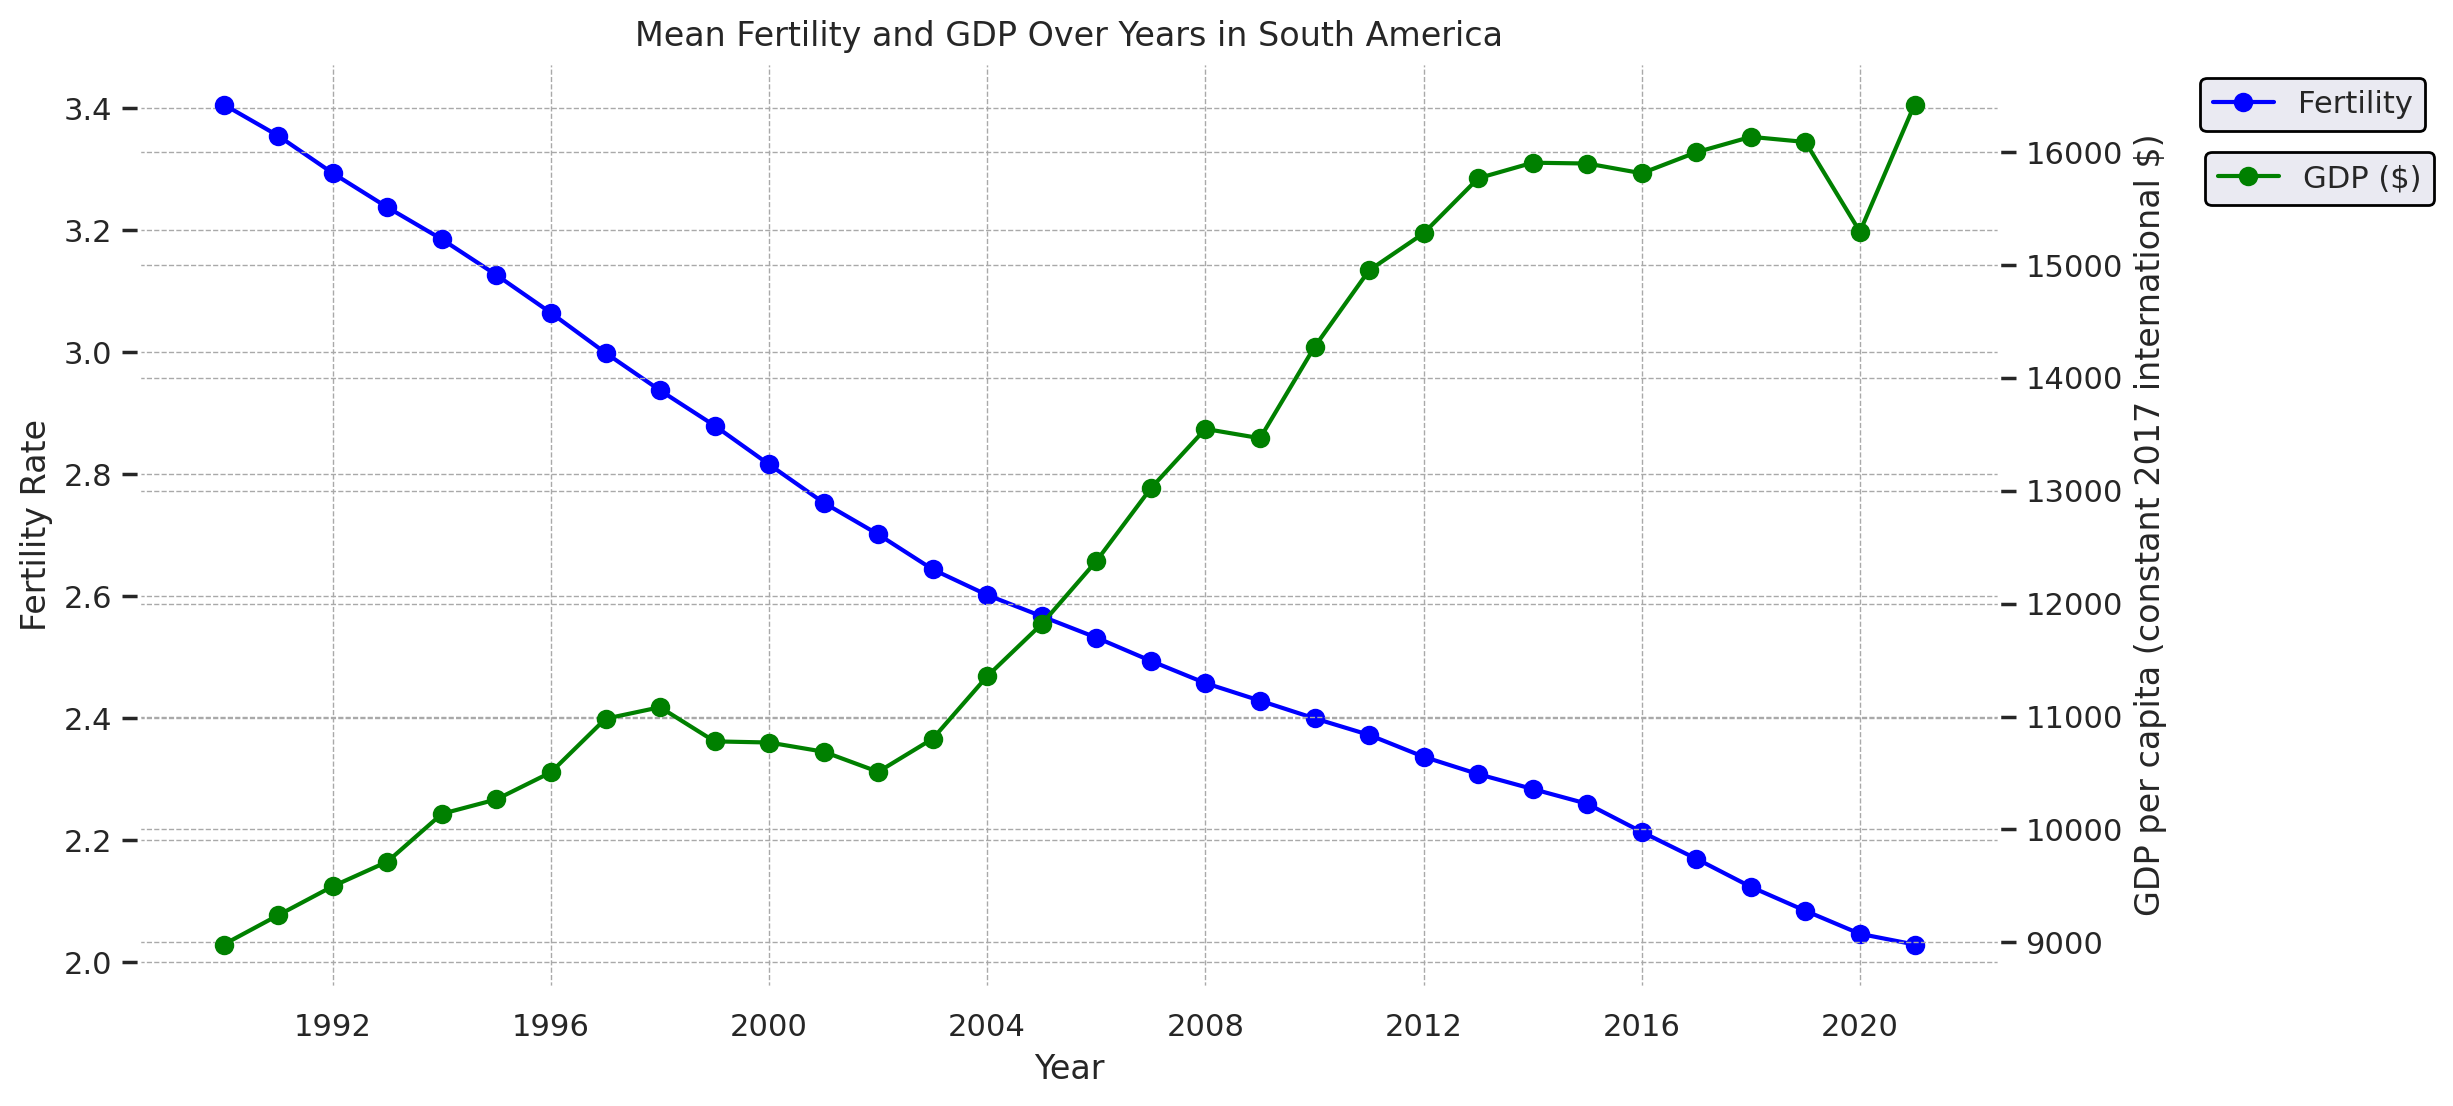

In [18]:
# Filter data for South America
south_america_df = df_women_gdp[df_women_gdp['Continent'] == 'South America']

# Grouping by Year and calculating the mean for each column
numeric_columns = south_america_df.select_dtypes(include='number').columns
mean_by_year_south_america = south_america_df.groupby('Year')[numeric_columns].mean().reset_index()

# Create a figure with a secondary y-axis
fig, ax1 = plt.subplots(figsize=(12, 6))

# Plotting Fertility against Year on the primary y-axis
ax1.plot(mean_by_year_south_america['Year'],
         mean_by_year_south_america['Fertility_rate'],
         color='blue',
         marker='o',
         label='Fertility')

ax1.set_xlabel('Year')
ax1.set_ylabel('Fertility Rate')

# Create a secondary y-axis for GDP
ax2 = ax1.twinx()
ax2.plot(mean_by_year_south_america['Year'],
         mean_by_year_south_america['GDP_Per_Capita'],
         color='green',
         marker='o',
         label='GDP ($)')

ax2.set_ylabel('GDP per capita (constant 2017 international $)')

# Set background color to white
ax1.set_facecolor('white')
ax2.set_facecolor('white')

# Set grid color to dark grey and grid style to dashed
ax1.grid(color='darkgrey', linestyle='dashed', linewidth=0.5)
ax2.grid(color='darkgrey', linestyle='dashed', linewidth=0.5)

# Move the legends to the top right with a black box around them
ax1.legend(bbox_to_anchor=(1.1, 1), loc='upper left', frameon=True, framealpha=1, edgecolor='black')
ax2.legend(bbox_to_anchor=(1.242, 0.92), loc='upper right', frameon=True, framealpha=1, edgecolor='black')

plt.title('Mean Fertility and GDP Over Years in South America')
plt.show()


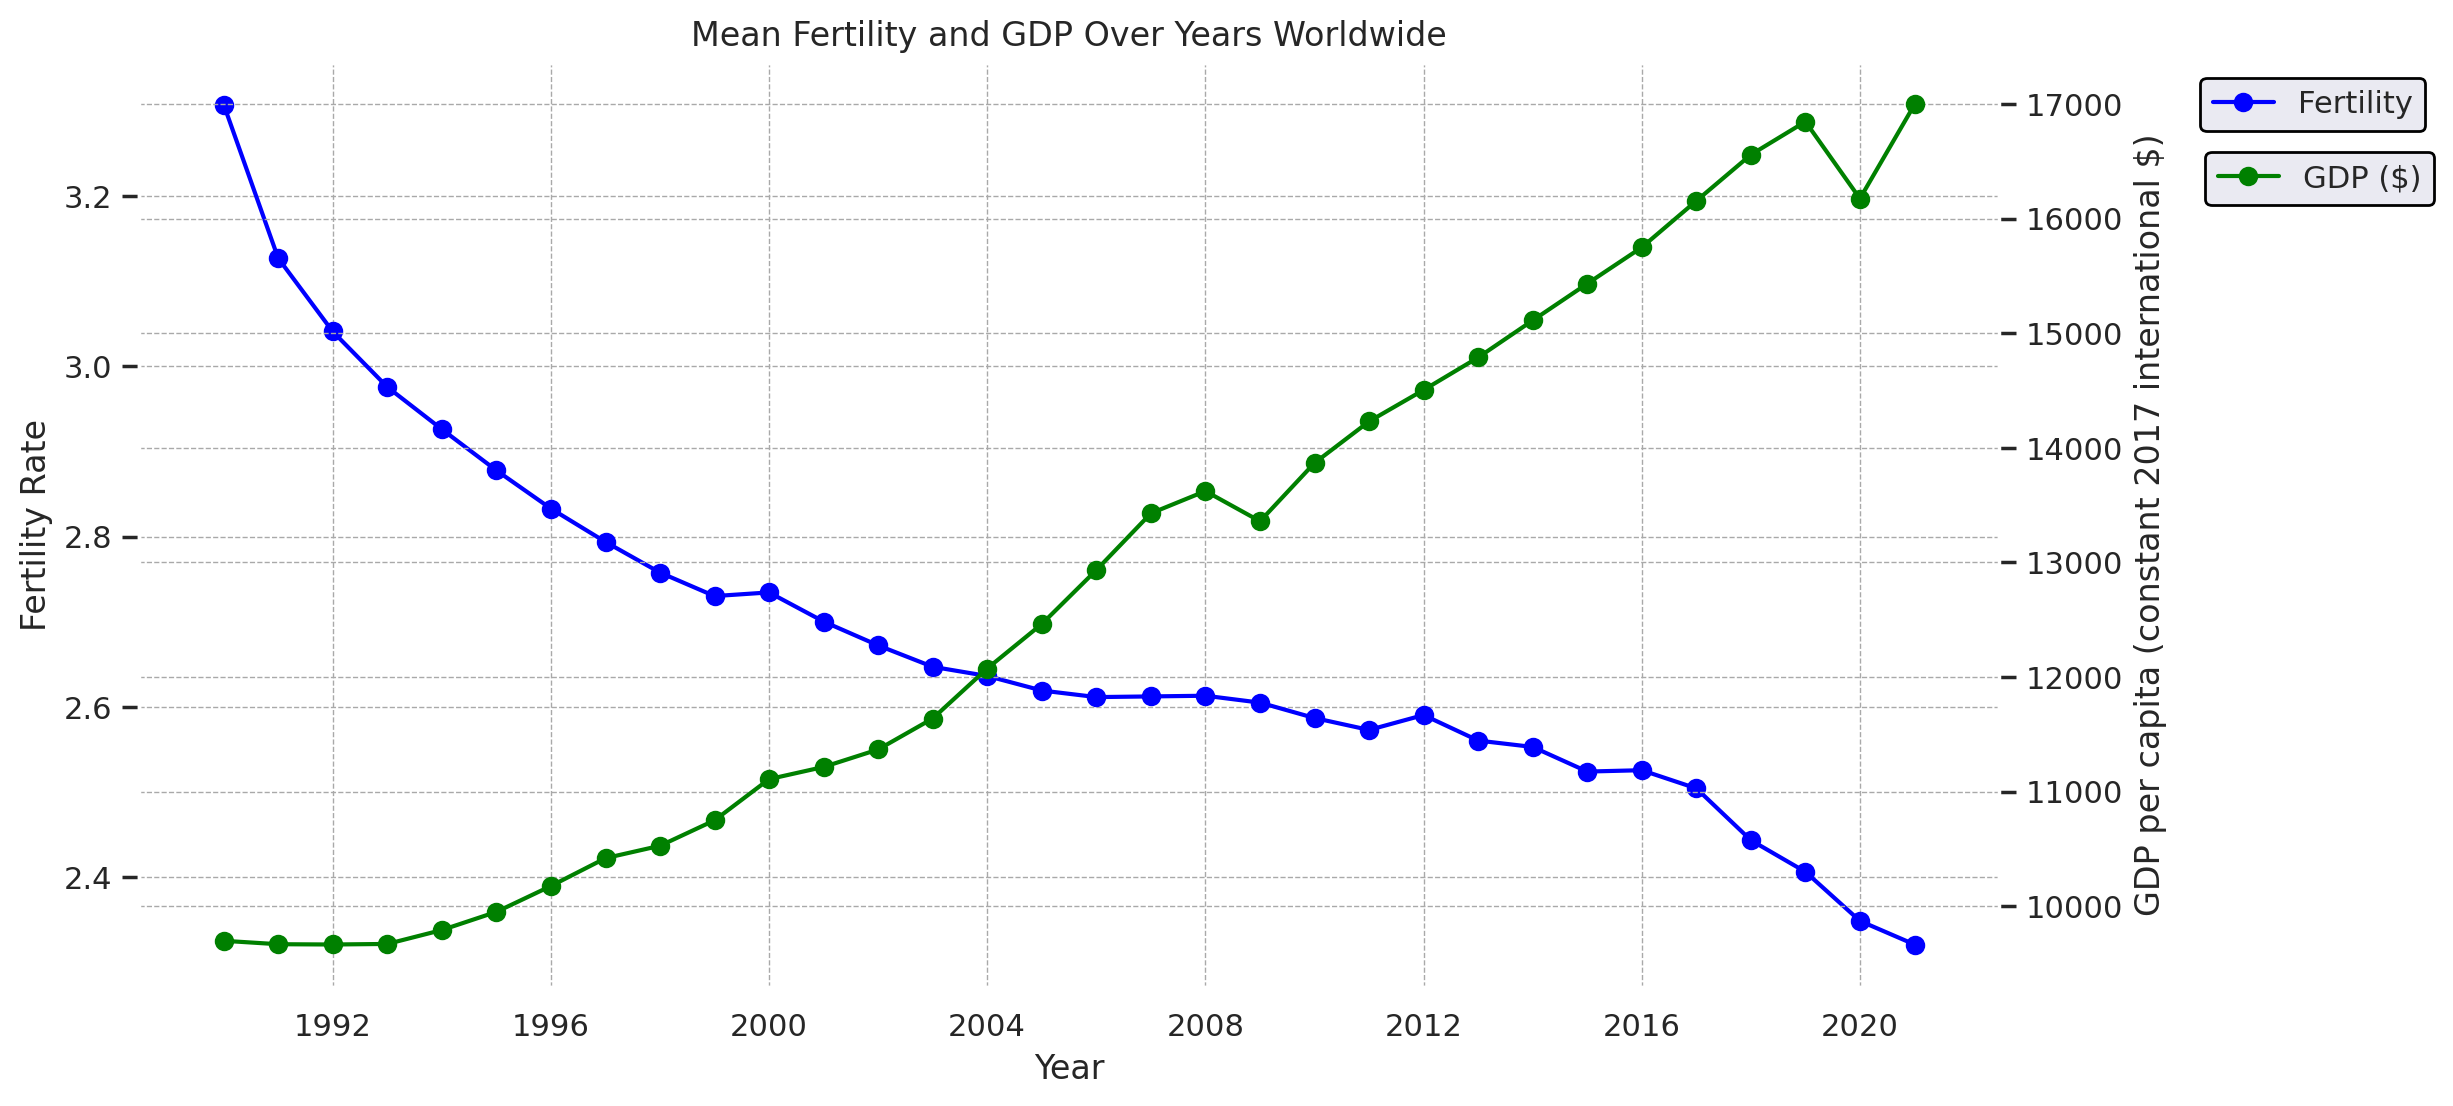

In [19]:
# Filter data for the World
world_df = df_women_gdp[df_women_gdp['Continent'] == 'World']

# Grouping by Year and calculating the mean for each column
numeric_columns = world_df.select_dtypes(include='number').columns
mean_by_year_world = world_df.groupby('Year')[numeric_columns].mean().reset_index()

# Create a figure with a secondary y-axis
fig, ax1 = plt.subplots(figsize=(12, 6))

# Plotting Fertility against Year on the primary y-axis
ax1.plot(mean_by_year_world['Year'],
         mean_by_year_world['Fertility_rate'],
         color='blue',
         marker='o',
         label='Fertility')

ax1.set_xlabel('Year')
ax1.set_ylabel('Fertility Rate')

# Create a secondary y-axis for GDP
ax2 = ax1.twinx()
ax2.plot(mean_by_year_world['Year'],
         mean_by_year_world['GDP_Per_Capita'],
         color='green',
         marker='o',
         label='GDP ($)')

ax2.set_ylabel('GDP per capita (constant 2017 international $)')

# Set background color to white
ax1.set_facecolor('white')
ax2.set_facecolor('white')

# Set grid color to dark grey and grid style to dashed
ax1.grid(color='darkgrey', linestyle='dashed', linewidth=0.5)
ax2.grid(color='darkgrey', linestyle='dashed', linewidth=0.5)

# Move the legends to the top right with a black box around them
ax1.legend(bbox_to_anchor=(1.1, 1), loc='upper left', frameon=True, framealpha=1, edgecolor='black')
ax2.legend(bbox_to_anchor=(1.242, 0.92), loc='upper right', frameon=True, framealpha=1, edgecolor='black')

plt.title('Mean Fertility and GDP Over Years Worldwide')
plt.show()


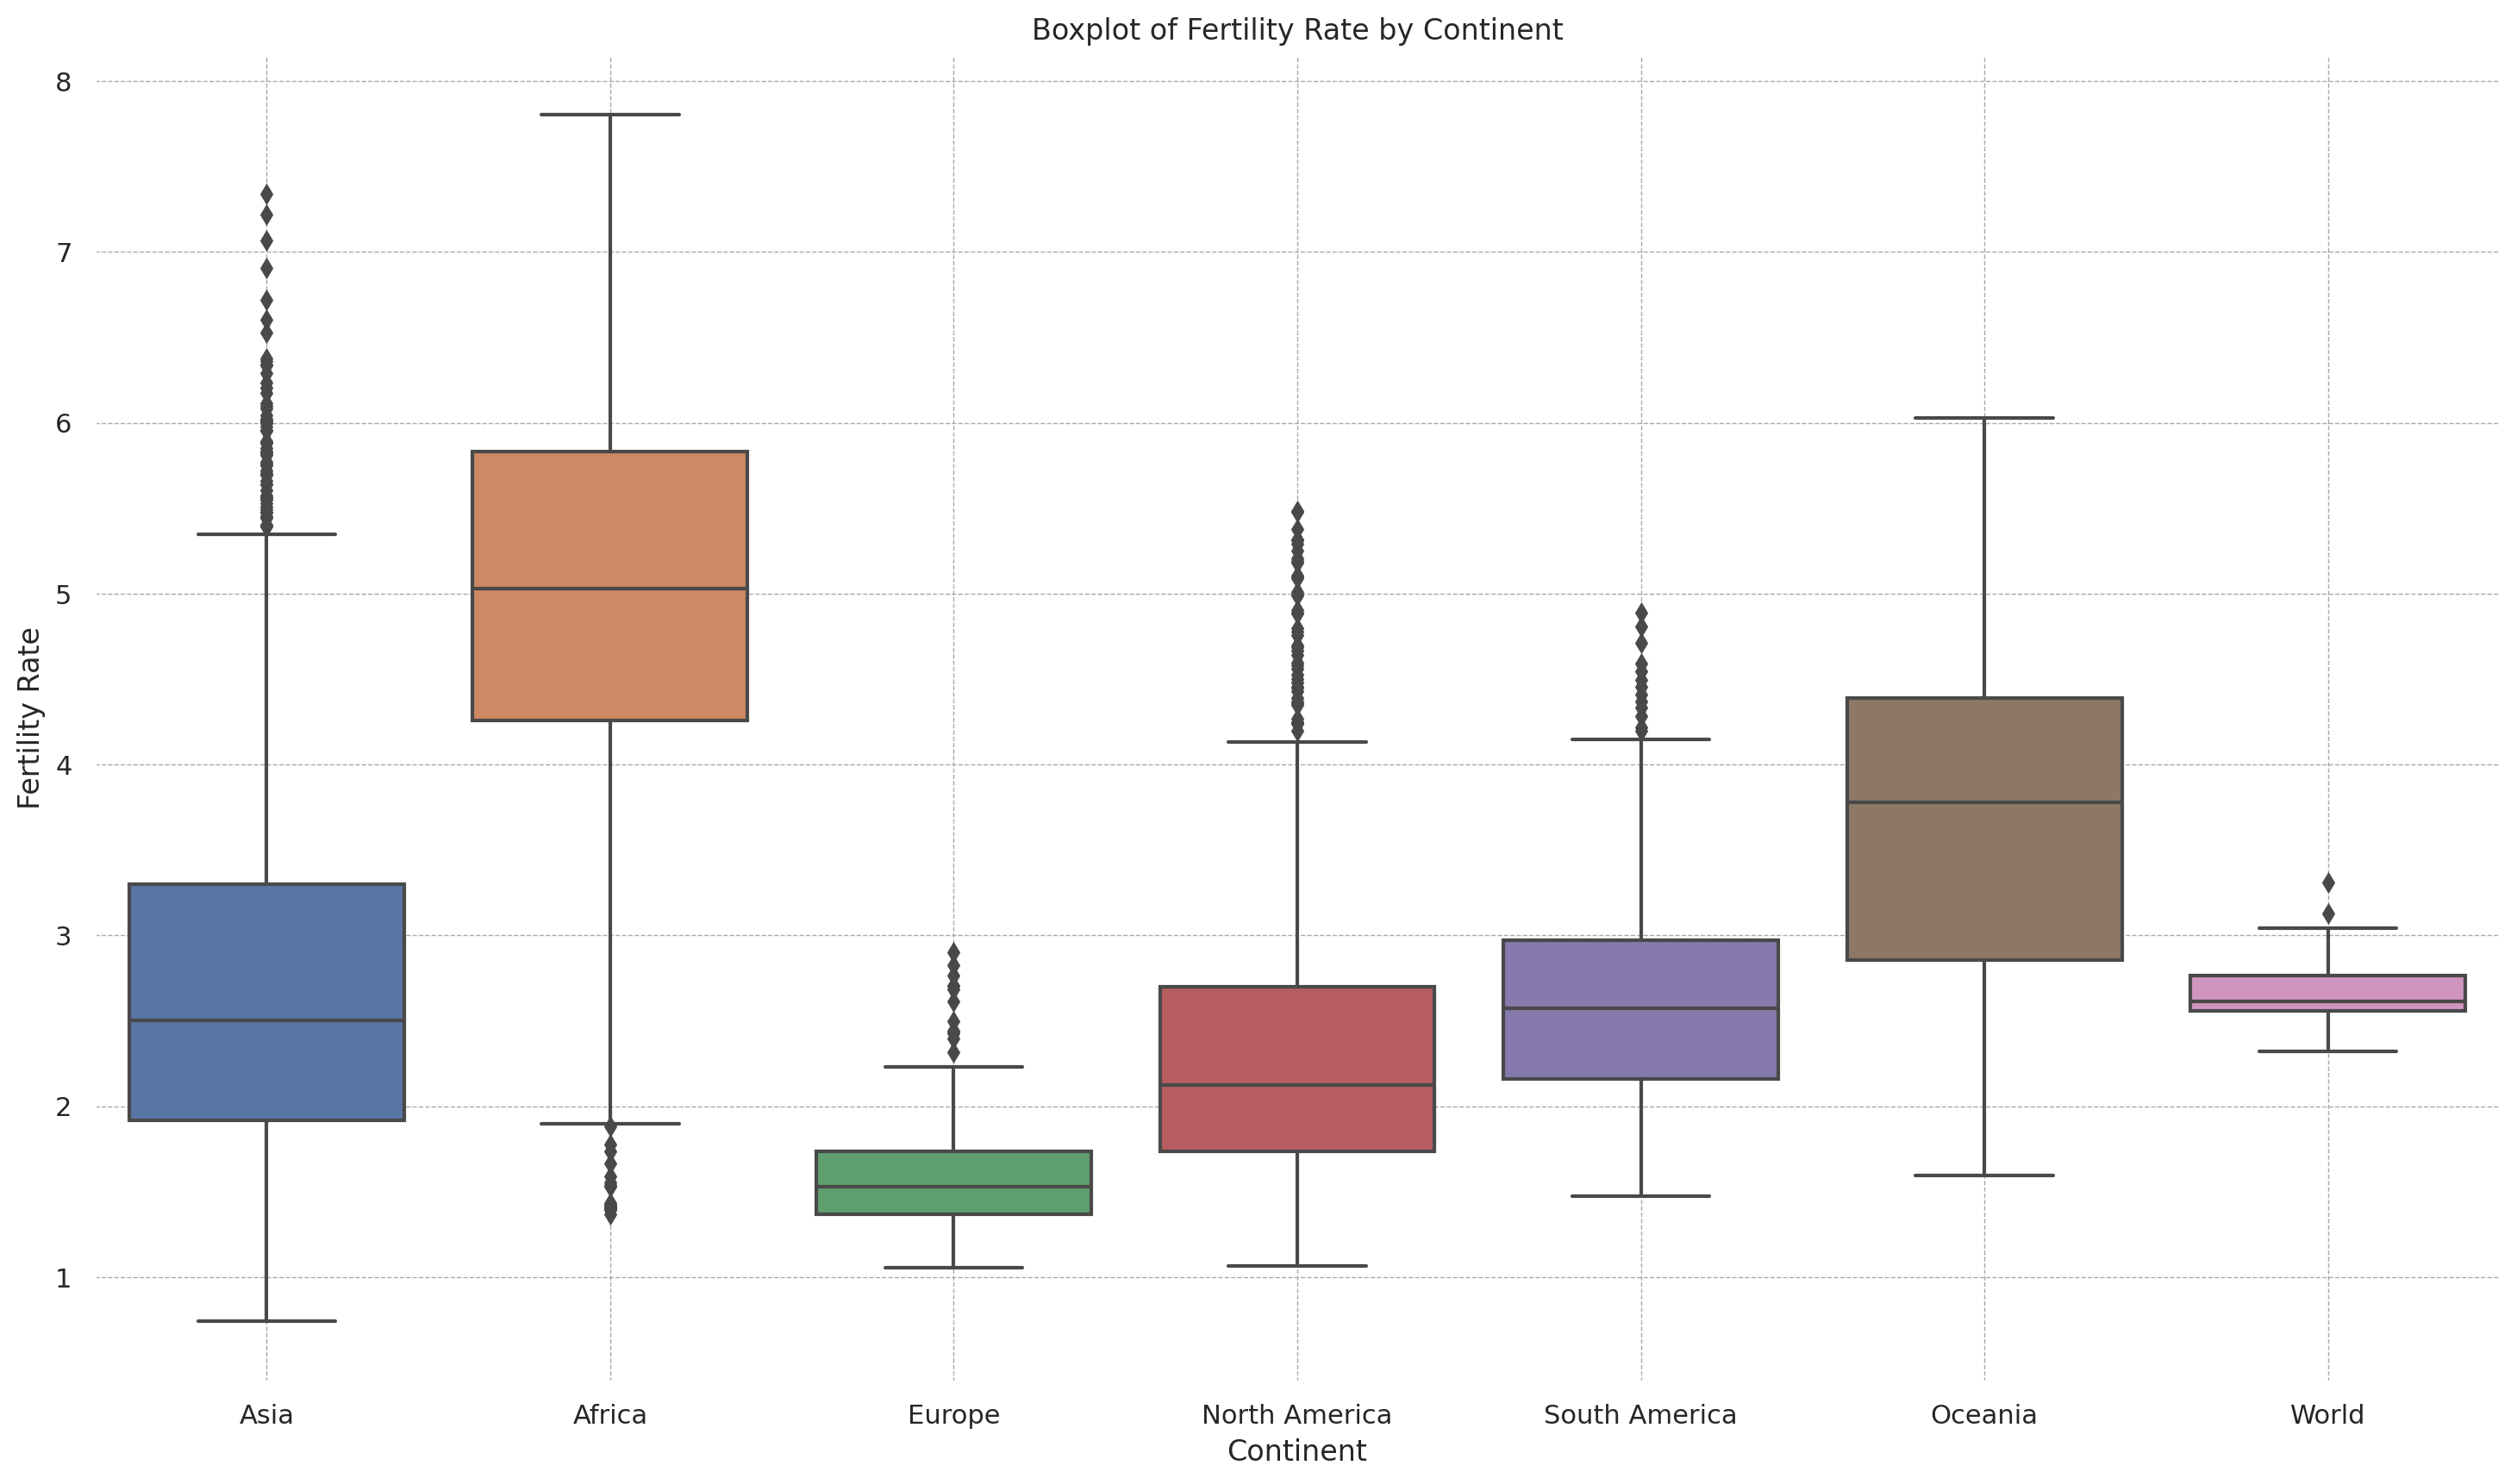

In [20]:
plt.figure(figsize=(18, 10))
sns.boxplot(x='Continent', y='Fertility_rate', data=df_women_gdp)
plt.title('Boxplot of Fertility Rate by Continent')
plt.xlabel('Continent')
plt.ylabel('Fertility Rate')

plt.gca().set_facecolor('white')

plt.grid(color='darkgrey', linestyle='dashed', linewidth=0.5)

plt.show()

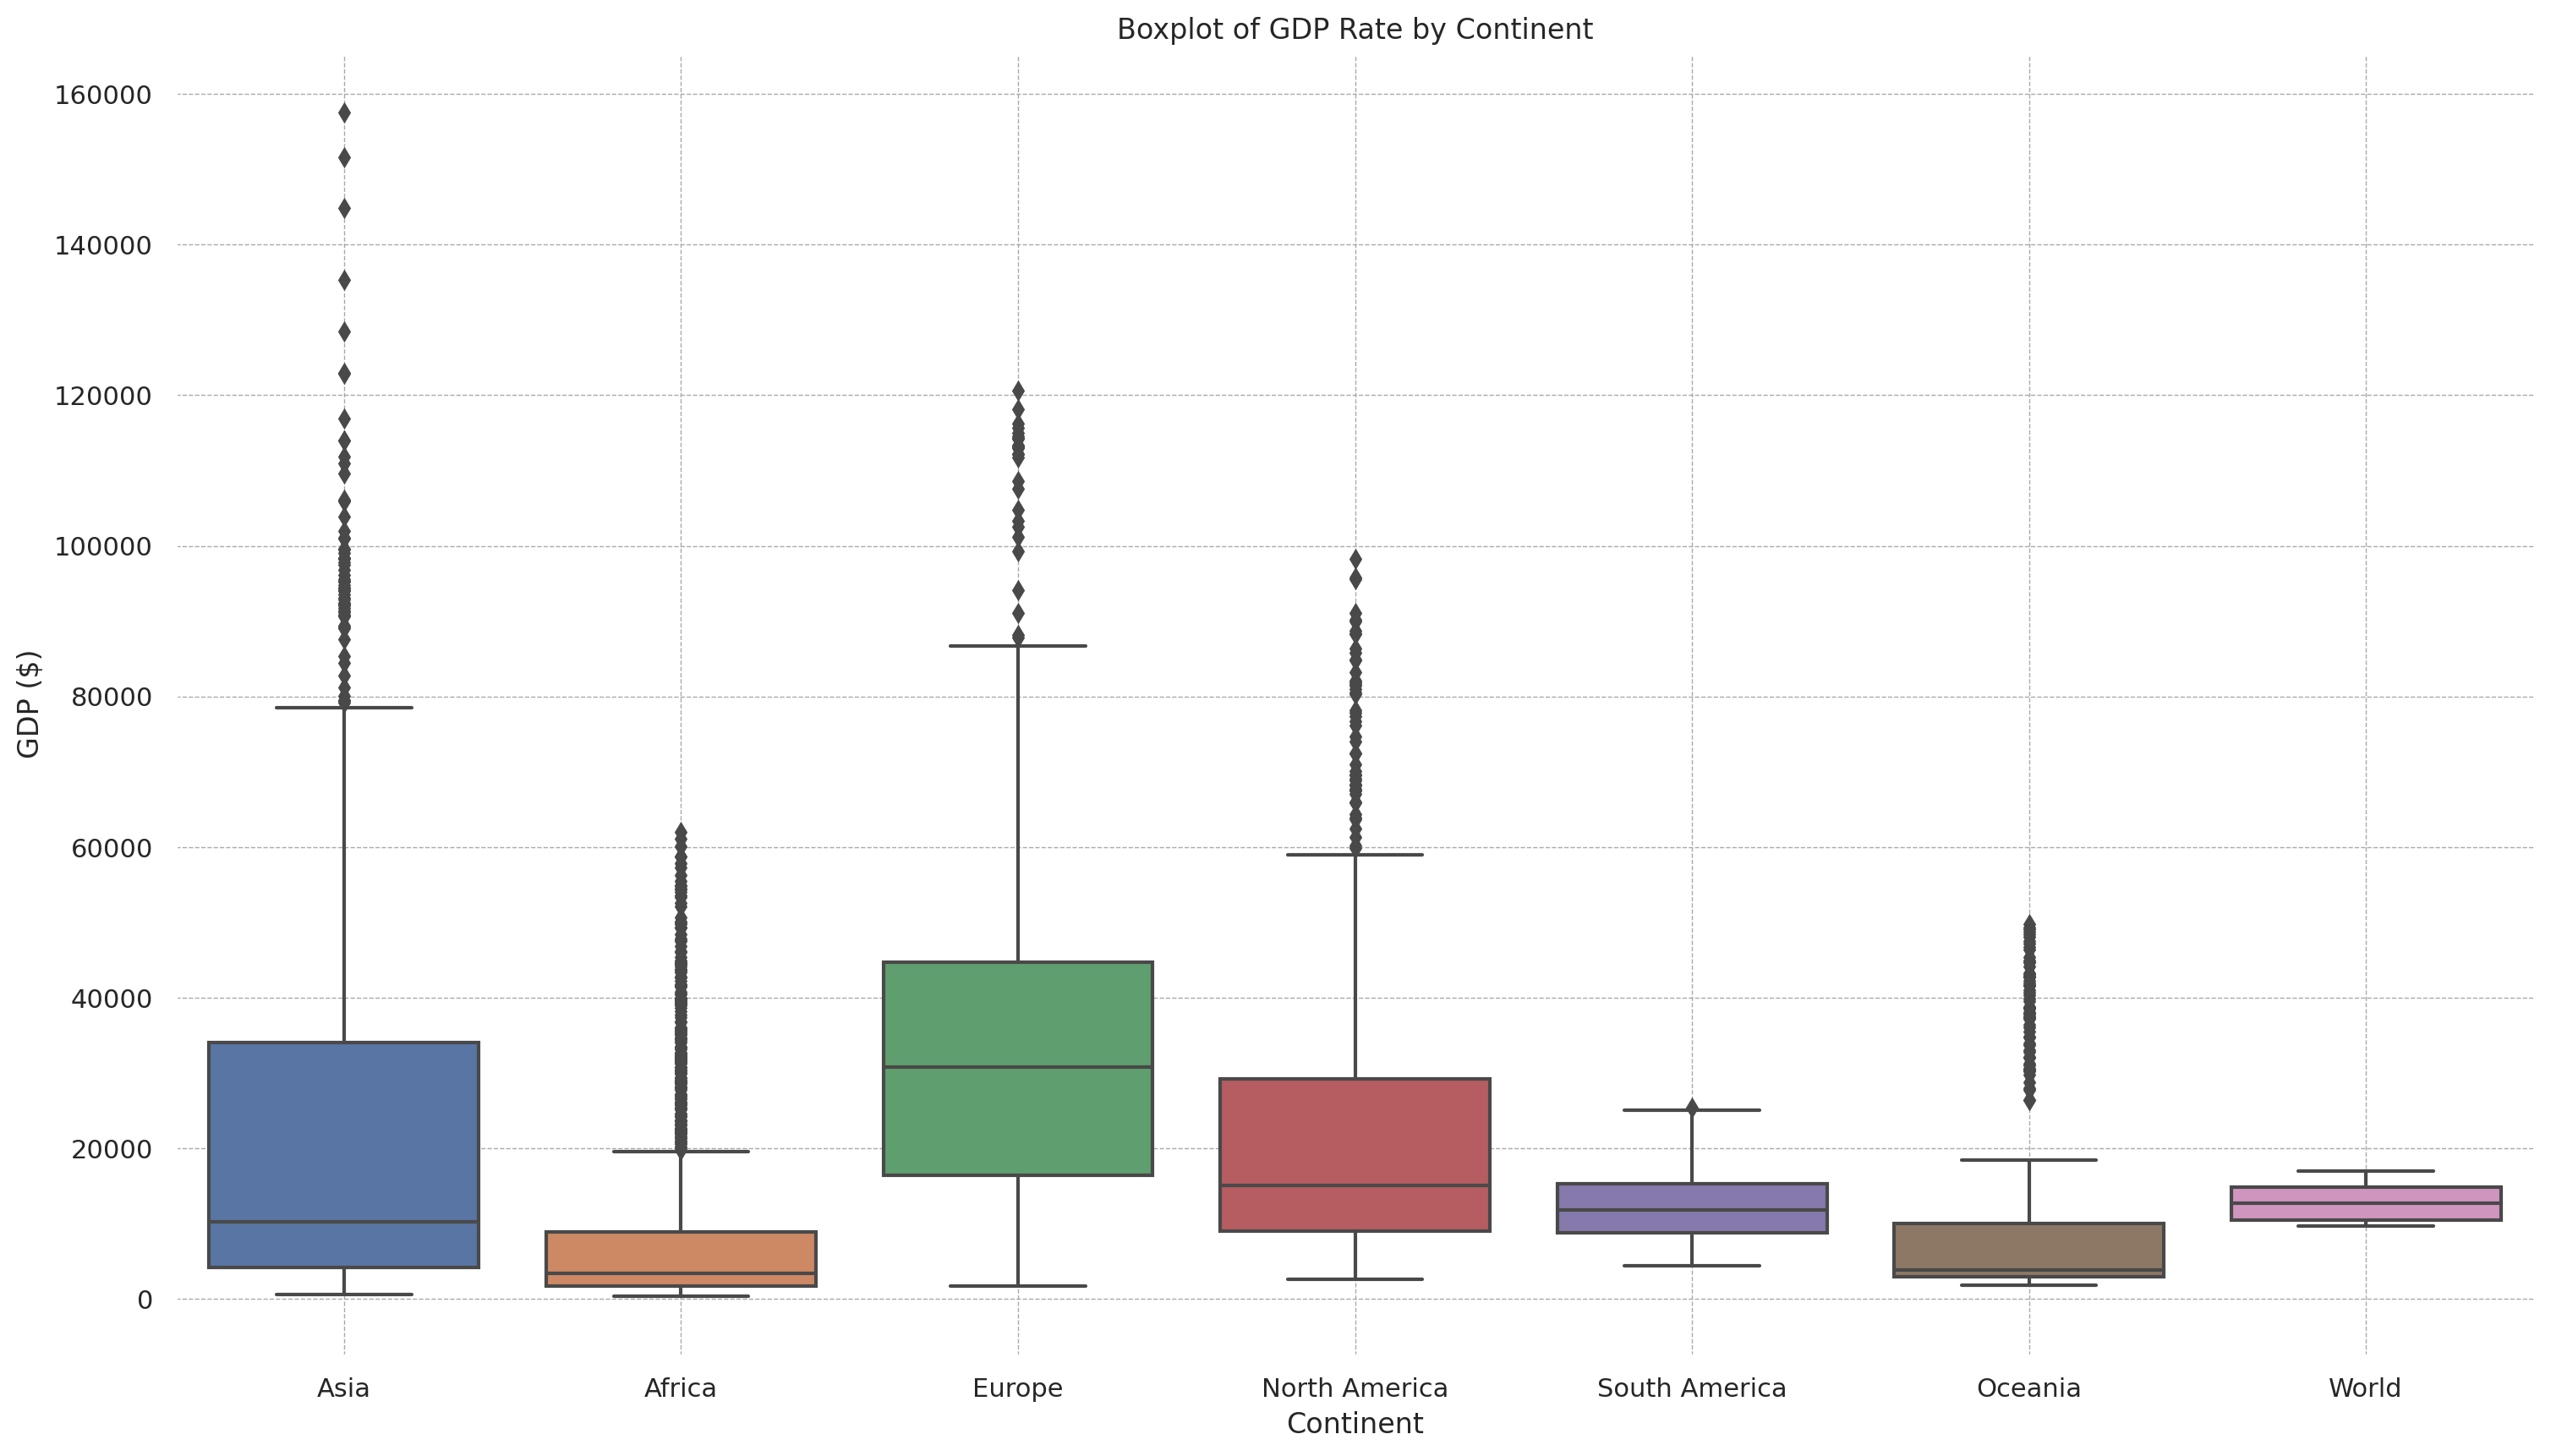

In [21]:
plt.figure(figsize=(18, 10))
sns.boxplot(x='Continent', y='GDP_Per_Capita', data=df_women_gdp)
plt.title('Boxplot of GDP Rate by Continent')
plt.xlabel('Continent')
plt.ylabel('GDP ($)')

plt.gca().set_facecolor('white')

plt.grid(color='darkgrey', linestyle='dashed', linewidth=0.5)

plt.show()

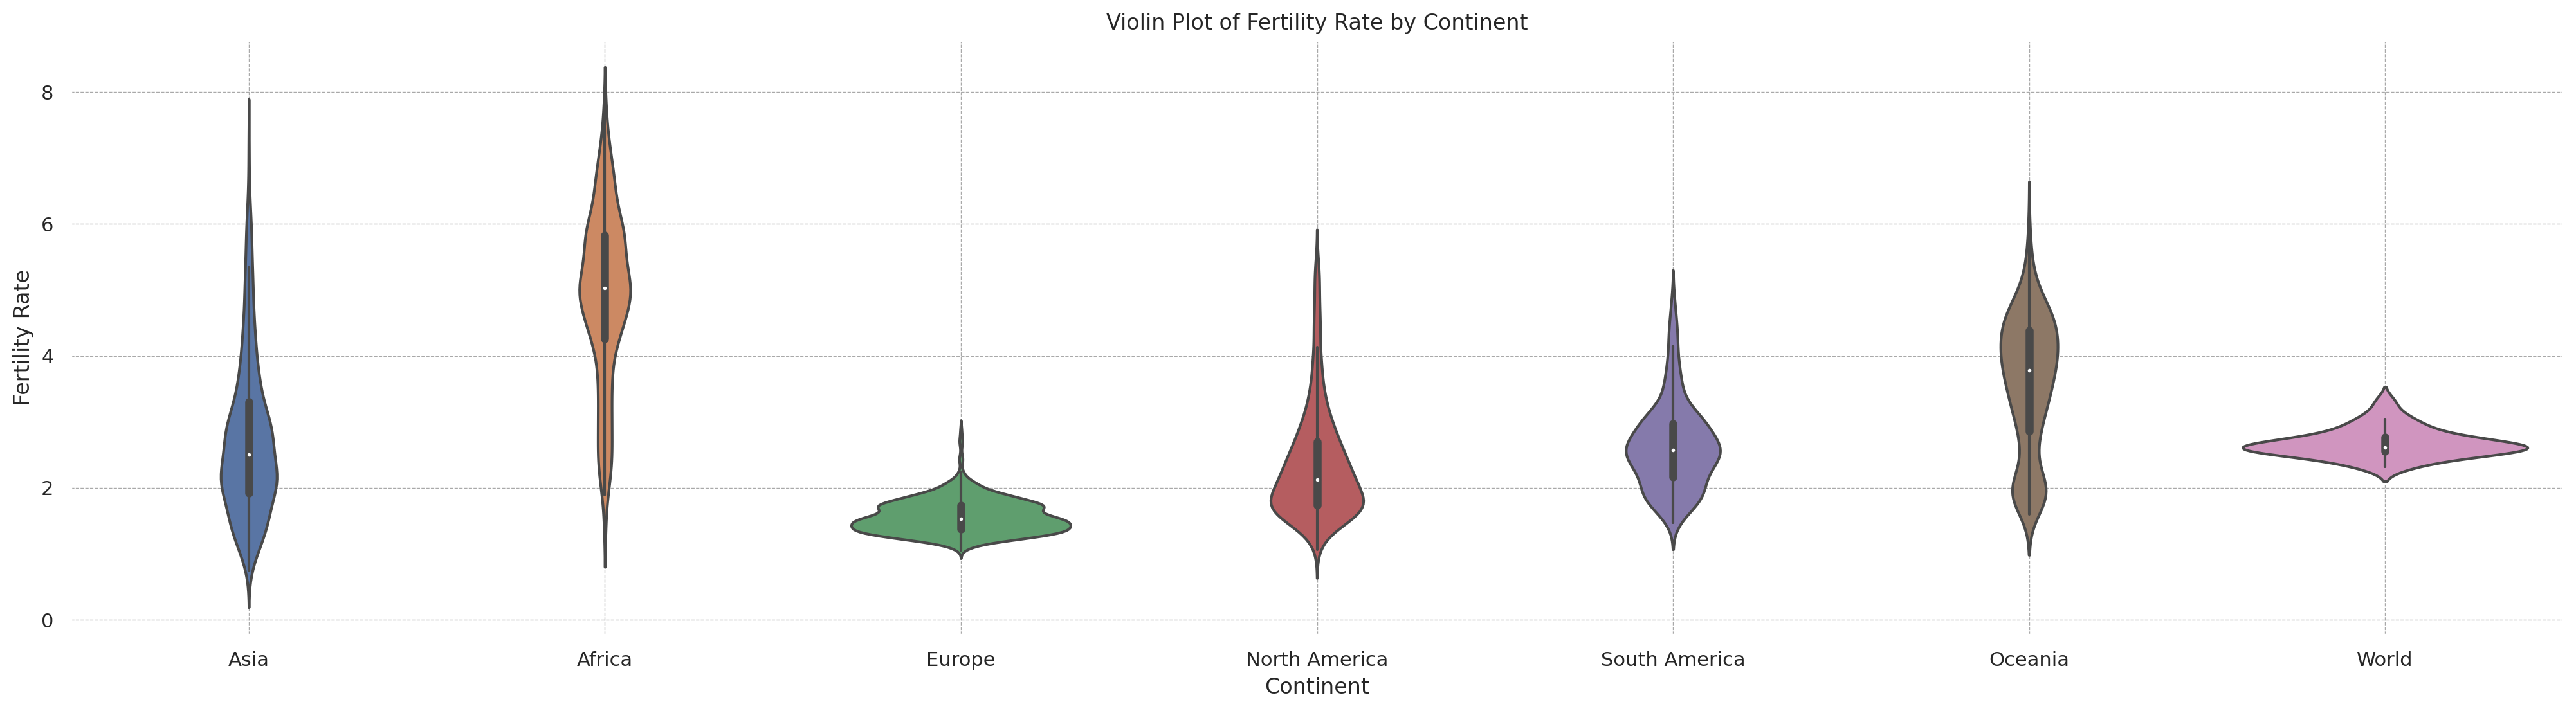

In [22]:
plt.figure(figsize=(25, 6))
sns.violinplot(x='Continent', y='Fertility_rate', data=df_women_gdp)
plt.title('Violin Plot of Fertility Rate by Continent')
plt.xlabel('Continent')
plt.ylabel('Fertility Rate')

plt.gca().set_facecolor('white')

plt.grid(color='darkgrey', linestyle='dashed', linewidth=0.5)

plt.show()

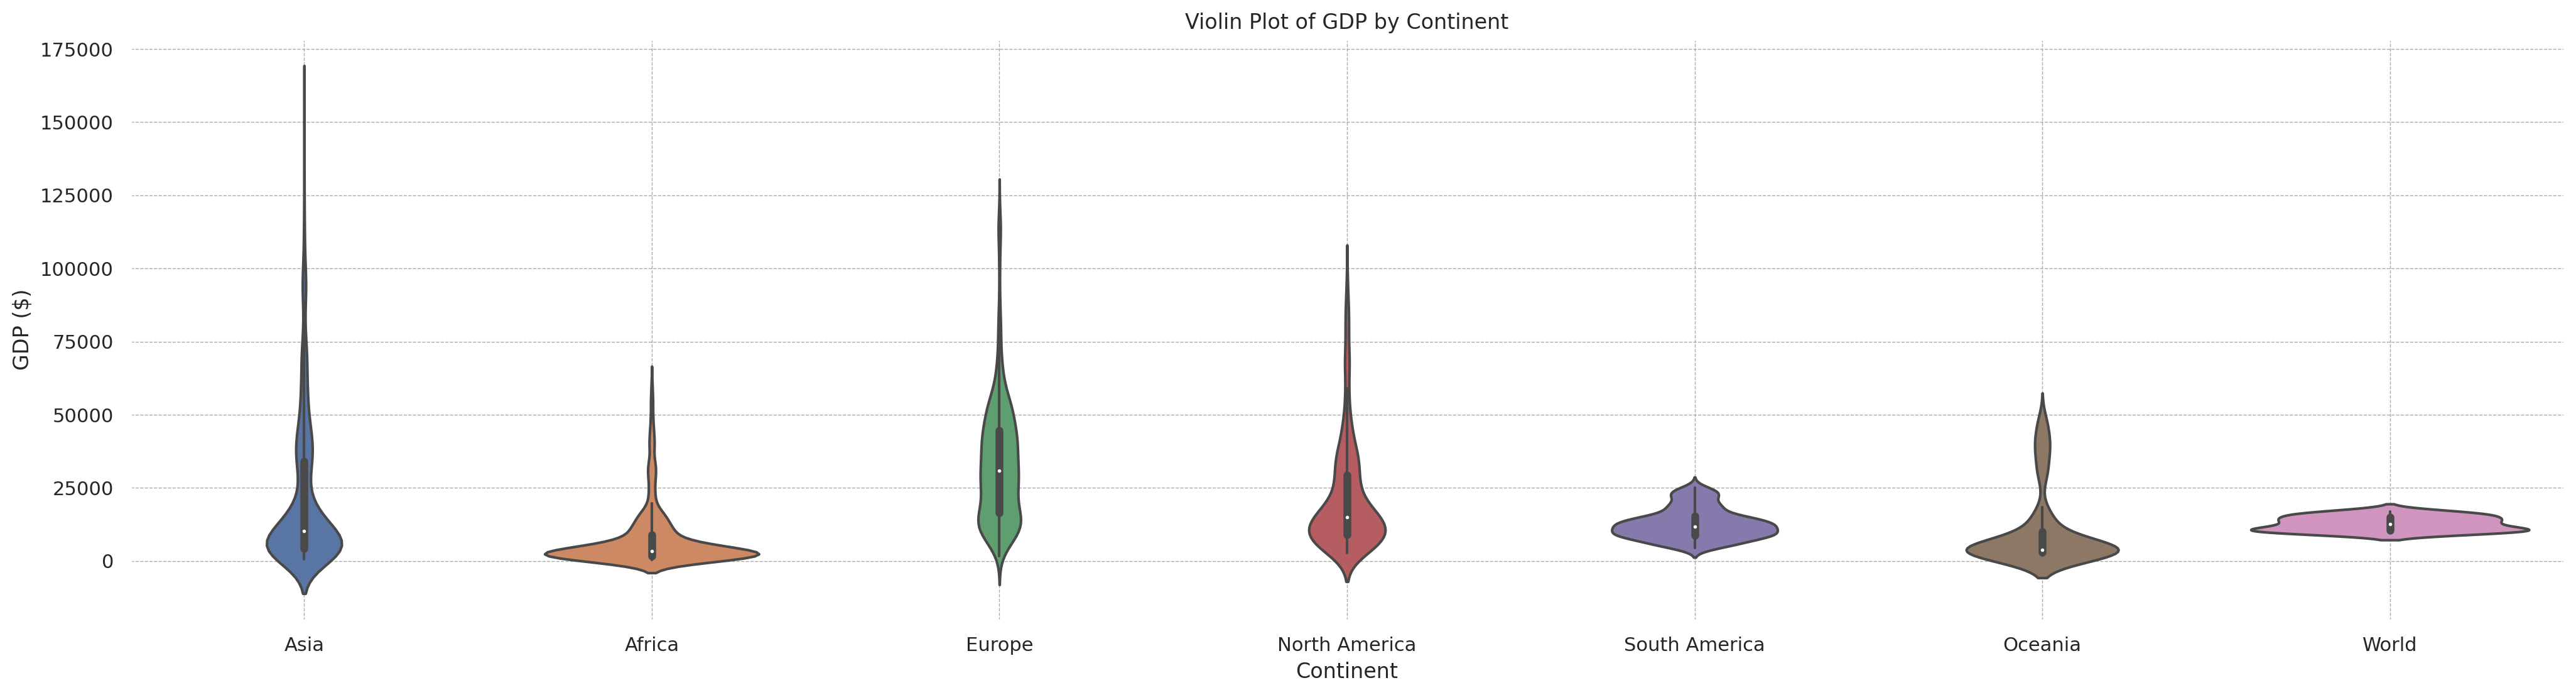

In [23]:
plt.figure(figsize=(25, 6))
sns.violinplot(x='Continent', y='GDP_Per_Capita', data=df_women_gdp)
plt.title('Violin Plot of GDP by Continent')
plt.xlabel('Continent')
plt.ylabel('GDP ($)')

plt.gca().set_facecolor('white')

plt.grid(color='darkgrey', linestyle='dashed', linewidth=0.5)

plt.show()

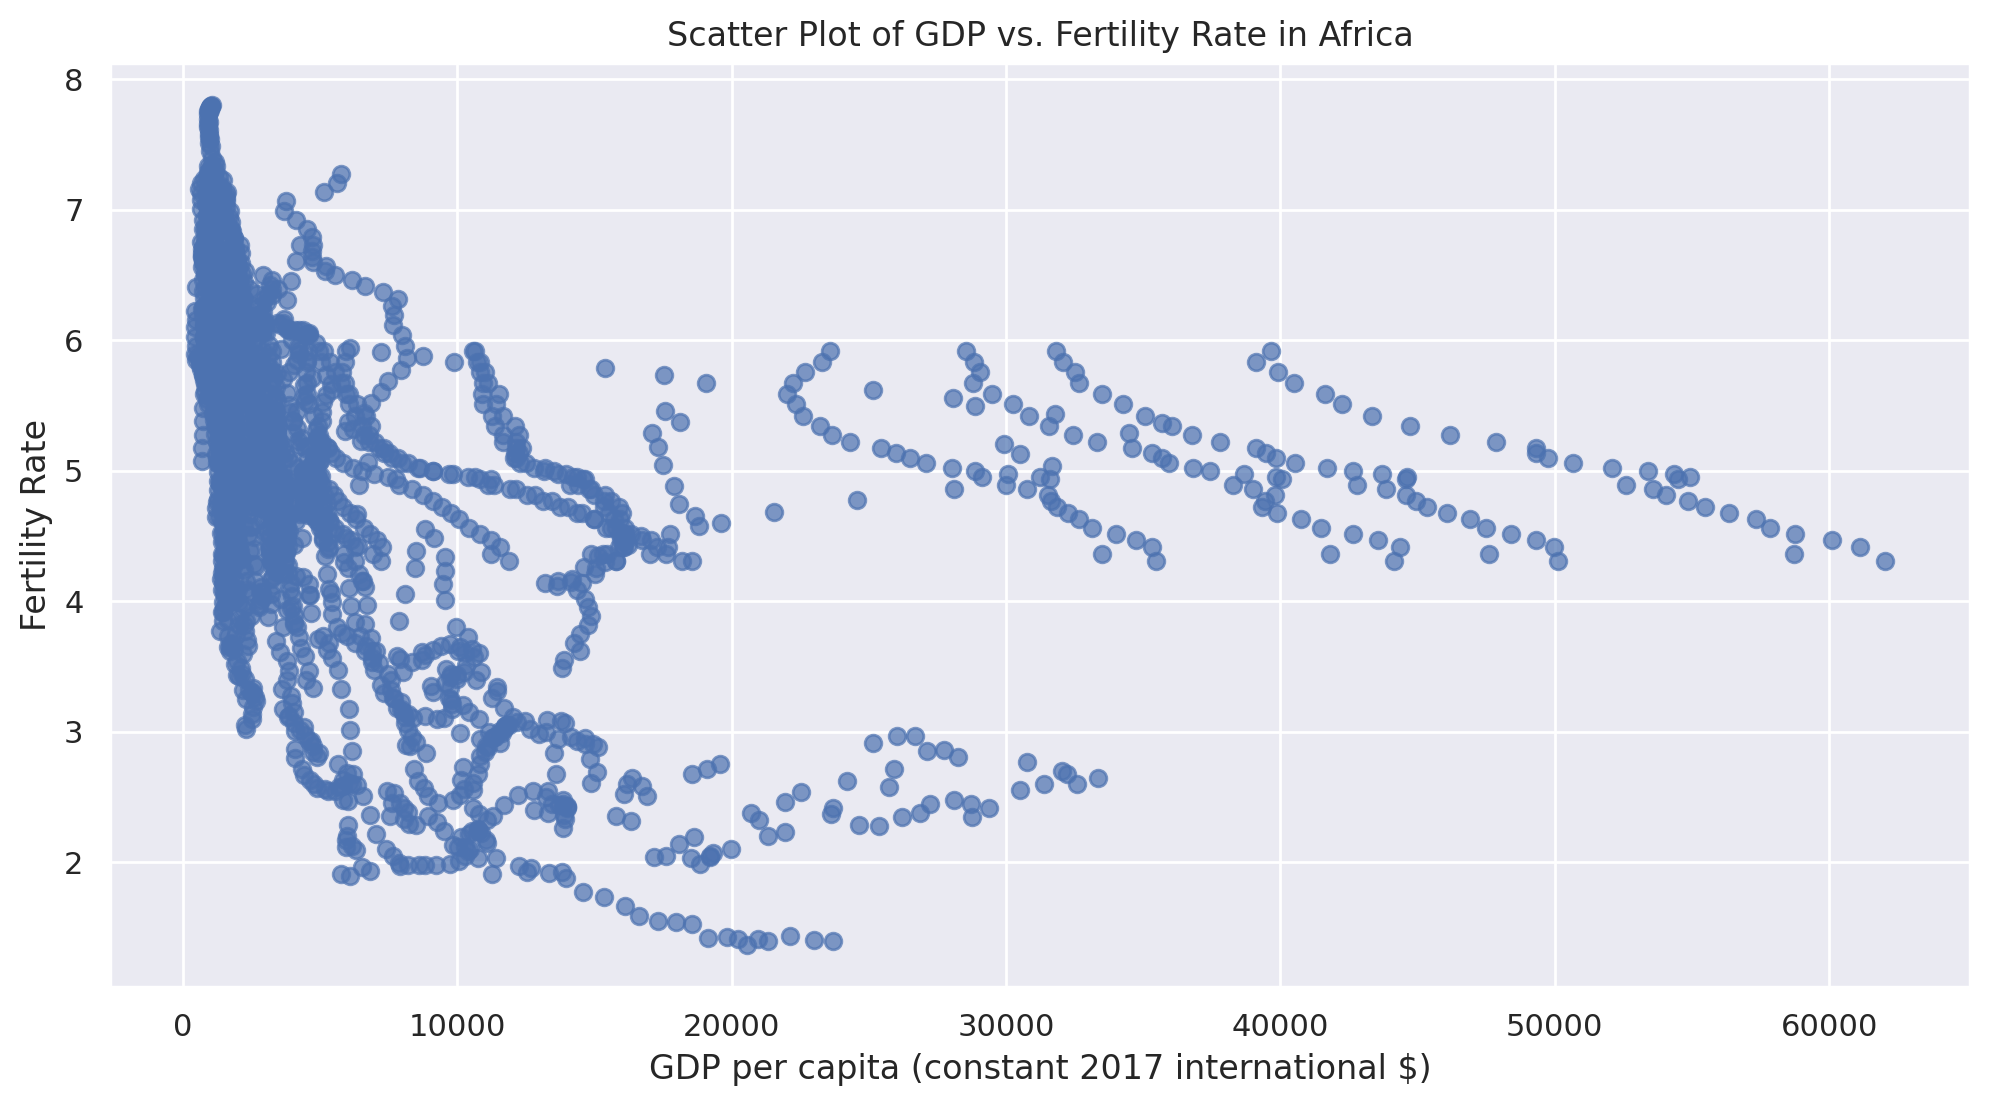

In [24]:

# Filter data for Africa
africa_df = df_women_gdp[df_women_gdp['Continent'] == 'Africa']
# Create a scatter plot
plt.figure(figsize=(12, 6))
plt.scatter(africa_df['GDP_Per_Capita'], africa_df['Fertility_rate'], alpha=0.7)
plt.title('Scatter Plot of GDP vs. Fertility Rate in Africa')
plt.xlabel('GDP per capita (constant 2017 international $)')
plt.ylabel('Fertility Rate')
plt.grid(True)
plt.show()


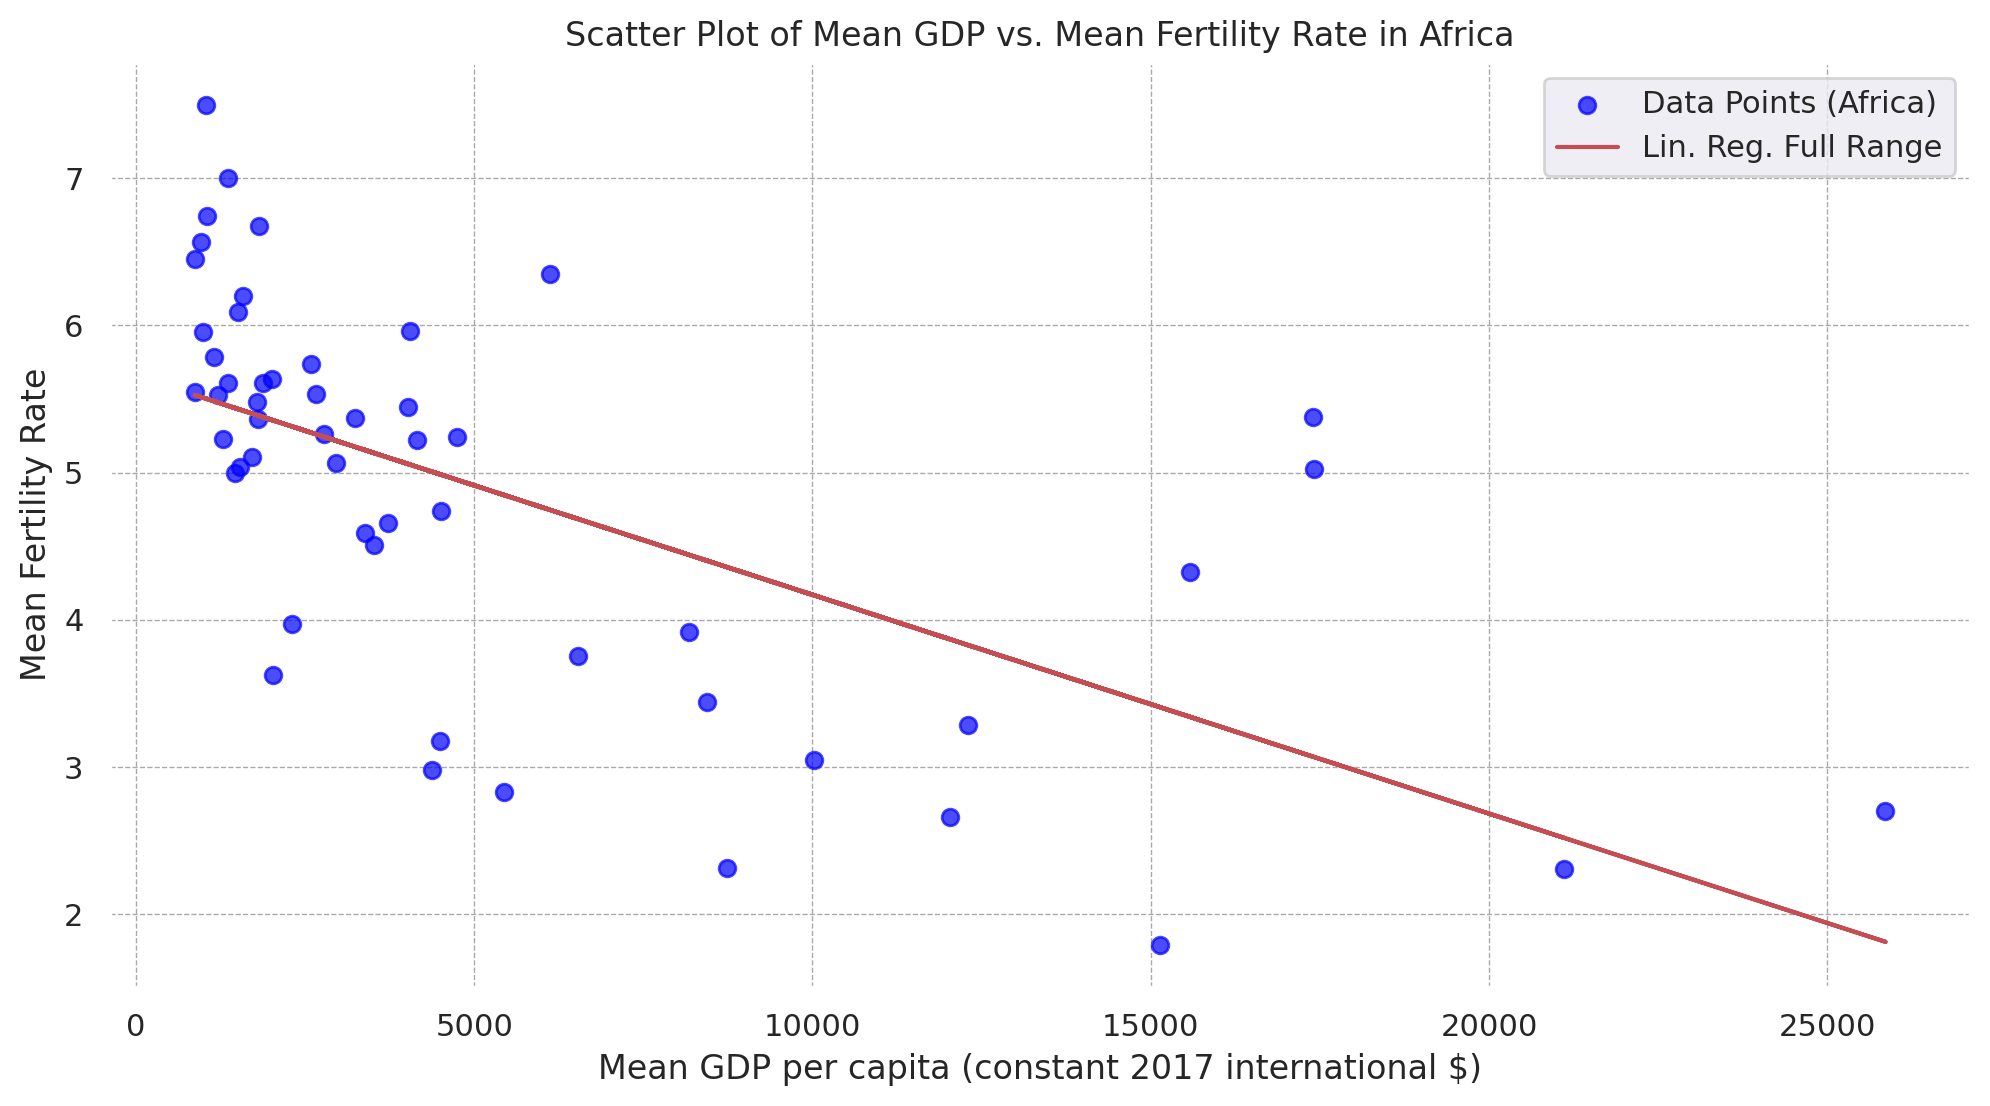

Correlation coefficient: -0.2950650551626432


In [49]:
# Filter data for Africa
africa_df = df_women_gdp[df_women_gdp['Continent'] == 'Africa']

# Calculate the mean of GDP and fertility for each country in Africa
mean_gdp = africa_df.groupby('Entity_x')['GDP_Per_Capita'].mean()
mean_fertility = africa_df.groupby('Entity_x')['Fertility_rate'].mean()

# Create a scatter plot
plt.figure(figsize=(12, 6))
plt.scatter(mean_gdp, mean_fertility, alpha=0.7,label="Data Points (Africa)", color='blue')

# Linear regression line
lin_reg_m_tot, lin_reg_q_tot = linear_regression(mean_gdp, mean_fertility)
y_tot = mean_gdp*lin_reg_m_tot+lin_reg_q_tot
plt.plot(mean_gdp, y_tot, label="Lin. Reg. Full Range",color ='r')

# Set background color to white
plt.gca().set_facecolor('white')

# Set grid color to dark grey and grid style to dashed
plt.grid(color='darkgrey', linestyle='dashed', linewidth=0.5)

plt.legend()

plt.title('Scatter Plot of Mean GDP vs. Mean Fertility Rate in Africa')
plt.xlabel('Mean GDP per capita (constant 2017 international $)')
plt.ylabel('Mean Fertility Rate')
plt.show()

# Correlation Coefficient

result = correlation_coefficient(africa_df, "GDP_Per_Capita", "Fertility_rate")
print(f"Correlation coefficient: {result}")

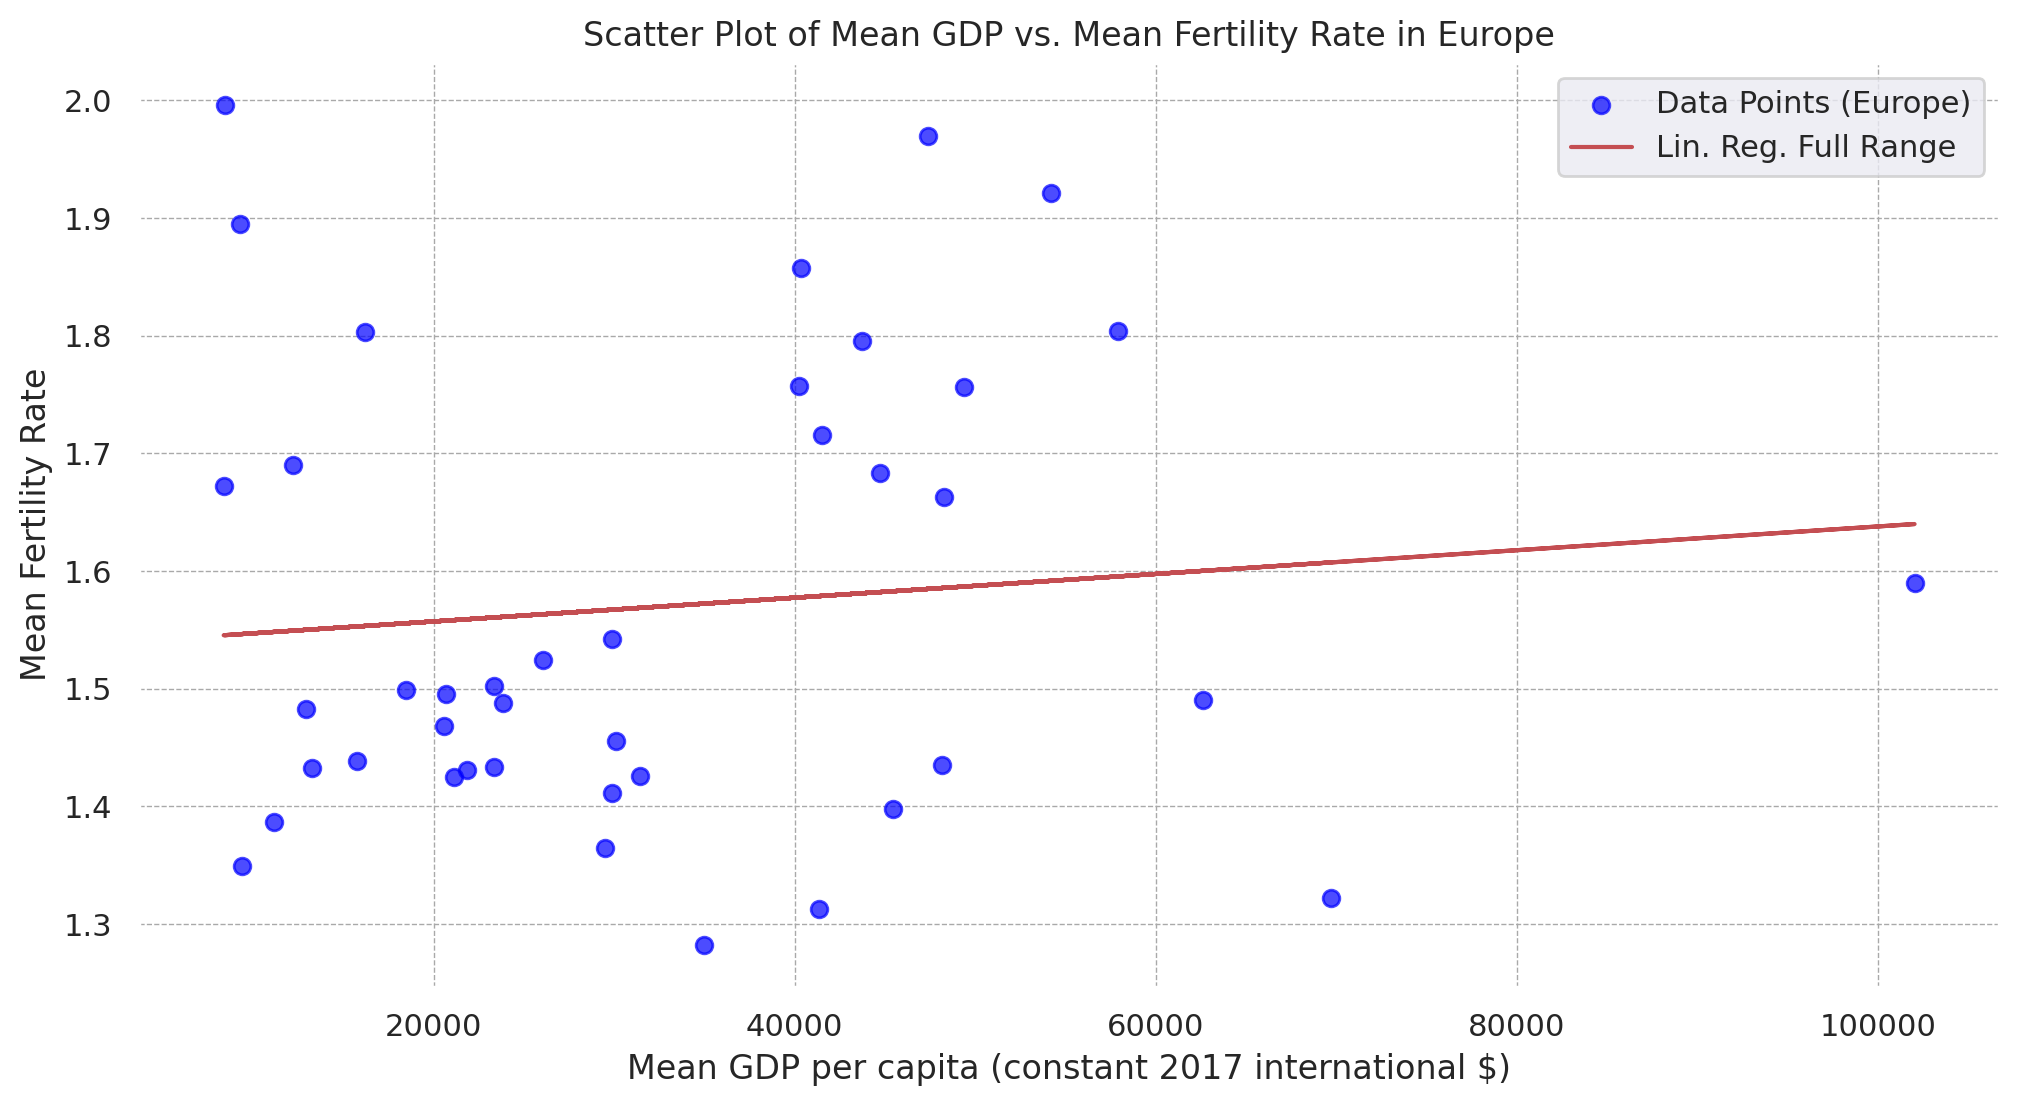

Correlation coefficient: 0.09269798983129657


In [48]:
# Filter data for Europe
europe_df = df_women_gdp[df_women_gdp['Continent'] == 'Europe']

# Calculate the mean of GDP and fertility for each country in Europe
mean_gdp = europe_df.groupby('Entity_x')['GDP_Per_Capita'].mean()
mean_fertility = europe_df.groupby('Entity_x')['Fertility_rate'].mean()

# Create a scatter plot
plt.figure(figsize=(12, 6))
plt.scatter(mean_gdp, mean_fertility, alpha=0.7,label="Data Points (Europe)", color='blue')

# Linear regression line
lin_reg_m_tot, lin_reg_q_tot = linear_regression(mean_gdp, mean_fertility)
y_tot = mean_gdp*lin_reg_m_tot+lin_reg_q_tot
plt.plot(mean_gdp, y_tot, label="Lin. Reg. Full Range",color ='r')

# Set background color to white
plt.gca().set_facecolor('white')

# Set grid color to dark grey and grid style to dashed
plt.grid(color='darkgrey', linestyle='dashed', linewidth=0.5)

plt.legend()

plt.title('Scatter Plot of Mean GDP vs. Mean Fertility Rate in Europe')
plt.xlabel('Mean GDP per capita (constant 2017 international $)')
plt.ylabel('Mean Fertility Rate')
plt.show()

# Correlation Coefficient

result = correlation_coefficient(europe_df, "GDP_Per_Capita", "Fertility_rate")
print(f"Correlation coefficient: {result}")

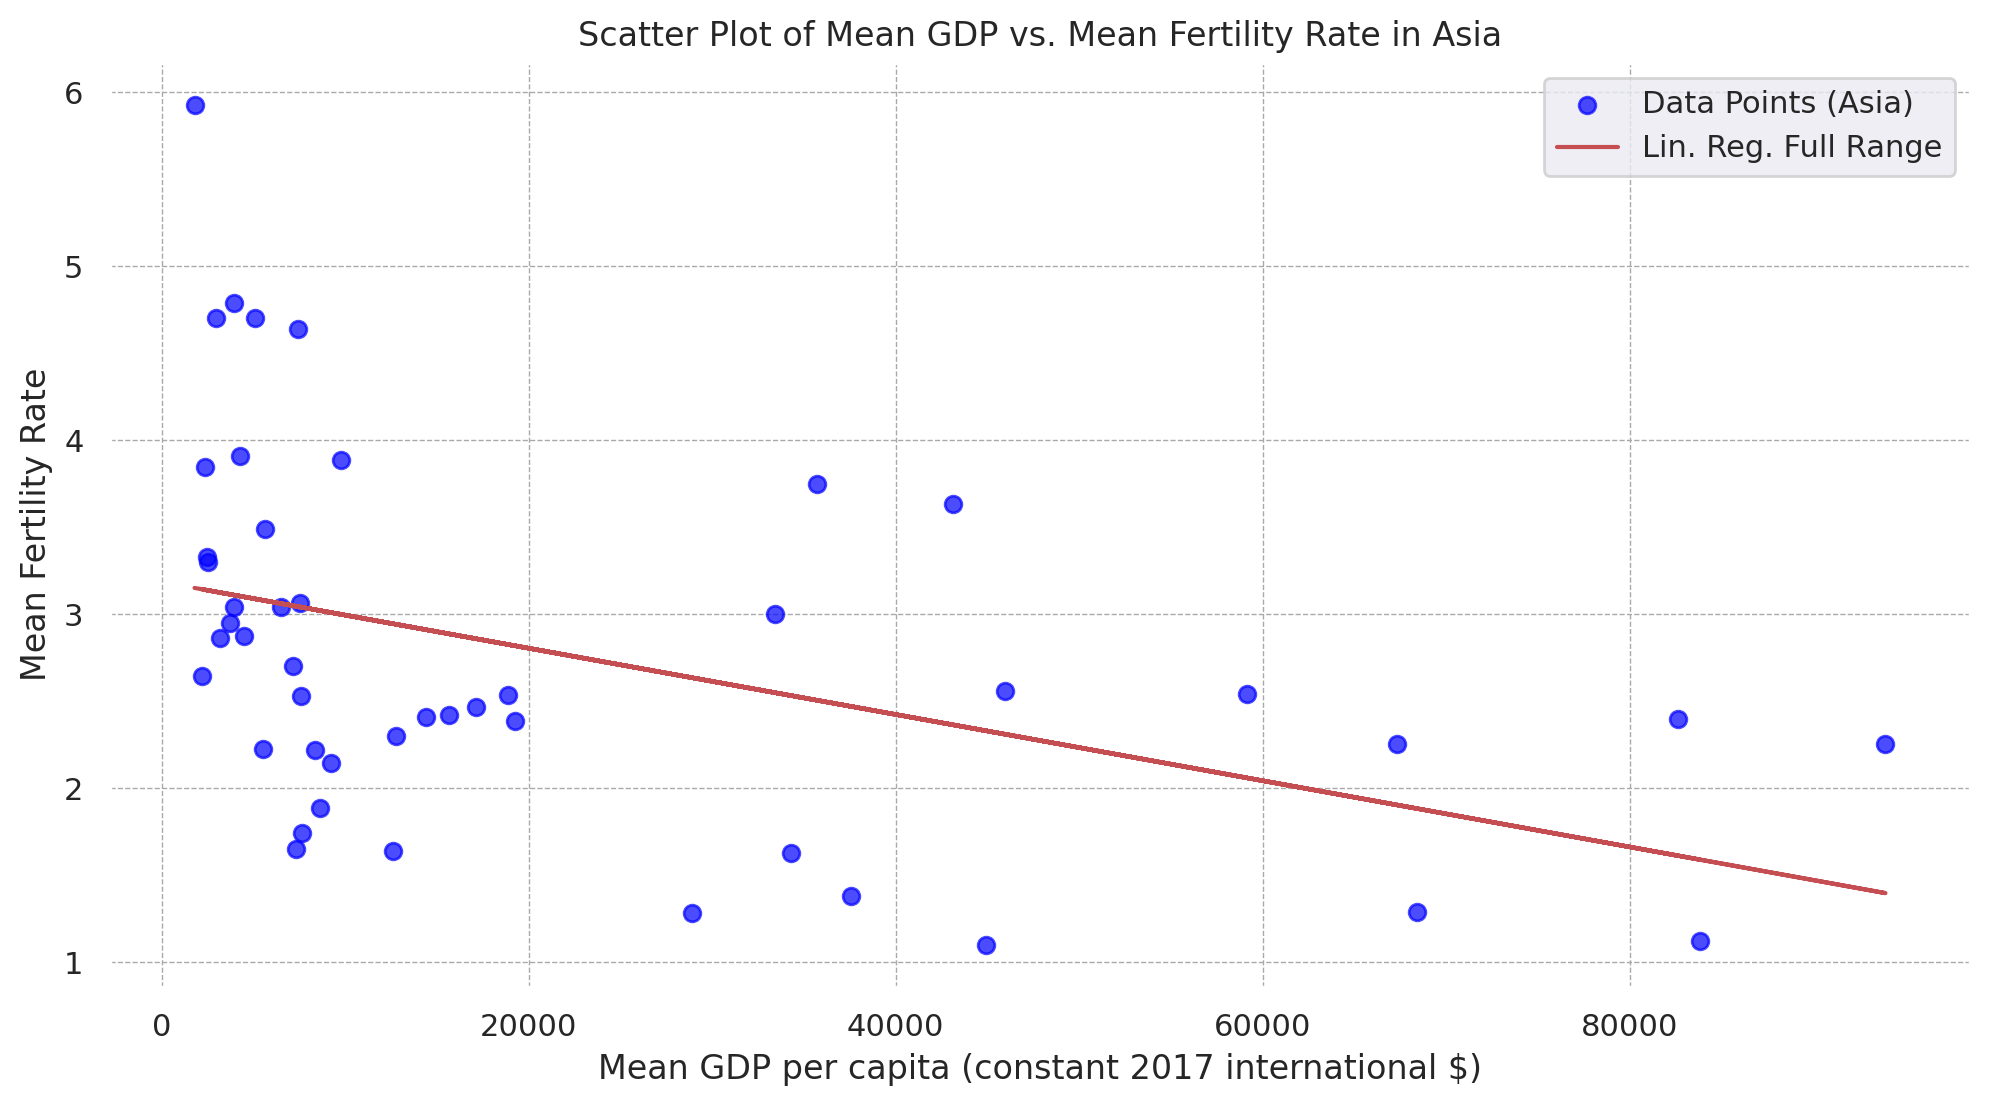

Correlation coefficient: -0.36694270101288673


In [47]:
# Filter data for Asia
asia_df = df_women_gdp[df_women_gdp['Continent'] == 'Asia']

# Calculate the mean of GDP and fertility for each country in Asia
mean_gdp = asia_df.groupby('Entity_x')['GDP_Per_Capita'].mean()
mean_fertility = asia_df.groupby('Entity_x')['Fertility_rate'].mean()

# Create a scatter plot
plt.figure(figsize=(12, 6))
plt.scatter(mean_gdp, mean_fertility, alpha=0.7,label="Data Points (Asia)", color='blue')

# Linear regression line
lin_reg_m_tot, lin_reg_q_tot = linear_regression(mean_gdp, mean_fertility)
y_tot = mean_gdp*lin_reg_m_tot+lin_reg_q_tot
plt.plot(mean_gdp, y_tot, label="Lin. Reg. Full Range",color ='r')

# Set background color to white
plt.gca().set_facecolor('white')

# Set grid color to dark grey and grid style to dashed
plt.grid(color='darkgrey', linestyle='dashed', linewidth=0.5)

plt.legend()

plt.title('Scatter Plot of Mean GDP vs. Mean Fertility Rate in Asia')
plt.xlabel('Mean GDP per capita (constant 2017 international $)')
plt.ylabel('Mean Fertility Rate')
plt.show()

# Correlation Coefficient

result = correlation_coefficient(asia_df, "GDP_Per_Capita", "Fertility_rate")
print(f"Correlation coefficient: {result}")


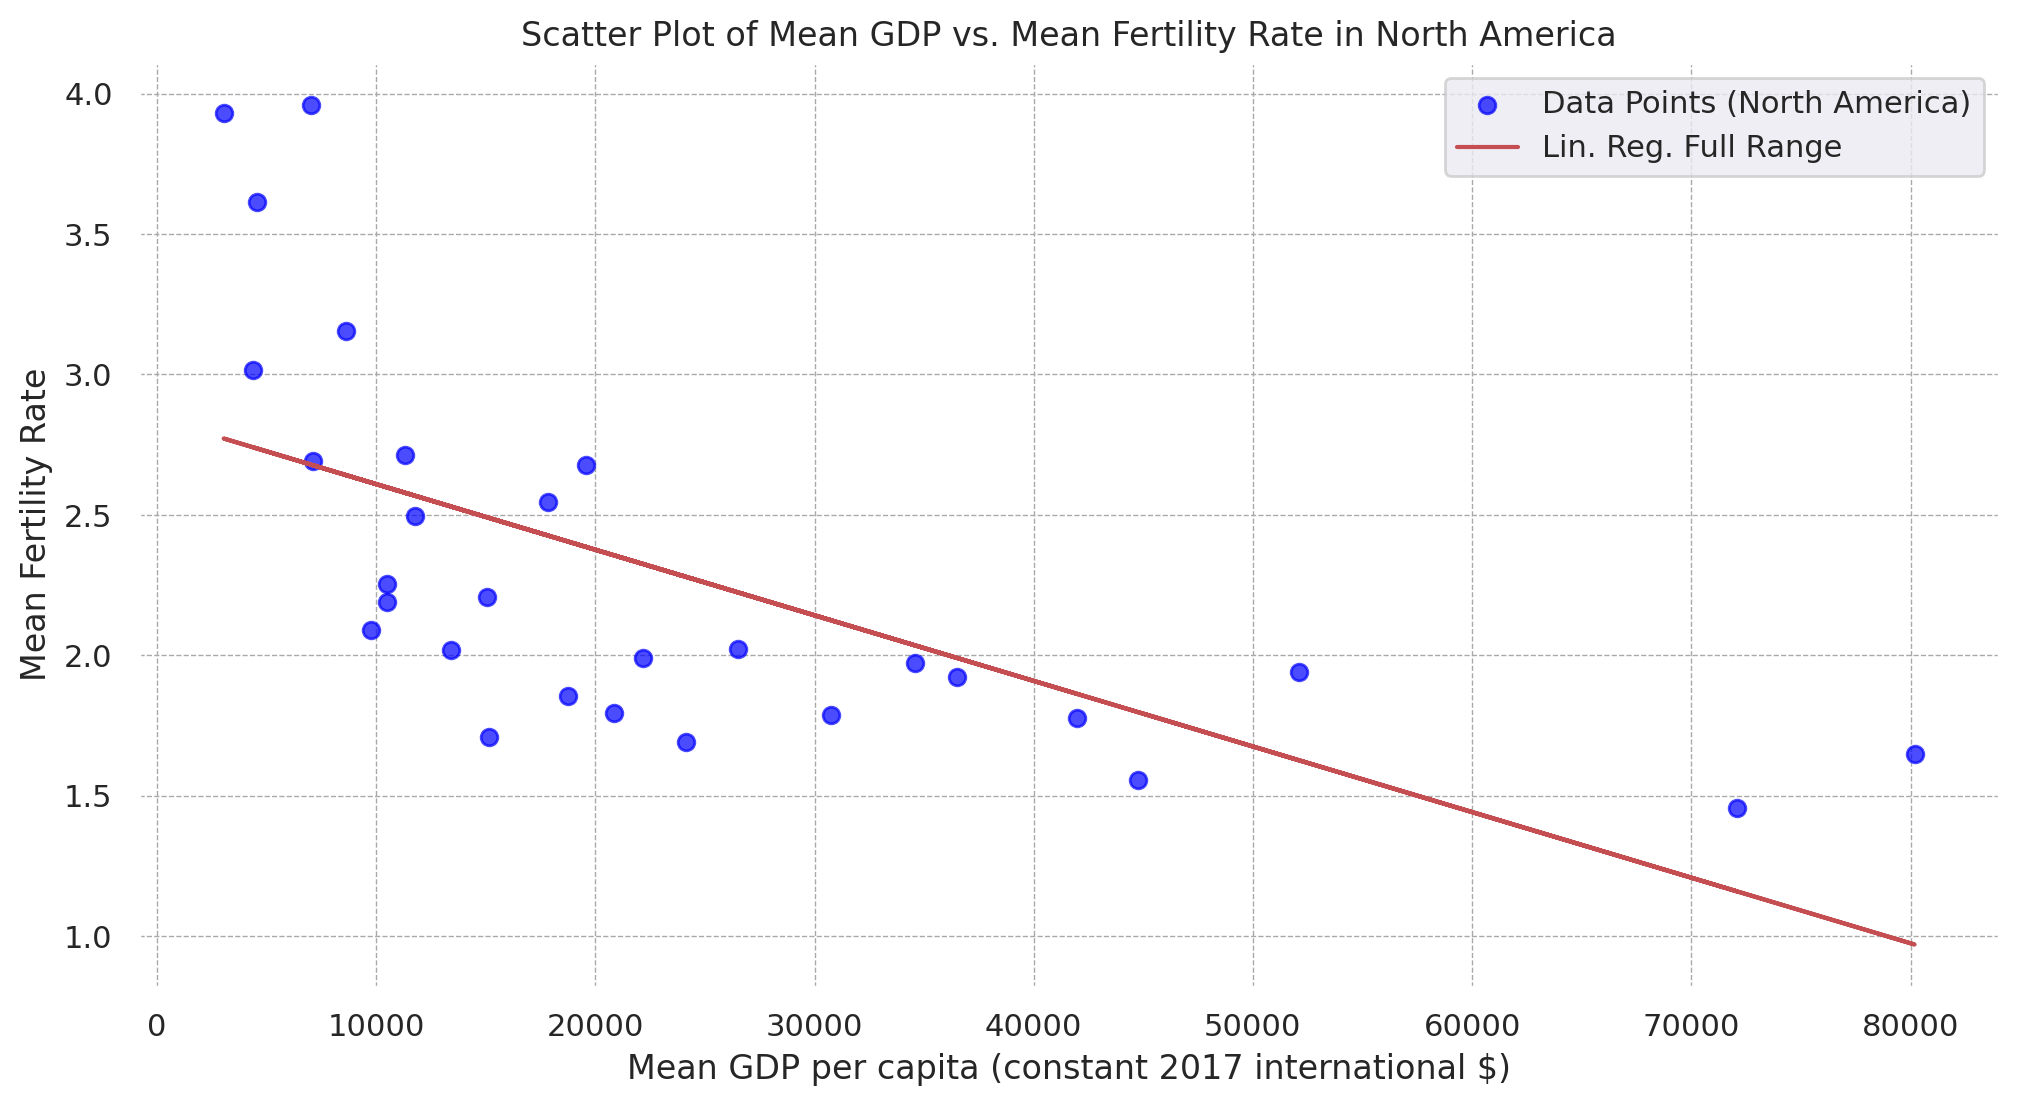

Correlation coefficient: -0.5261509738299542


In [46]:
# Filter data for North America
north_america_df = df_women_gdp[df_women_gdp['Continent'] == 'North America']

# Calculate the mean of GDP and fertility for each country in North America
mean_gdp = north_america_df.groupby('Entity_x')['GDP_Per_Capita'].mean()
mean_fertility = north_america_df.groupby('Entity_x')['Fertility_rate'].mean()

# Create a scatter plot
plt.figure(figsize=(12, 6))
plt.scatter(mean_gdp, mean_fertility, alpha=0.7,label="Data Points (North America)", color='blue')

# Linear regression line
lin_reg_m_tot, lin_reg_q_tot = linear_regression(mean_gdp, mean_fertility)
y_tot = mean_gdp*lin_reg_m_tot+lin_reg_q_tot
plt.plot(mean_gdp, y_tot, label="Lin. Reg. Full Range",color ='r')

# Set background color to white
plt.gca().set_facecolor('white')

# Set grid color to dark grey and grid style to dashed
plt.grid(color='darkgrey', linestyle='dashed', linewidth=0.5)

plt.legend()

plt.title('Scatter Plot of Mean GDP vs. Mean Fertility Rate in North America')
plt.xlabel('Mean GDP per capita (constant 2017 international $)')
plt.ylabel('Mean Fertility Rate')
plt.show()

# Correlation Coefficient

result = correlation_coefficient(north_america_df, "GDP_Per_Capita", "Fertility_rate")
print(f"Correlation coefficient: {result}")


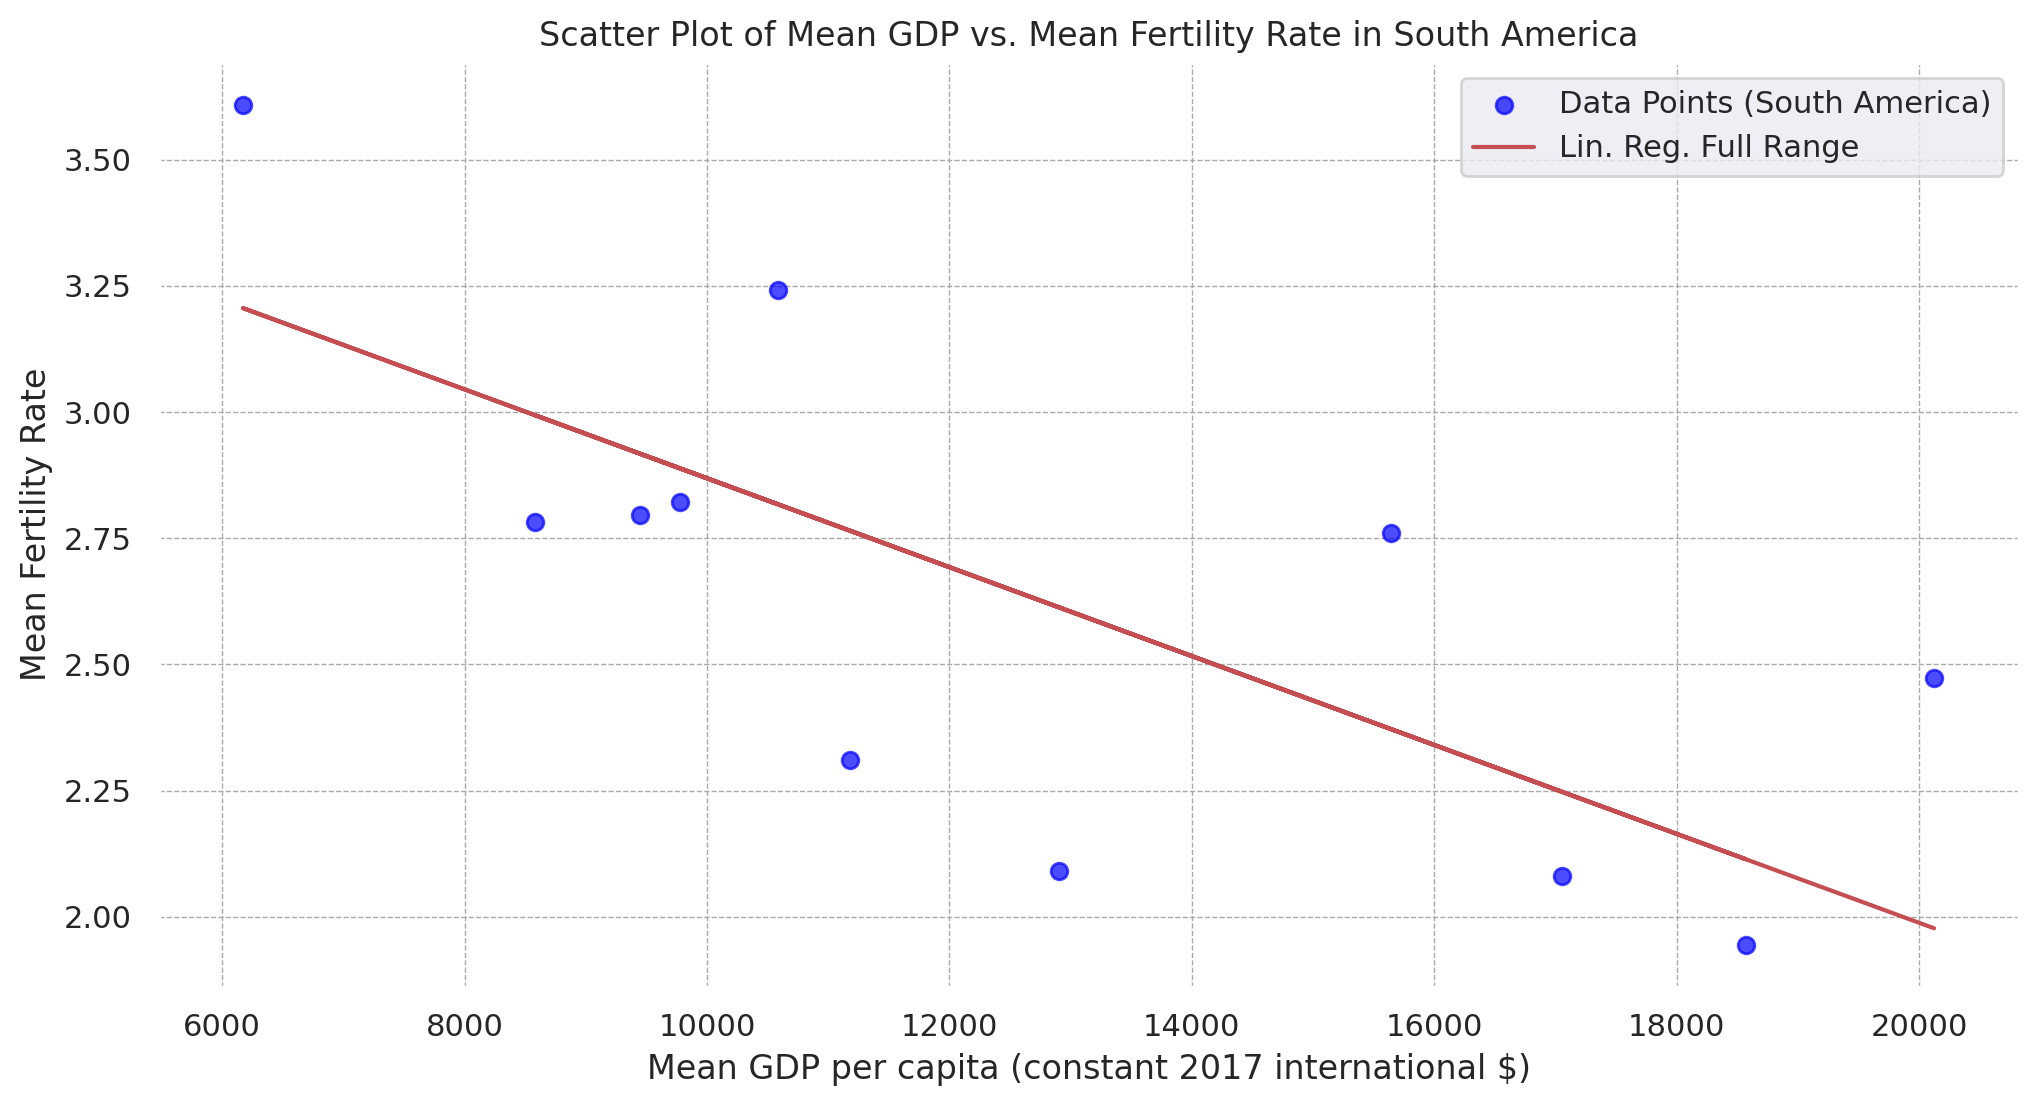

Correlation coefficient: -0.6788826770439251


In [45]:
# Filter data for South America
south_america_df = df_women_gdp[df_women_gdp['Continent'] == 'South America']

# Calculate the mean of GDP and fertility for each country in South America
mean_gdp = south_america_df.groupby('Entity_x')['GDP_Per_Capita'].mean()
mean_fertility = south_america_df.groupby('Entity_x')['Fertility_rate'].mean()

# Create a scatter plot
plt.figure(figsize=(12, 6))
plt.scatter(mean_gdp, mean_fertility, alpha=0.7,label="Data Points (South America)", color='blue')

# Linear regression line
lin_reg_m_tot, lin_reg_q_tot = linear_regression(mean_gdp, mean_fertility)
y_tot = mean_gdp*lin_reg_m_tot+lin_reg_q_tot
plt.plot(mean_gdp, y_tot, label="Lin. Reg. Full Range",color ='r')

# Set background color to white
plt.gca().set_facecolor('white')

# Set grid color to dark grey and grid style to dashed
plt.grid(color='darkgrey', linestyle='dashed', linewidth=0.5)

# Add legend
plt.legend()

plt.title('Scatter Plot of Mean GDP vs. Mean Fertility Rate in South America')
plt.xlabel('Mean GDP per capita (constant 2017 international $)')
plt.ylabel('Mean Fertility Rate')
plt.show()

# Correlation Coefficient

result = correlation_coefficient(south_america_df, "GDP_Per_Capita", "Fertility_rate")
print(f"Correlation coefficient: {result}")

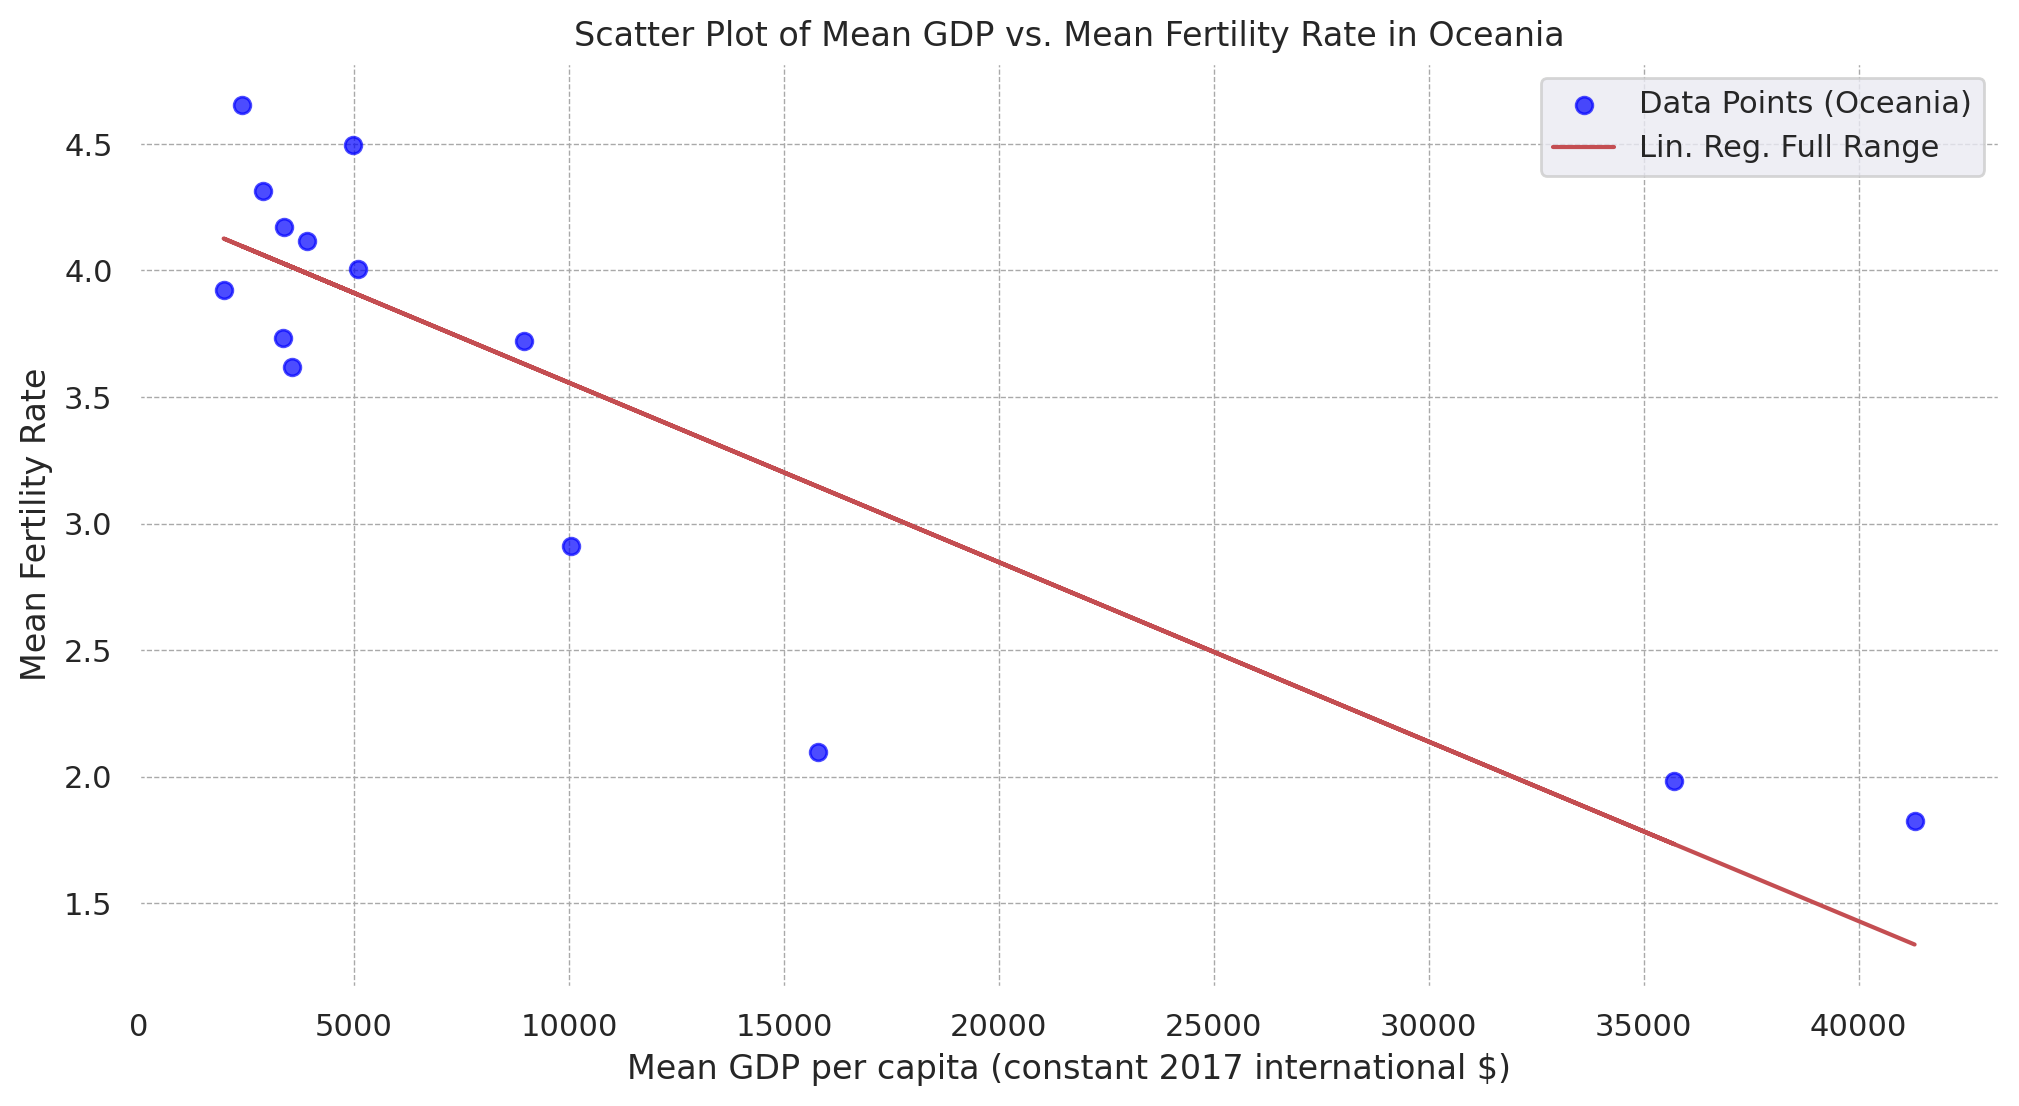

Correlation coefficient: -0.7853001832408083


In [42]:
# Filter data for Oceania
oceania_df = df_women_gdp[df_women_gdp['Continent'] == 'Oceania']

# Calculate the mean of GDP and fertility for each country in Oceania
mean_gdp = oceania_df.groupby('Entity_x')['GDP_Per_Capita'].mean()
mean_fertility = oceania_df.groupby('Entity_x')['Fertility_rate'].mean()

# Create a scatter plot with blue data points
plt.figure(figsize=(12, 6))
plt.scatter(mean_gdp, mean_fertility, alpha=0.7, label="Data Points (Oceania)", color='blue')

# Linear regression line
lin_reg_m_tot, lin_reg_q_tot = linear_regression(mean_gdp, mean_fertility)
y_tot = mean_gdp * lin_reg_m_tot + lin_reg_q_tot
plt.plot(mean_gdp, y_tot, label="Lin. Reg. Full Range", color='r')

# Set background color to white
plt.gca().set_facecolor('white')

# Set grid color to dark grey and grid style to dashed
plt.grid(color='darkgrey', linestyle='dashed', linewidth=0.5)

# Add legend
plt.legend()

plt.title('Scatter Plot of Mean GDP vs. Mean Fertility Rate in Oceania')
plt.xlabel('Mean GDP per capita (constant 2017 international $)')
plt.ylabel('Mean Fertility Rate')
plt.show()

# Correlation Coefficient
result = correlation_coefficient(oceania_df, "GDP_Per_Capita", "Fertility_rate")
print(f"Correlation coefficient: {result}")


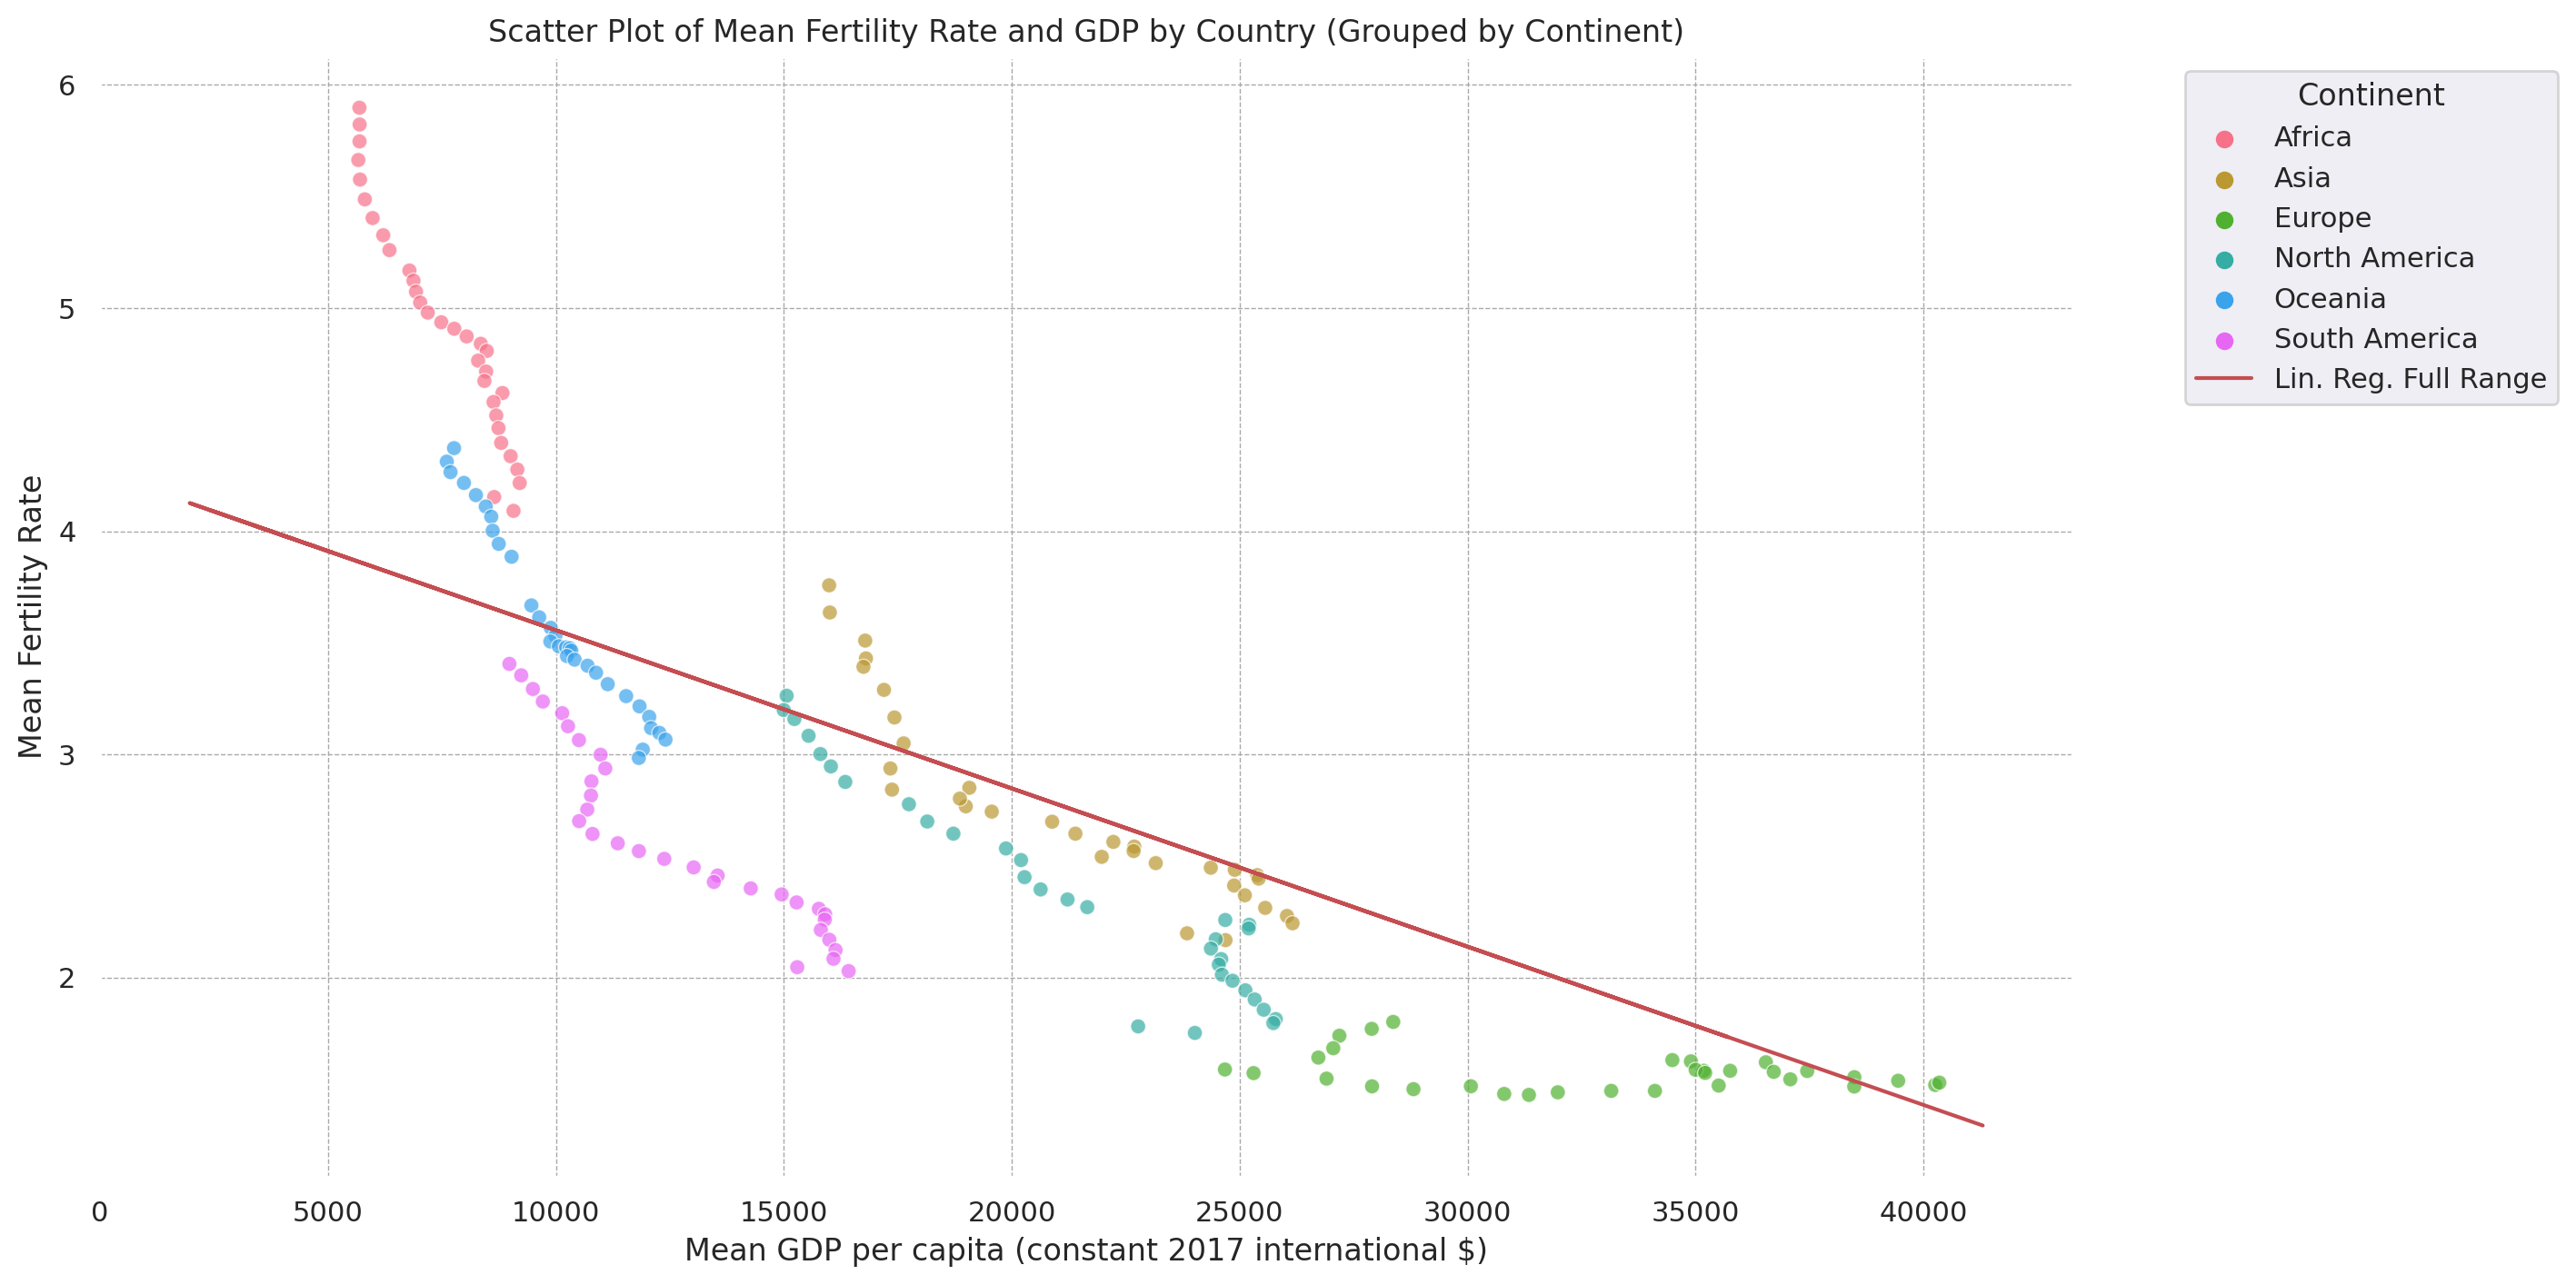

Correlation coefficient: -0.845133003373096


In [31]:
scatter_df = df_women_gdp[['GDP_Per_Capita', 'Fertility_rate', 'Year', 'Continent']]

# Exclude the 'World' group
scatter_df = scatter_df[scatter_df['Continent'] != 'World']

# Calculate the mean for each country
mean_df = scatter_df.groupby(['Continent', 'Year']).mean().reset_index()

# Set the color palette for each continent
sns.set_palette("husl")

# Create a scatter plot for each country, grouped by continent
plt.figure(figsize=(14, 8))
sns.scatterplot(
    x='GDP_Per_Capita',
    y='Fertility_rate',
    hue='Continent',
    data=mean_df,
    alpha=0.7,
    legend='full',
)

# Linear regression line
lin_reg_m_tot, lin_reg_q_tot = linear_regression(mean_gdp, mean_fertility)
y_tot = mean_gdp*lin_reg_m_tot+lin_reg_q_tot
plt.plot(mean_gdp, y_tot, label="Lin. Reg. Full Range",color ='r')

plt.title('Scatter Plot of Mean Fertility Rate and GDP by Country (Grouped by Continent)')
plt.xlabel('Mean GDP per capita (constant 2017 international $)')
plt.ylabel('Mean Fertility Rate')
plt.legend(title='Continent', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.gca().set_facecolor('white')

plt.grid(color='darkgrey', linestyle='dashed', linewidth=0.5)

plt.show()

# Correlation Coefficient

result = correlation_coefficient(mean_df,"GDP_Per_Capita", "Fertility_rate")
print(f"Correlation coefficient: {result}")

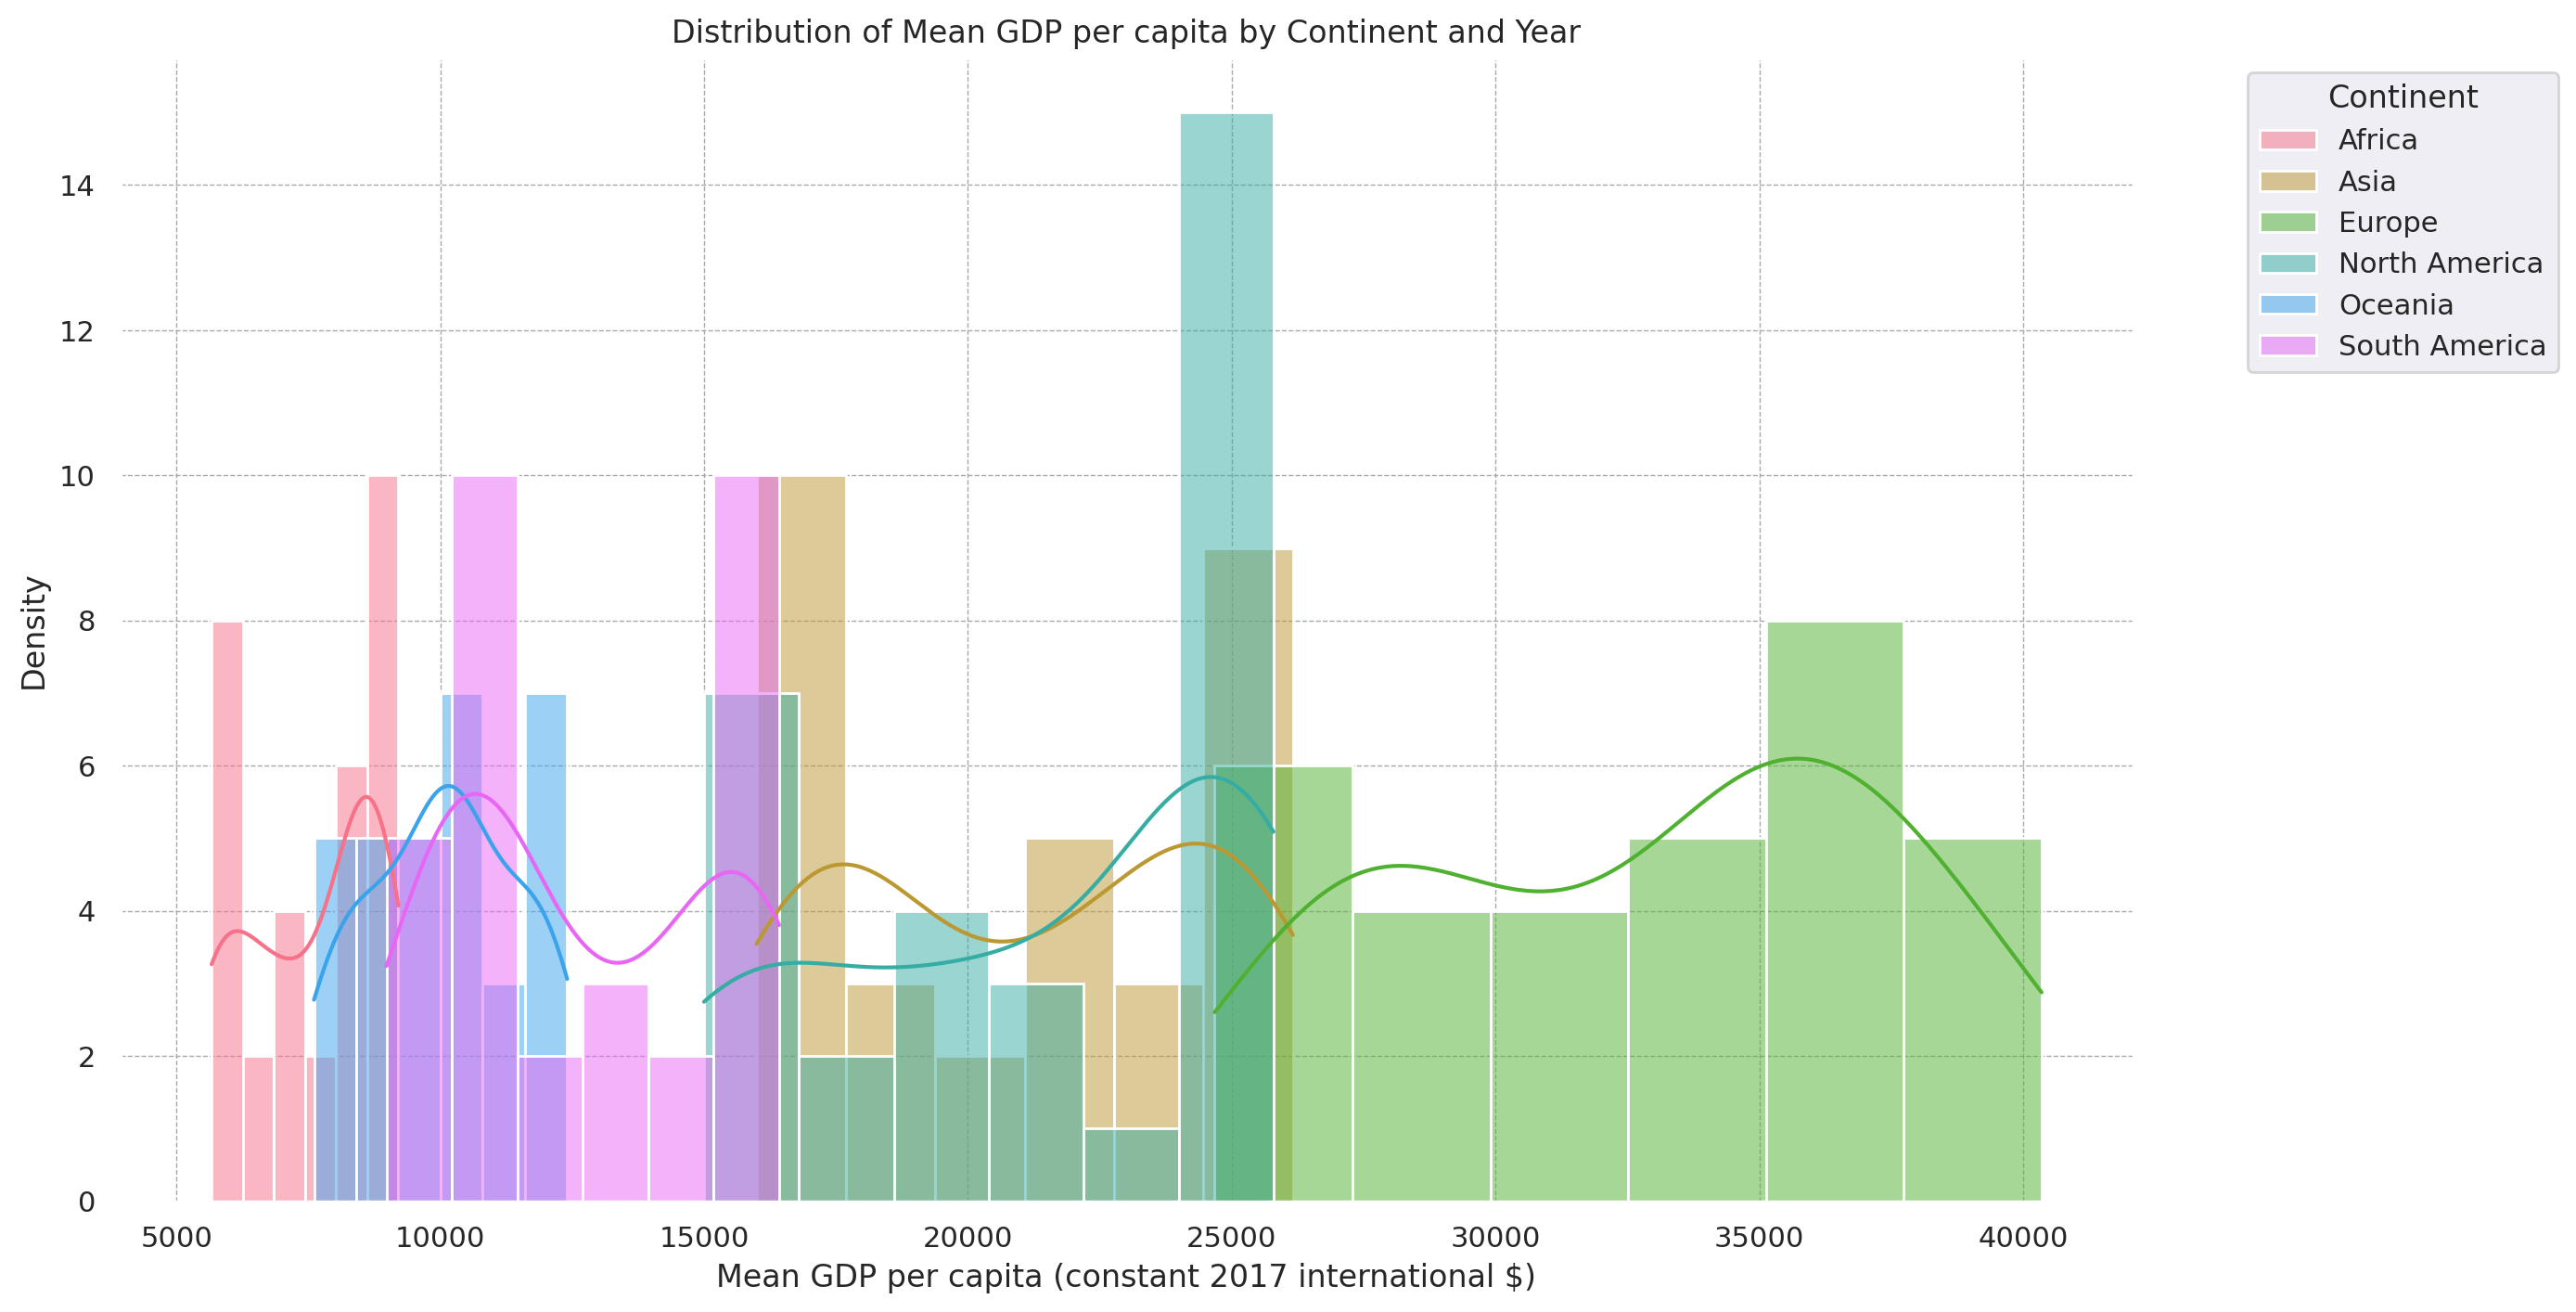

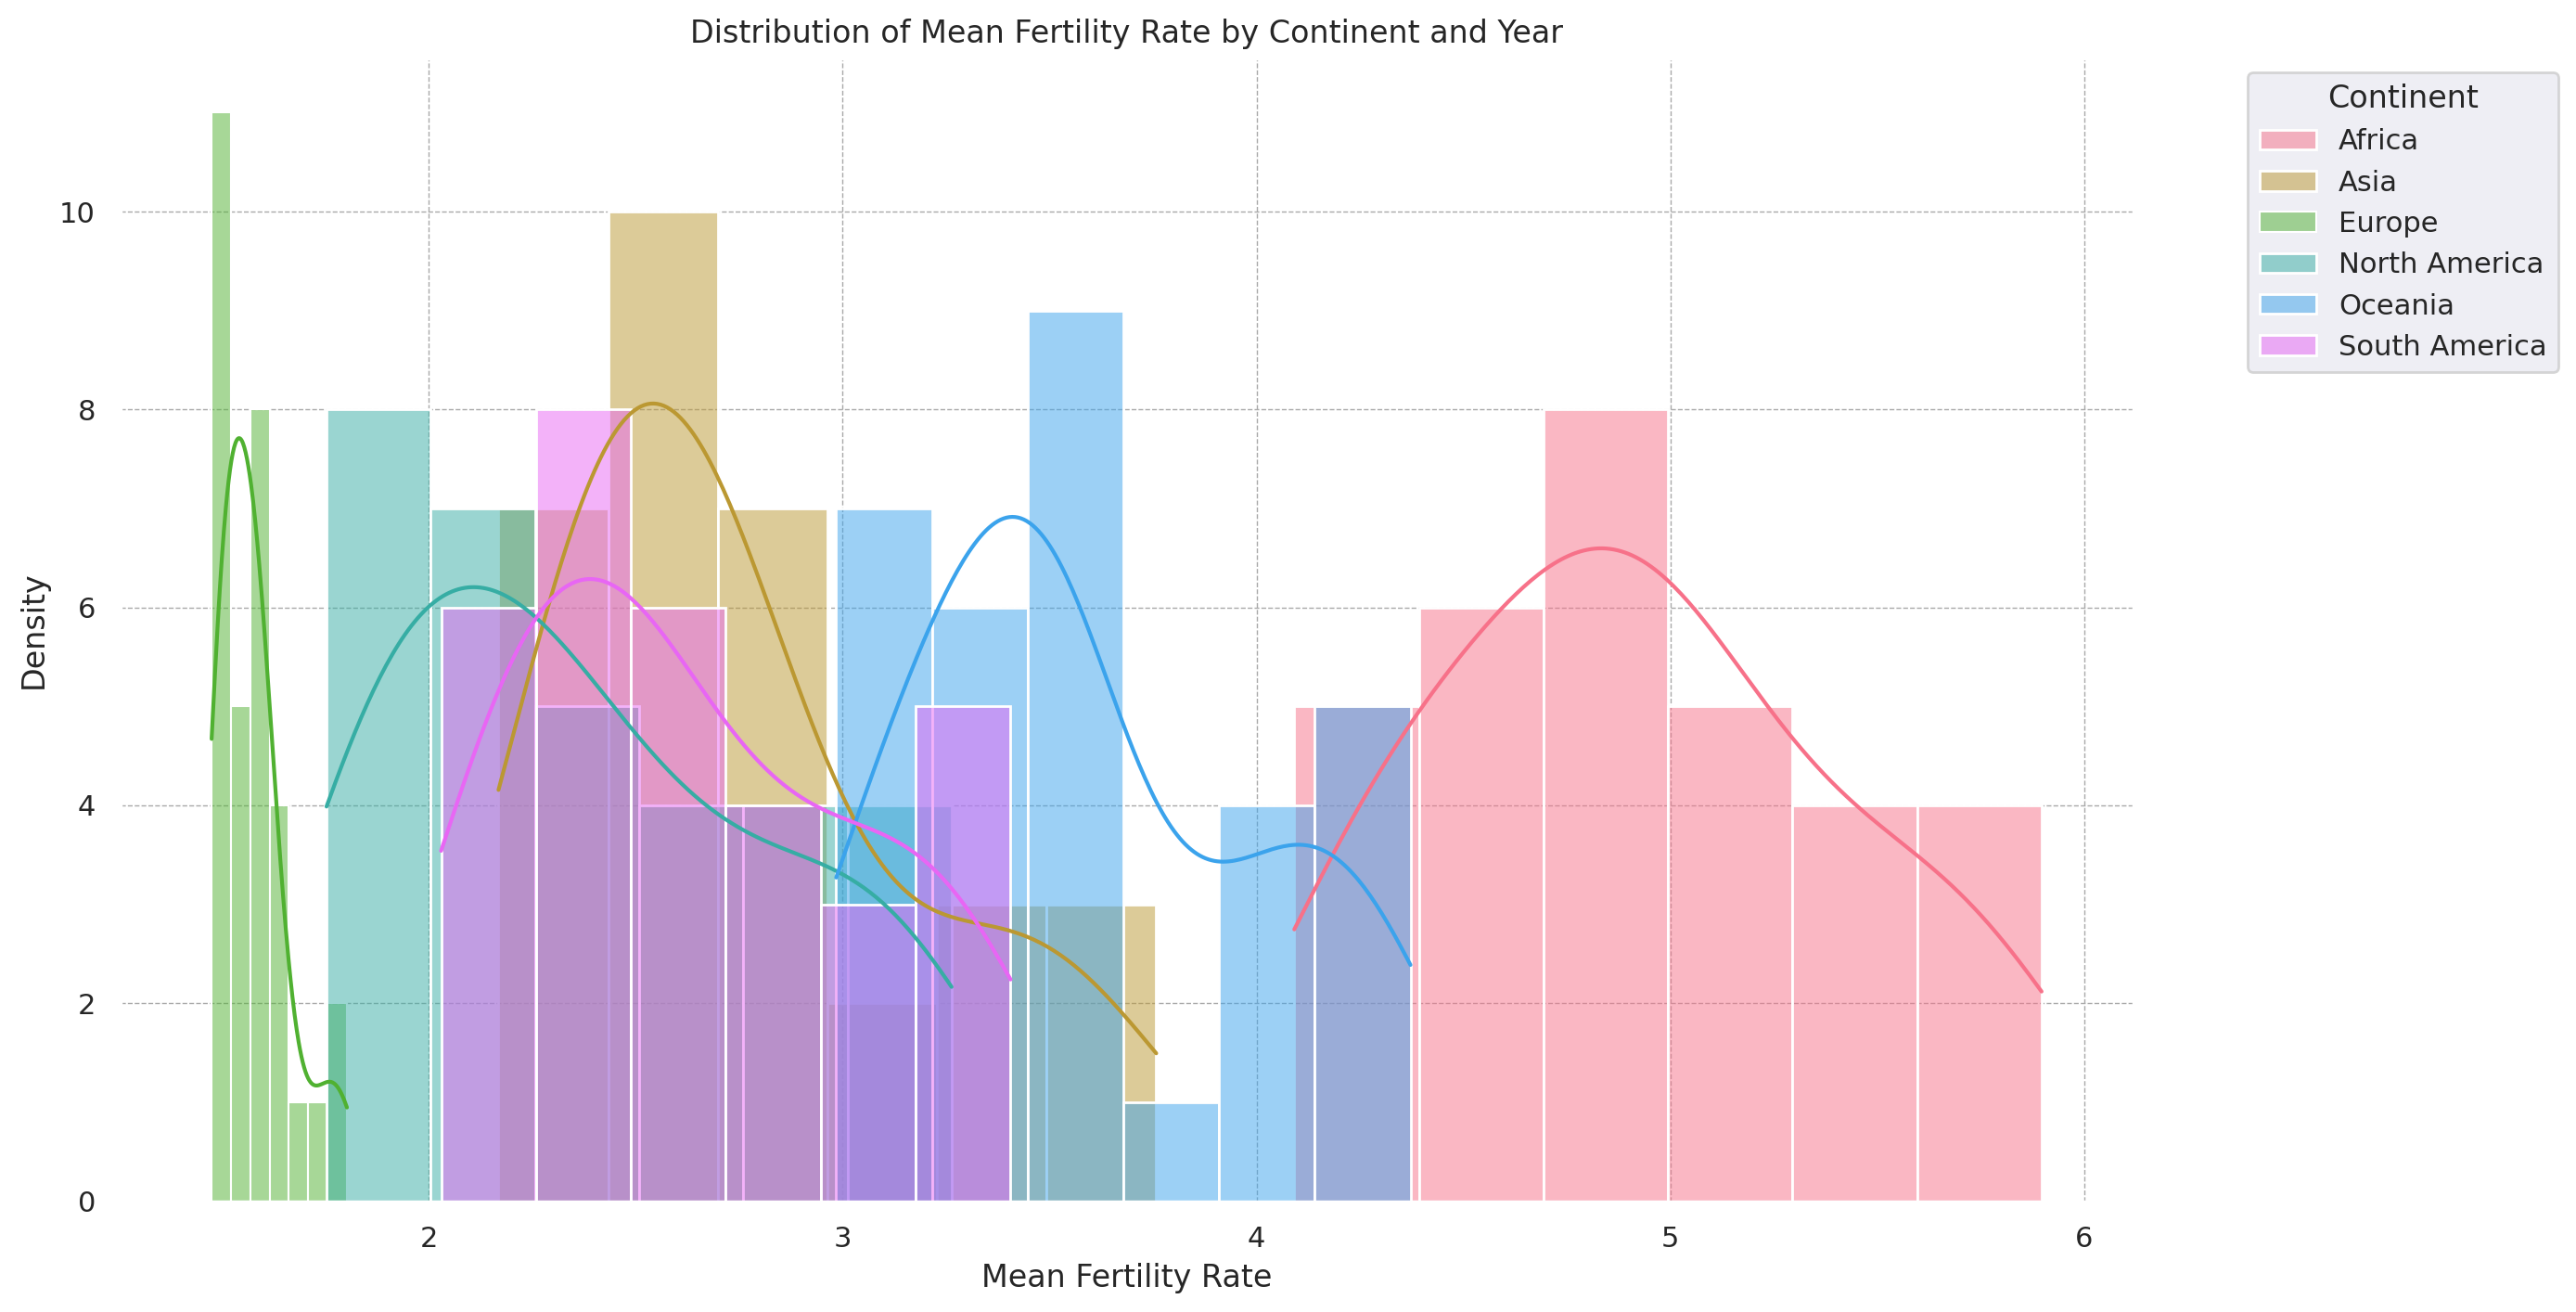

In [32]:
distplot_df = df_women_gdp[['GDP_Per_Capita', 'Fertility_rate', 'Year', 'Continent']]

# Exclude the 'World' group
distplot_df = distplot_df[distplot_df['Continent'] != 'World']

# Calculate the mean for each country
mean_df = distplot_df.groupby(['Continent', 'Year']).mean().reset_index()

# Set the color palette for each continent
sns.set_palette("husl")

# Create separate histograms for each continent
plt.figure(figsize=(14, 8))
for continent in mean_df['Continent'].unique():
    subset = mean_df[mean_df['Continent'] == continent]
    sns.histplot(data=subset, x='GDP_Per_Capita', kde=True, label=continent)

plt.title('Distribution of Mean GDP per capita by Continent and Year')
plt.xlabel('Mean GDP per capita (constant 2017 international $)')
plt.ylabel('Density')
plt.legend(title='Continent', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.gca().set_facecolor('white')

plt.grid(color='darkgrey', linestyle='dashed', linewidth=0.5)

plt.show()

# Create separate histograms for each continent
plt.figure(figsize=(14, 8))
for continent in mean_df['Continent'].unique():
    subset = mean_df[mean_df['Continent'] == continent]
    sns.histplot(data=subset, x='Fertility_rate', kde=True, label=continent)

plt.title('Distribution of Mean Fertility Rate by Continent and Year')
plt.xlabel('Mean Fertility Rate')
plt.ylabel('Density')
plt.legend(title='Continent', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.gca().set_facecolor('white')

plt.grid(color='darkgrey', linestyle='dashed', linewidth=0.5)

plt.show()


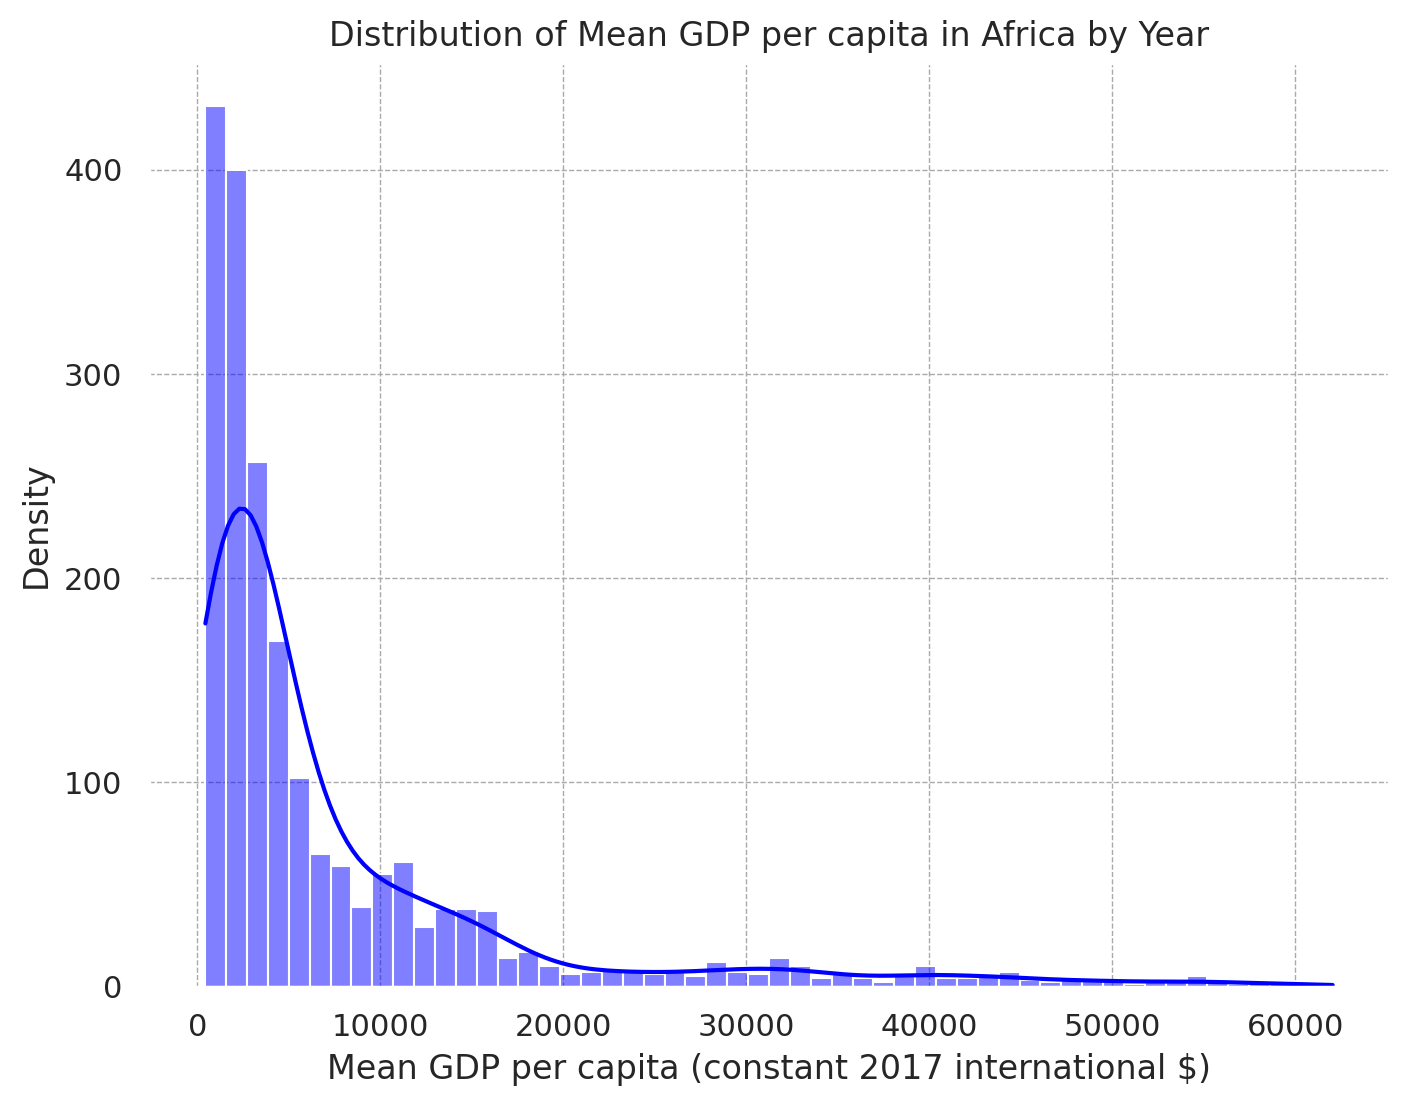

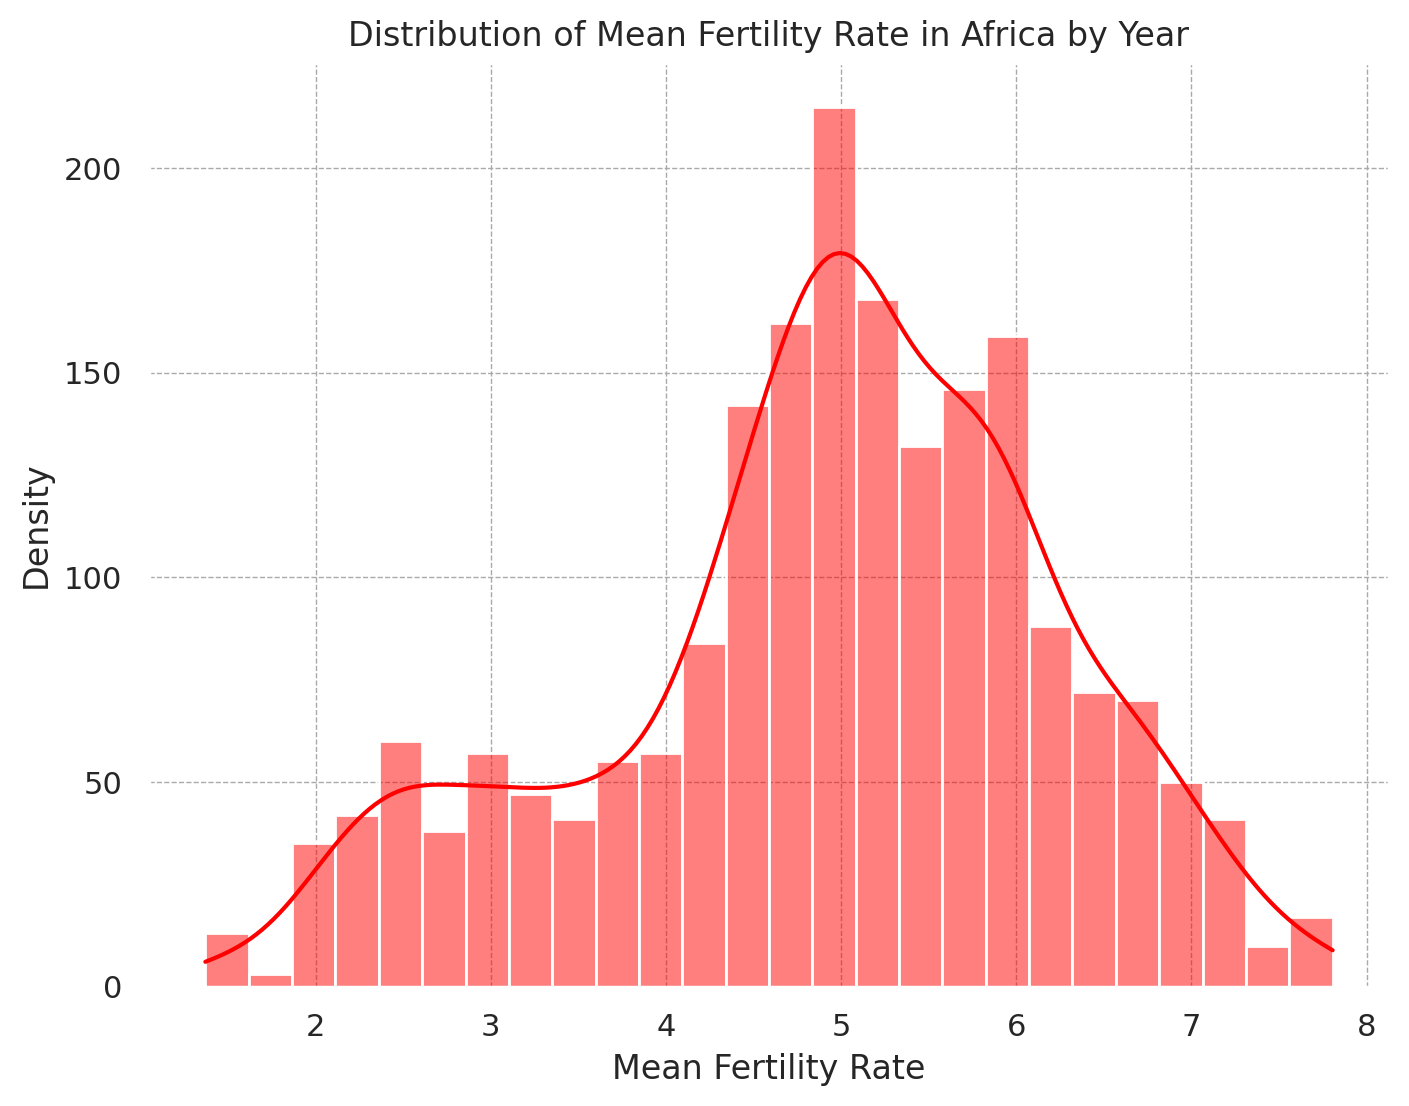

In [33]:
africa_df = df_women_gdp[df_women_gdp['Continent'] == 'Africa']

# Set the color palette
sns.set_palette("husl")

# Create distplot for GDP
plt.figure(figsize=(8, 6))
sns.histplot(data=africa_df, x='GDP_Per_Capita', kde=True, color='blue')
plt.title('Distribution of Mean GDP per capita in Africa by Year')
plt.xlabel('Mean GDP per capita (constant 2017 international $)')
plt.ylabel('Density')

plt.gca().set_facecolor('white')

plt.grid(color='darkgrey', linestyle='dashed', linewidth=0.5)

plt.show()

# Create distplot for Fertility Rate
plt.figure(figsize=(8, 6))
sns.histplot(data=africa_df, x='Fertility_rate', kde=True, color='red')
plt.title('Distribution of Mean Fertility Rate in Africa by Year')
plt.xlabel('Mean Fertility Rate')
plt.ylabel('Density')

plt.gca().set_facecolor('white')

plt.grid(color='darkgrey', linestyle='dashed', linewidth=0.5)

plt.show()


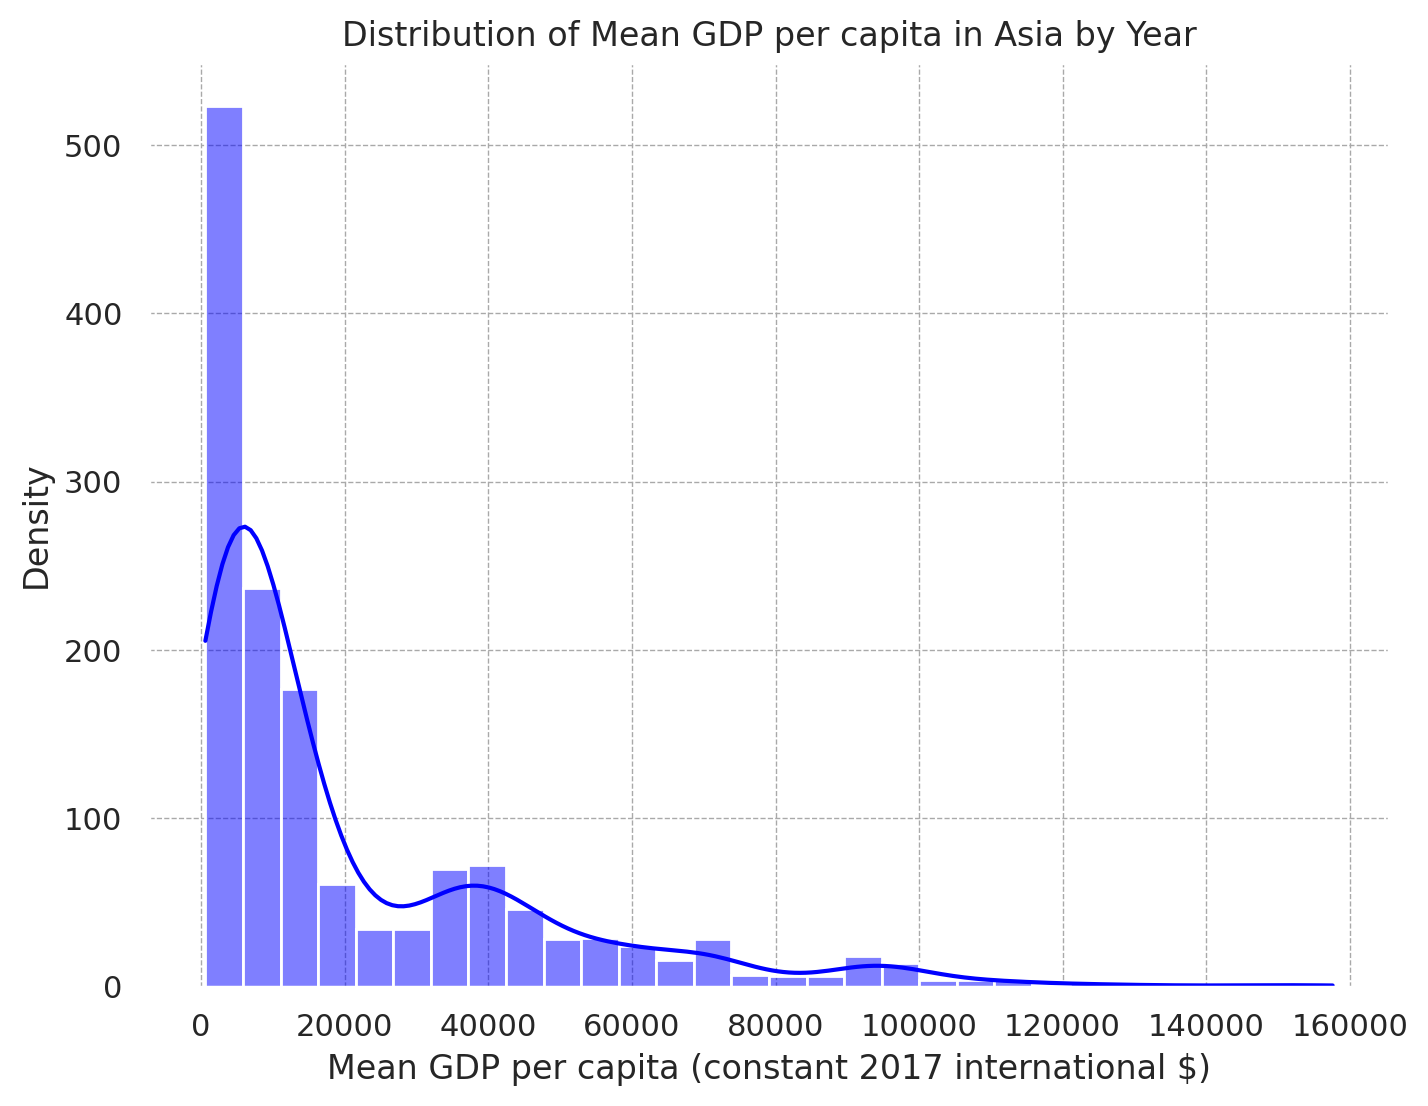

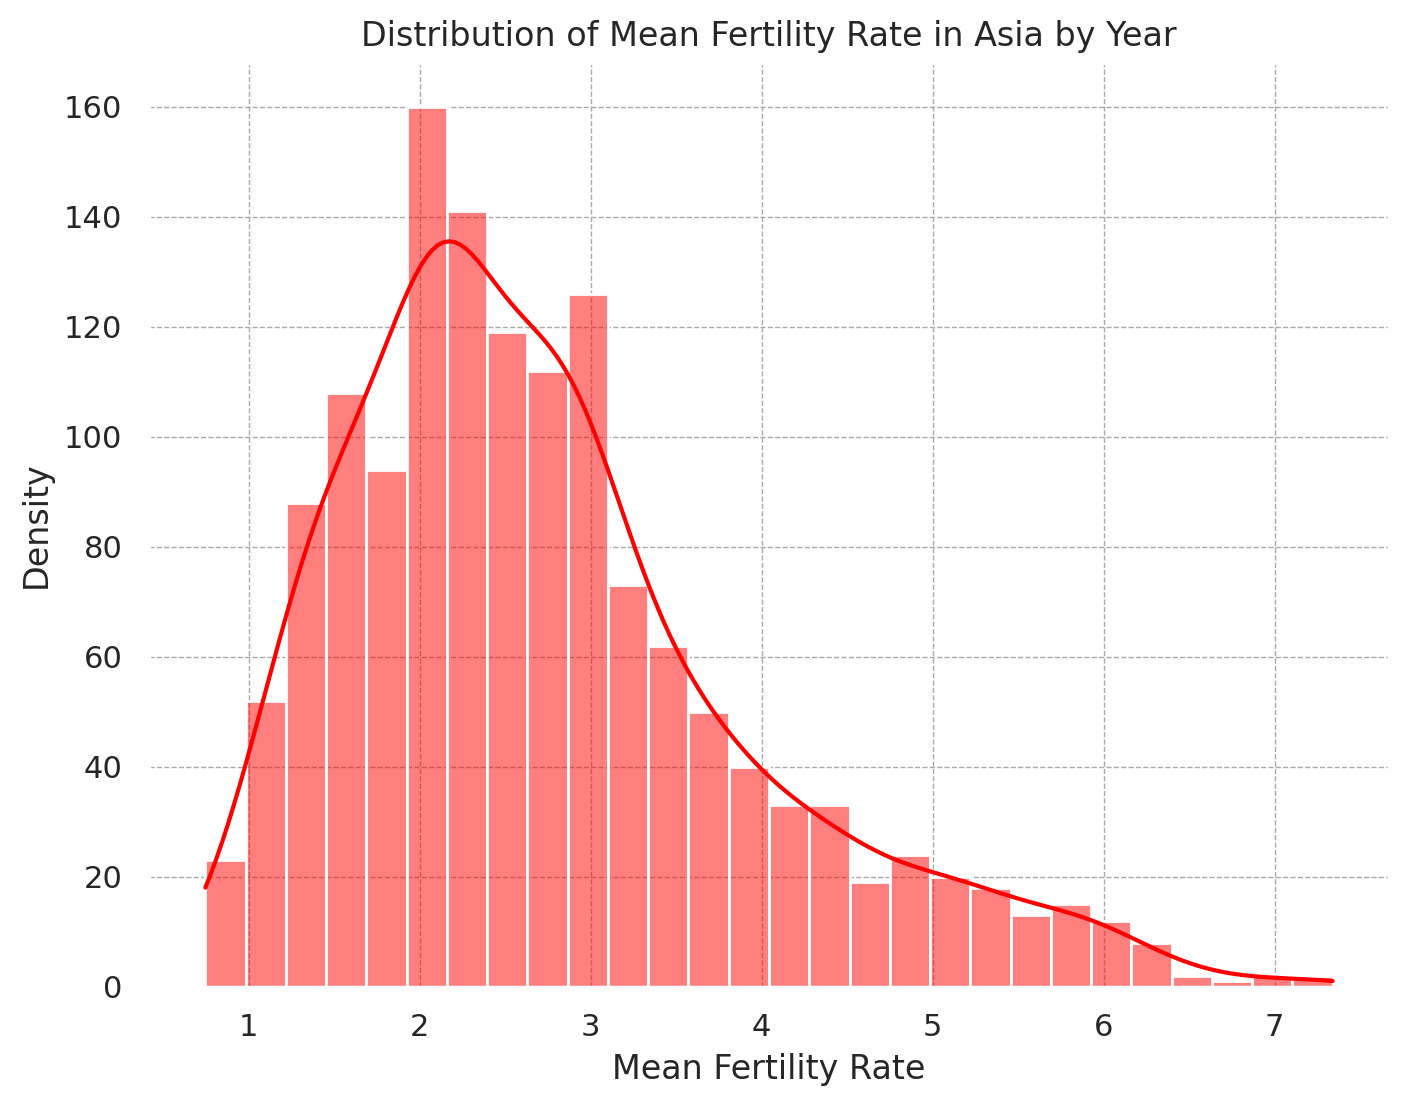

In [34]:
asia_df = df_women_gdp[df_women_gdp['Continent'] == 'Asia']

# Set the color palette
sns.set_palette("husl")

# Create distplot for GDP
plt.figure(figsize=(8, 6))
sns.histplot(data=asia_df, x='GDP_Per_Capita', kde=True, color='blue')
plt.title('Distribution of Mean GDP per capita in Asia by Year')
plt.xlabel('Mean GDP per capita (constant 2017 international $)')
plt.ylabel('Density')

plt.gca().set_facecolor('white')

plt.grid(color='darkgrey', linestyle='dashed', linewidth=0.5)

plt.show()

# Create distplot for Fertility Rate
plt.figure(figsize=(8, 6))
sns.histplot(data=asia_df, x='Fertility_rate', kde=True, color='red')
plt.title('Distribution of Mean Fertility Rate in Asia by Year')
plt.xlabel('Mean Fertility Rate')
plt.ylabel('Density')

plt.gca().set_facecolor('white')

plt.grid(color='darkgrey', linestyle='dashed', linewidth=0.5)

plt.show()


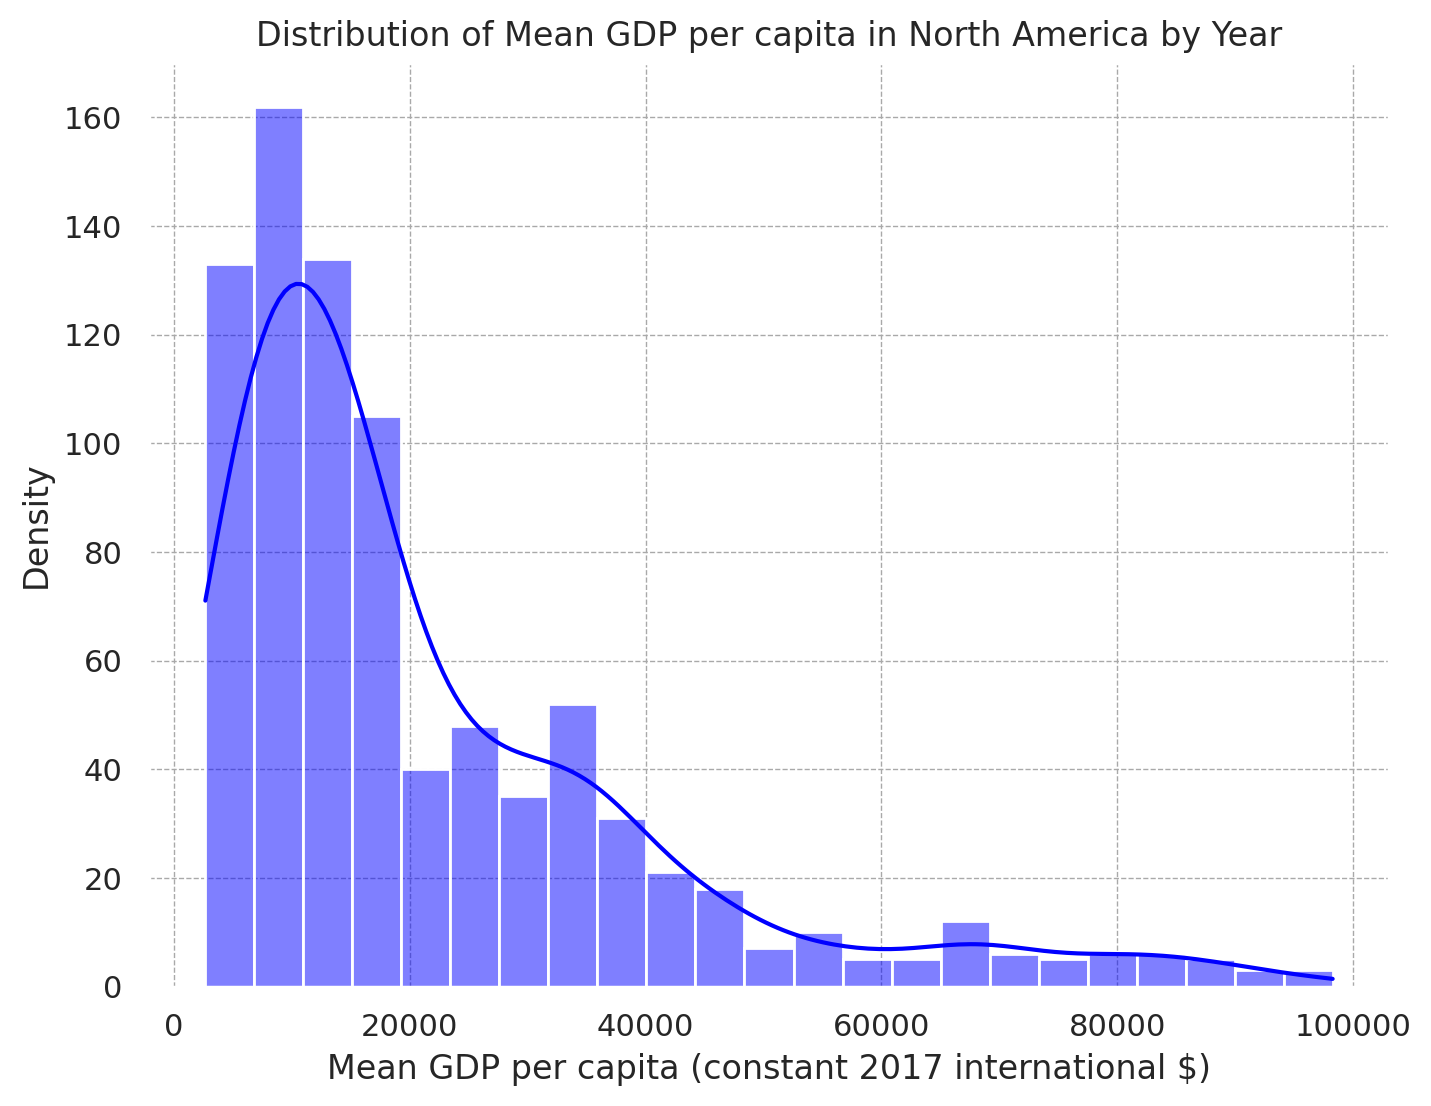

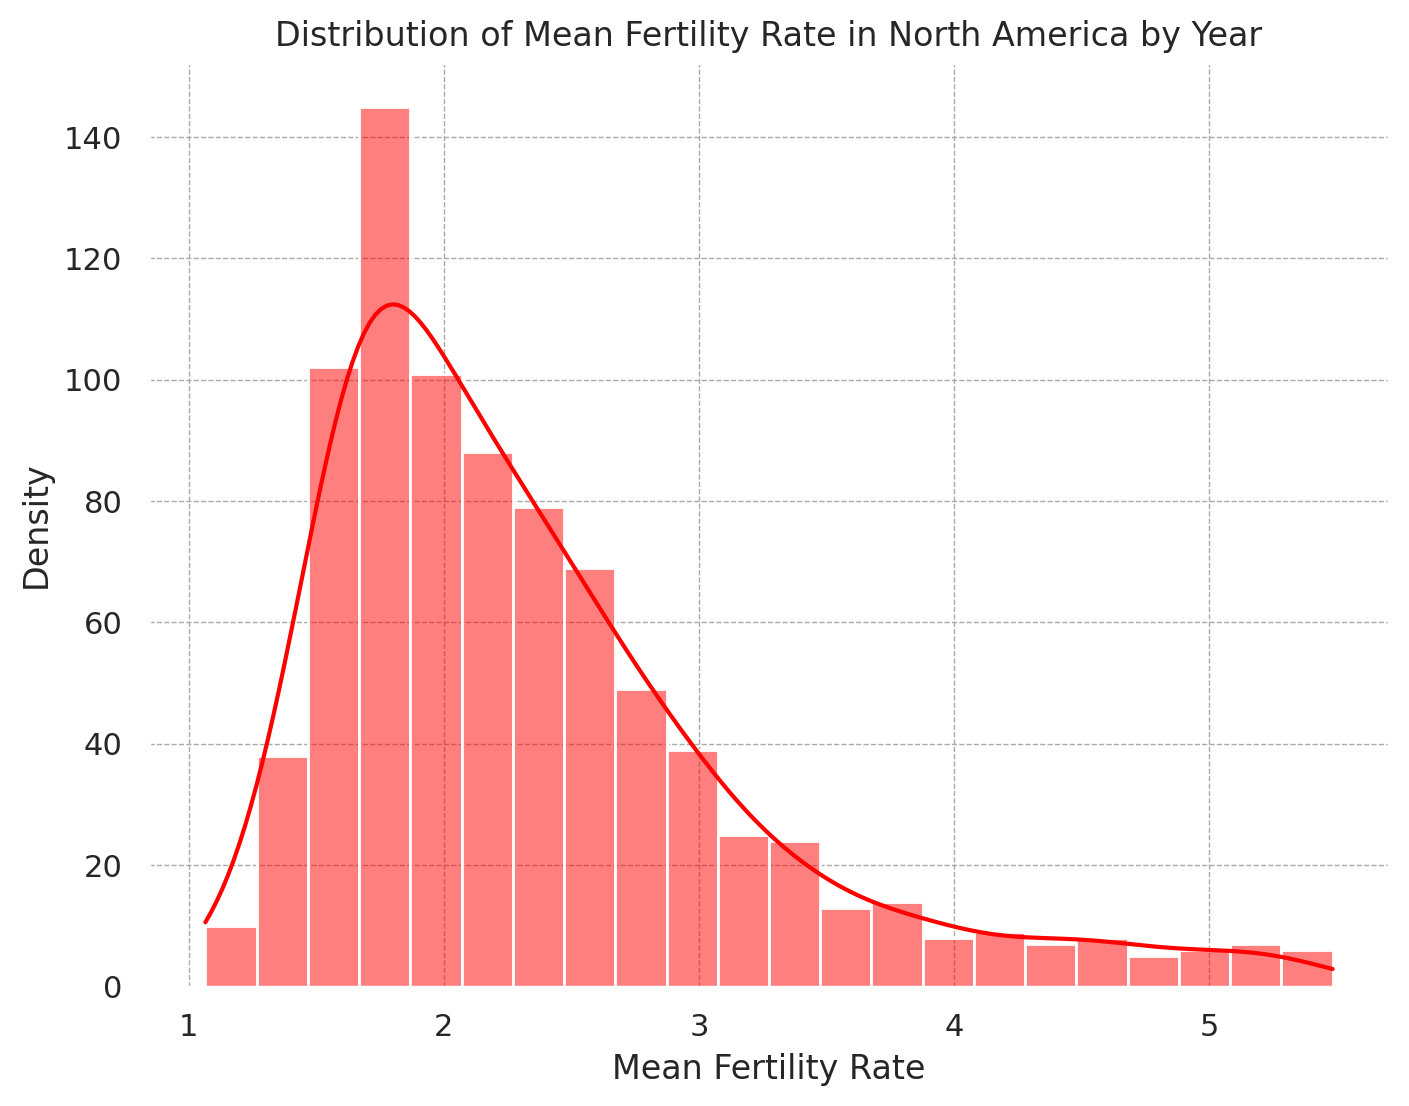

In [35]:
north_america_df = df_women_gdp[df_women_gdp['Continent'] == 'North America']

# Set the color palette
sns.set_palette("husl")

# Create distplot for GDP
plt.figure(figsize=(8, 6))
sns.histplot(data=north_america_df, x='GDP_Per_Capita', kde=True, color='blue')
plt.title('Distribution of Mean GDP per capita in North America by Year')
plt.xlabel('Mean GDP per capita (constant 2017 international $)')
plt.ylabel('Density')

plt.gca().set_facecolor('white')

plt.grid(color='darkgrey', linestyle='dashed', linewidth=0.5)

plt.show()

# Create distplot for Fertility Rate
plt.figure(figsize=(8, 6))
sns.histplot(data=north_america_df, x='Fertility_rate', kde=True, color='red')
plt.title('Distribution of Mean Fertility Rate in North America by Year')
plt.xlabel('Mean Fertility Rate')
plt.ylabel('Density')

plt.gca().set_facecolor('white')

plt.grid(color='darkgrey', linestyle='dashed', linewidth=0.5)

plt.show()


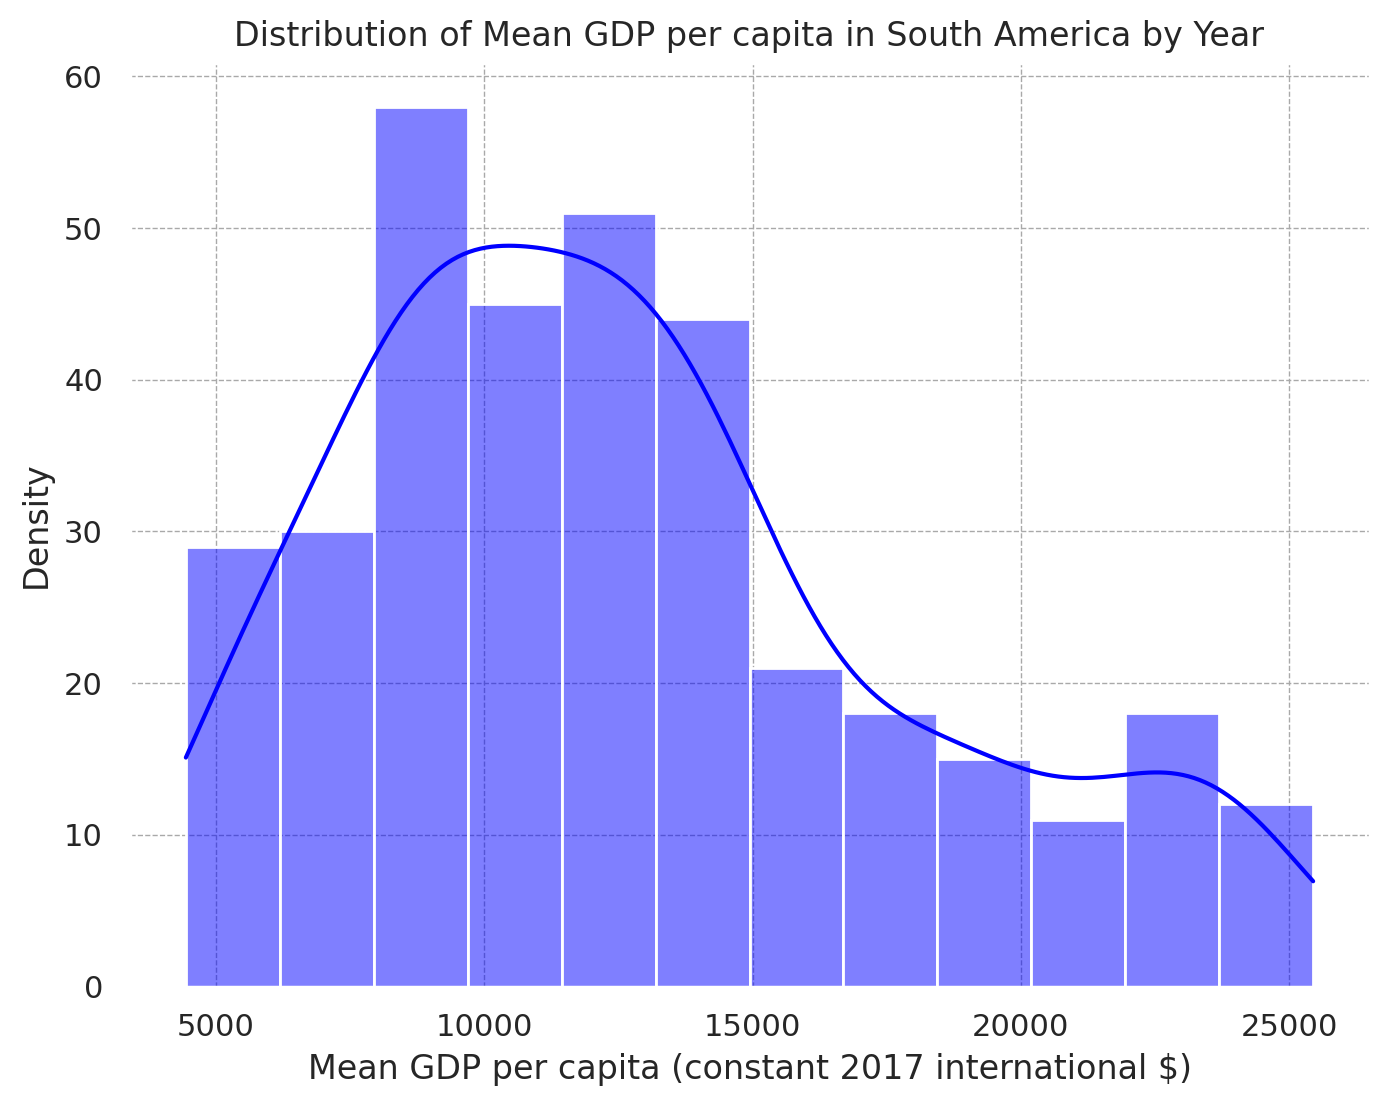

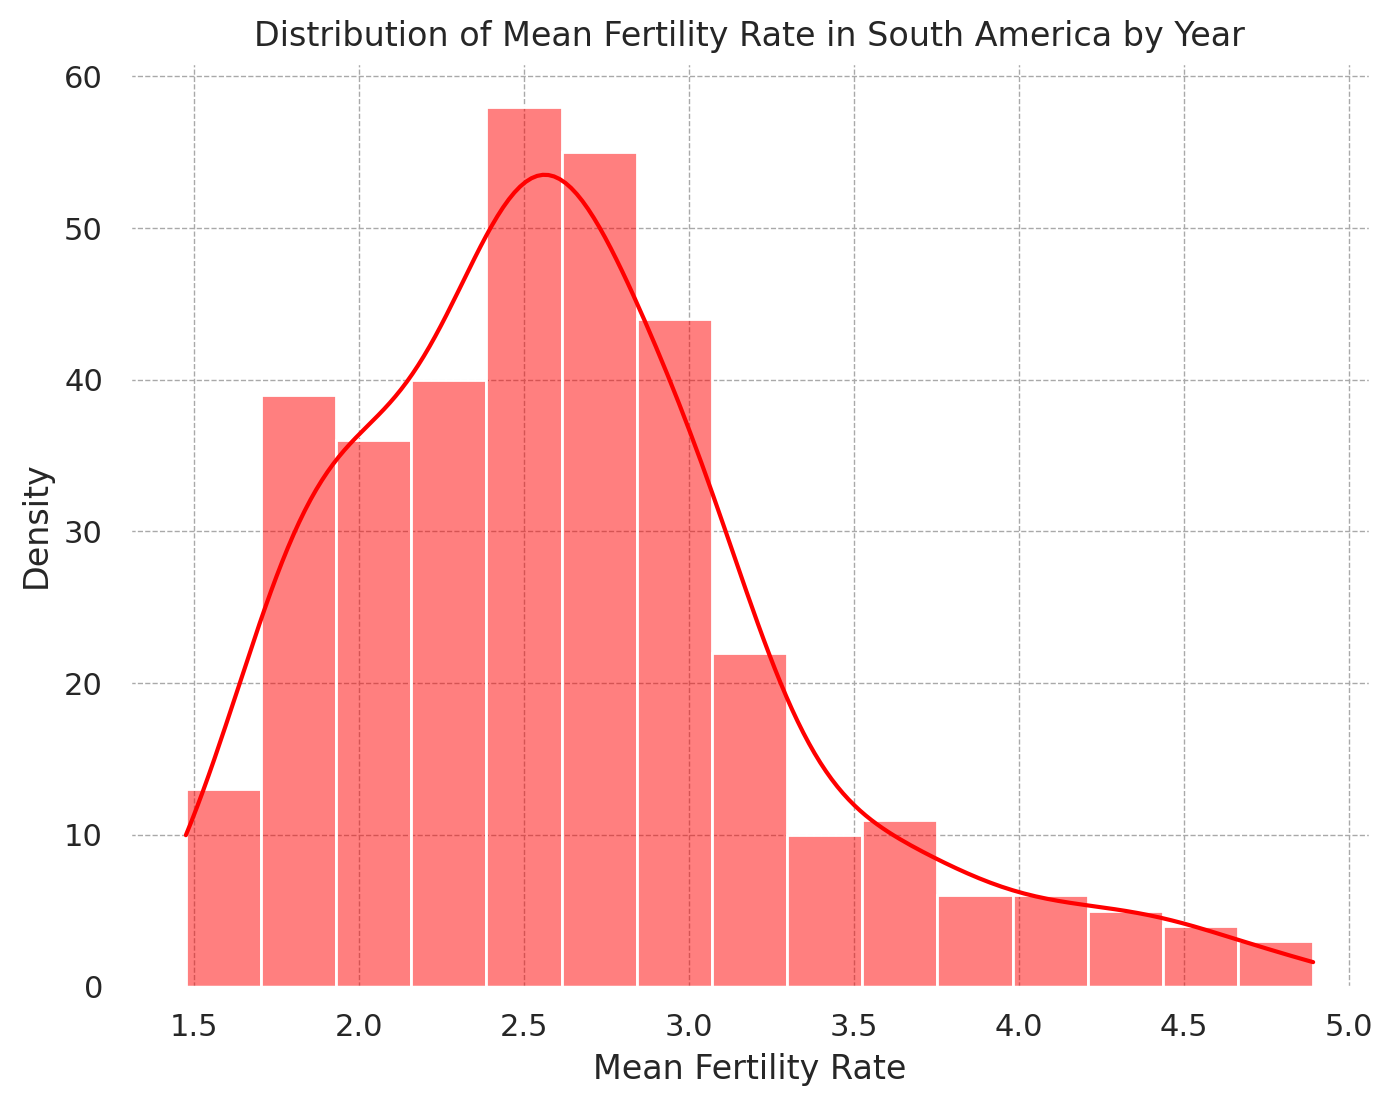

In [36]:
south_america_df = df_women_gdp[df_women_gdp['Continent'] == 'South America']

# Set the color palette
sns.set_palette("husl")

# Create distplot for GDP
plt.figure(figsize=(8, 6))
sns.histplot(data=south_america_df, x='GDP_Per_Capita', kde=True, color='blue')
plt.title('Distribution of Mean GDP per capita in South America by Year')
plt.xlabel('Mean GDP per capita (constant 2017 international $)')
plt.ylabel('Density')

plt.gca().set_facecolor('white')

plt.grid(color='darkgrey', linestyle='dashed', linewidth=0.5)

plt.show()

# Create distplot for Fertility Rate
plt.figure(figsize=(8, 6))
sns.histplot(data=south_america_df, x='Fertility_rate', kde=True, color='red')
plt.title('Distribution of Mean Fertility Rate in South America by Year')
plt.xlabel('Mean Fertility Rate')
plt.ylabel('Density')

plt.gca().set_facecolor('white')

plt.grid(color='darkgrey', linestyle='dashed', linewidth=0.5)

plt.show()


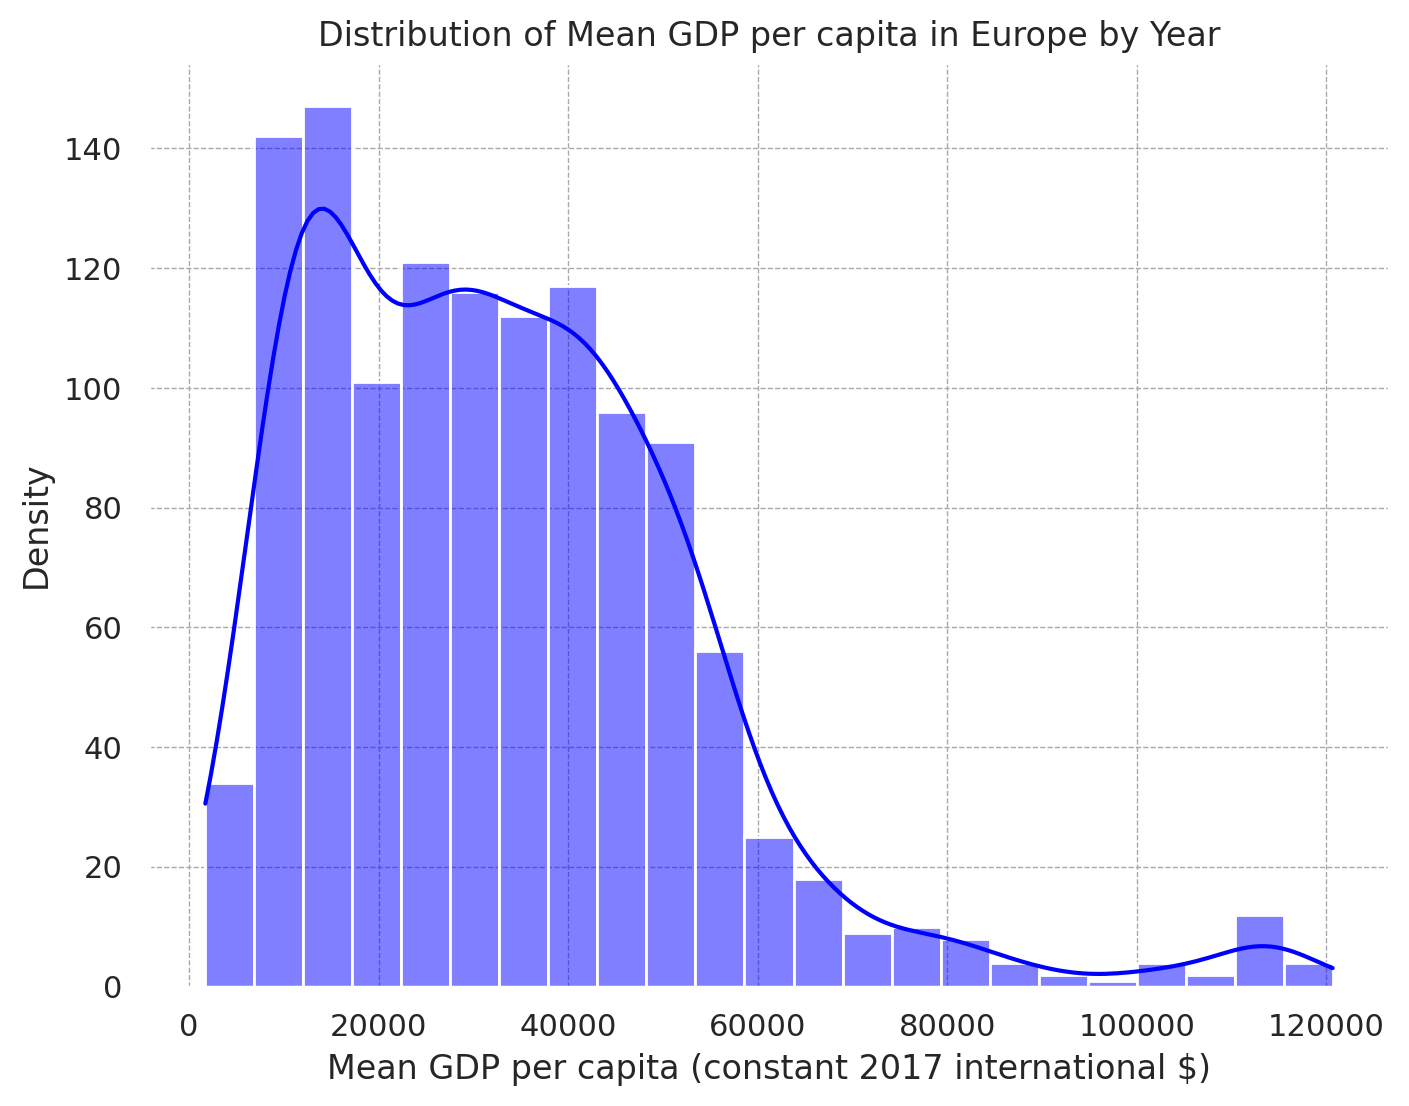

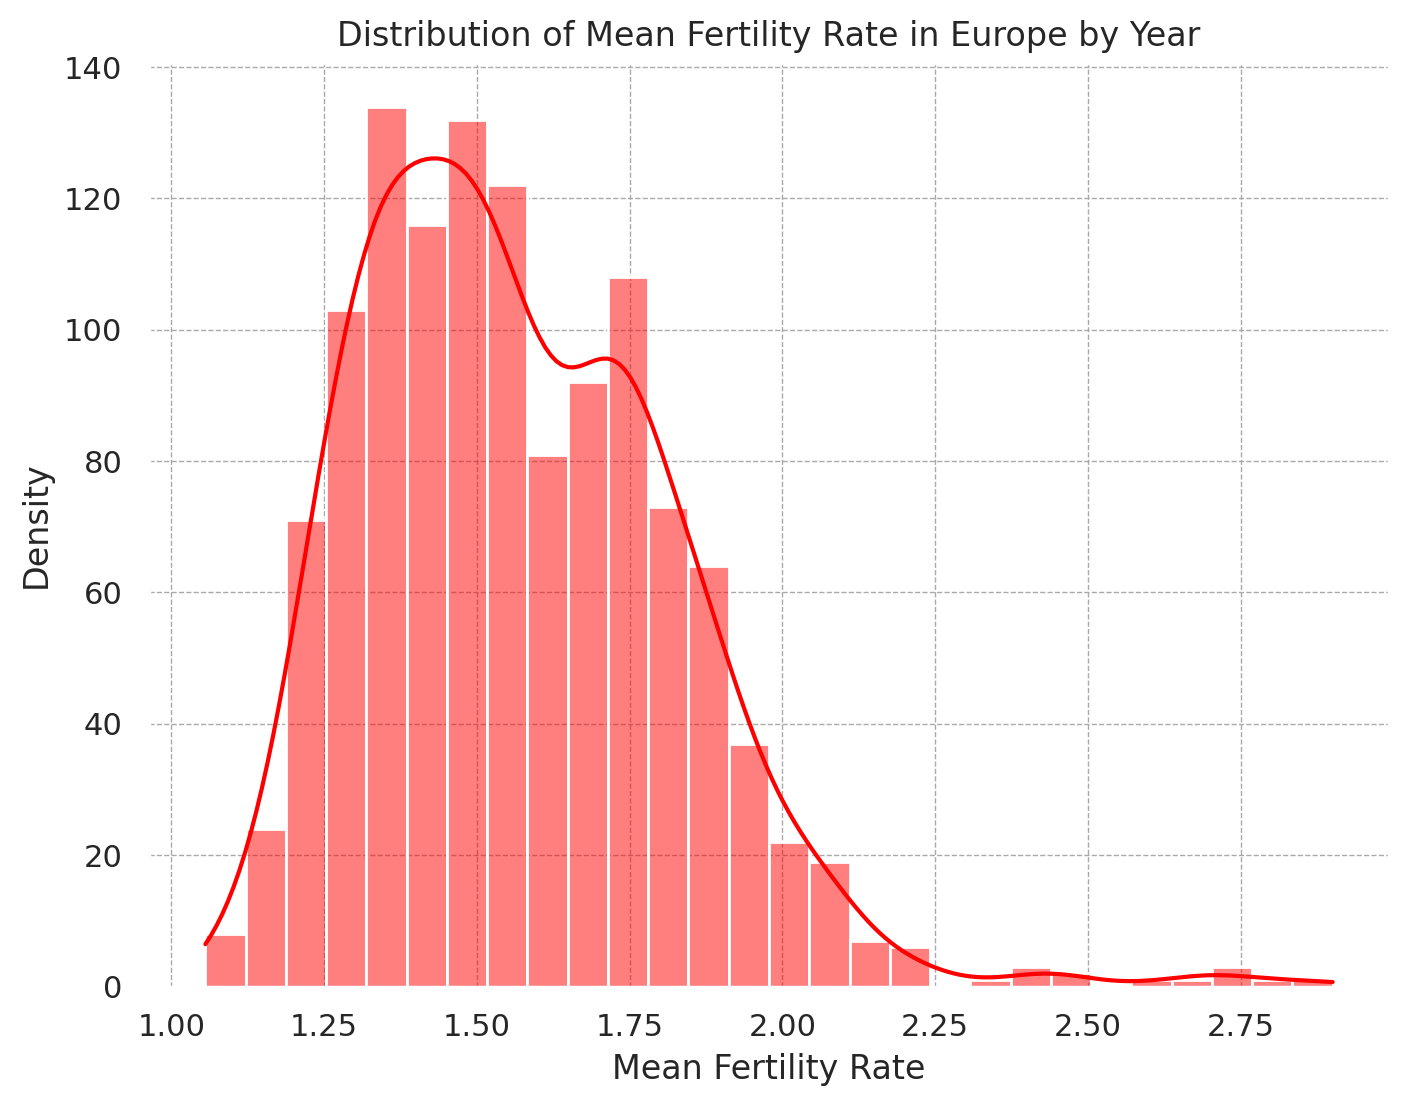

In [37]:
europe_df = df_women_gdp[df_women_gdp['Continent'] == 'Europe']

# Set the color palette
sns.set_palette("husl")

# Create distplot for GDP
plt.figure(figsize=(8, 6))
sns.histplot(data=europe_df, x='GDP_Per_Capita', kde=True, color='blue')
plt.title('Distribution of Mean GDP per capita in Europe by Year')
plt.xlabel('Mean GDP per capita (constant 2017 international $)')
plt.ylabel('Density')

plt.gca().set_facecolor('white')

plt.grid(color='darkgrey', linestyle='dashed', linewidth=0.5)

plt.show()

# Create distplot for Fertility Rate
plt.figure(figsize=(8, 6))
sns.histplot(data=europe_df, x='Fertility_rate', kde=True, color='red')
plt.title('Distribution of Mean Fertility Rate in Europe by Year')
plt.xlabel('Mean Fertility Rate')
plt.ylabel('Density')

plt.gca().set_facecolor('white')

plt.grid(color='darkgrey', linestyle='dashed', linewidth=0.5)

plt.show()


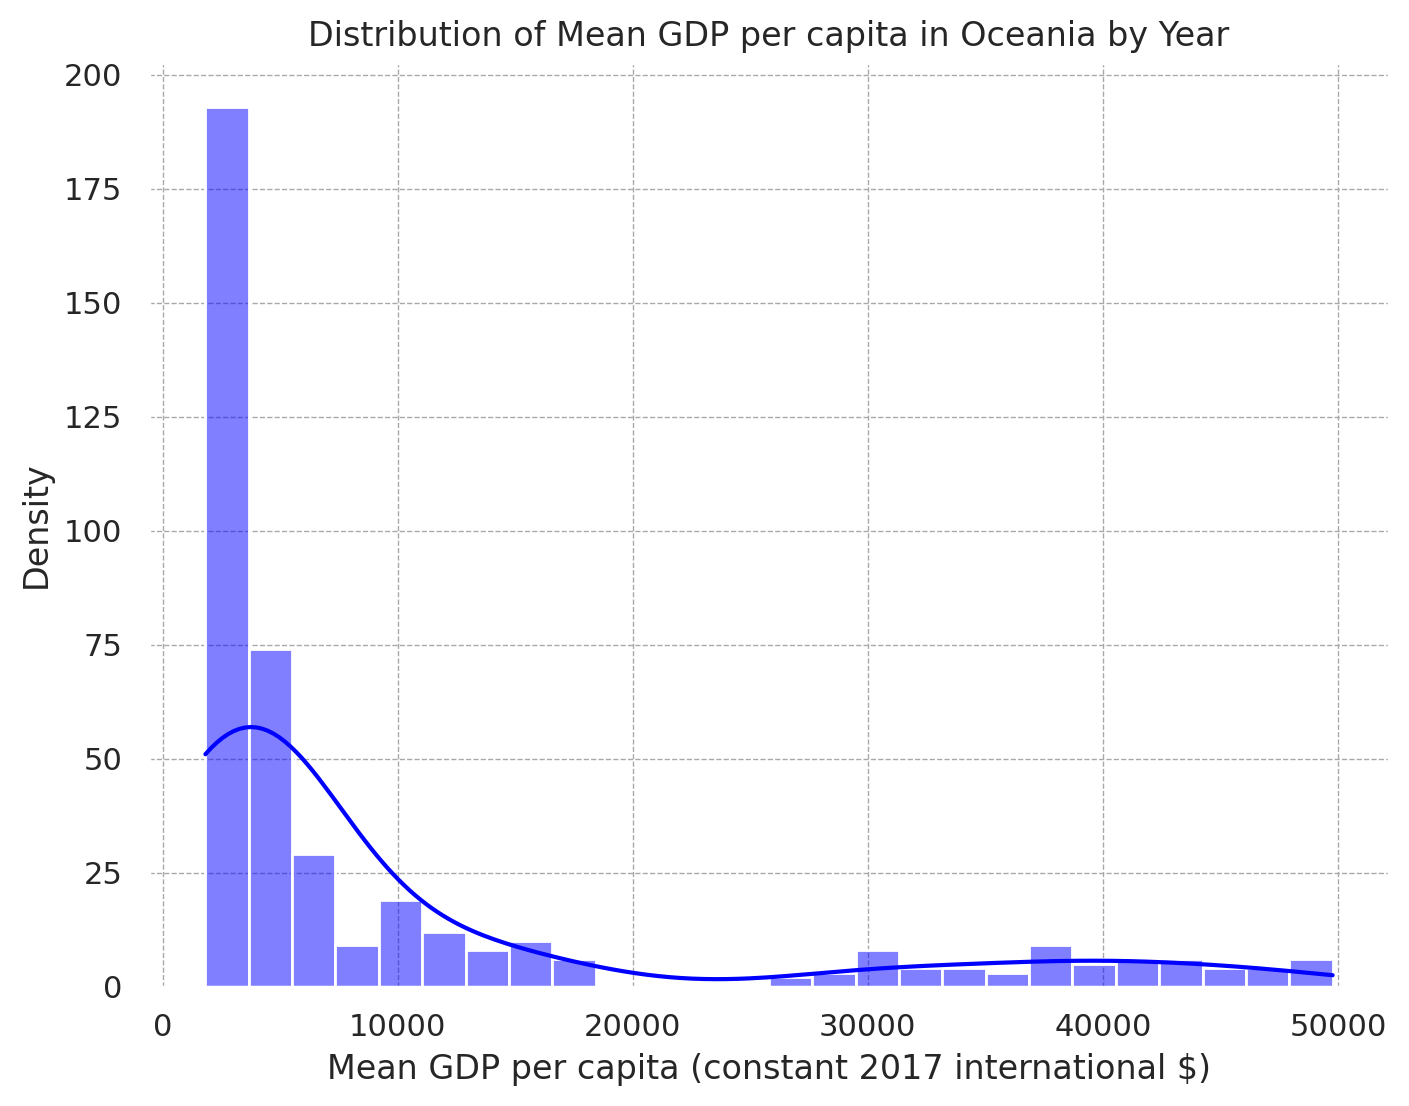

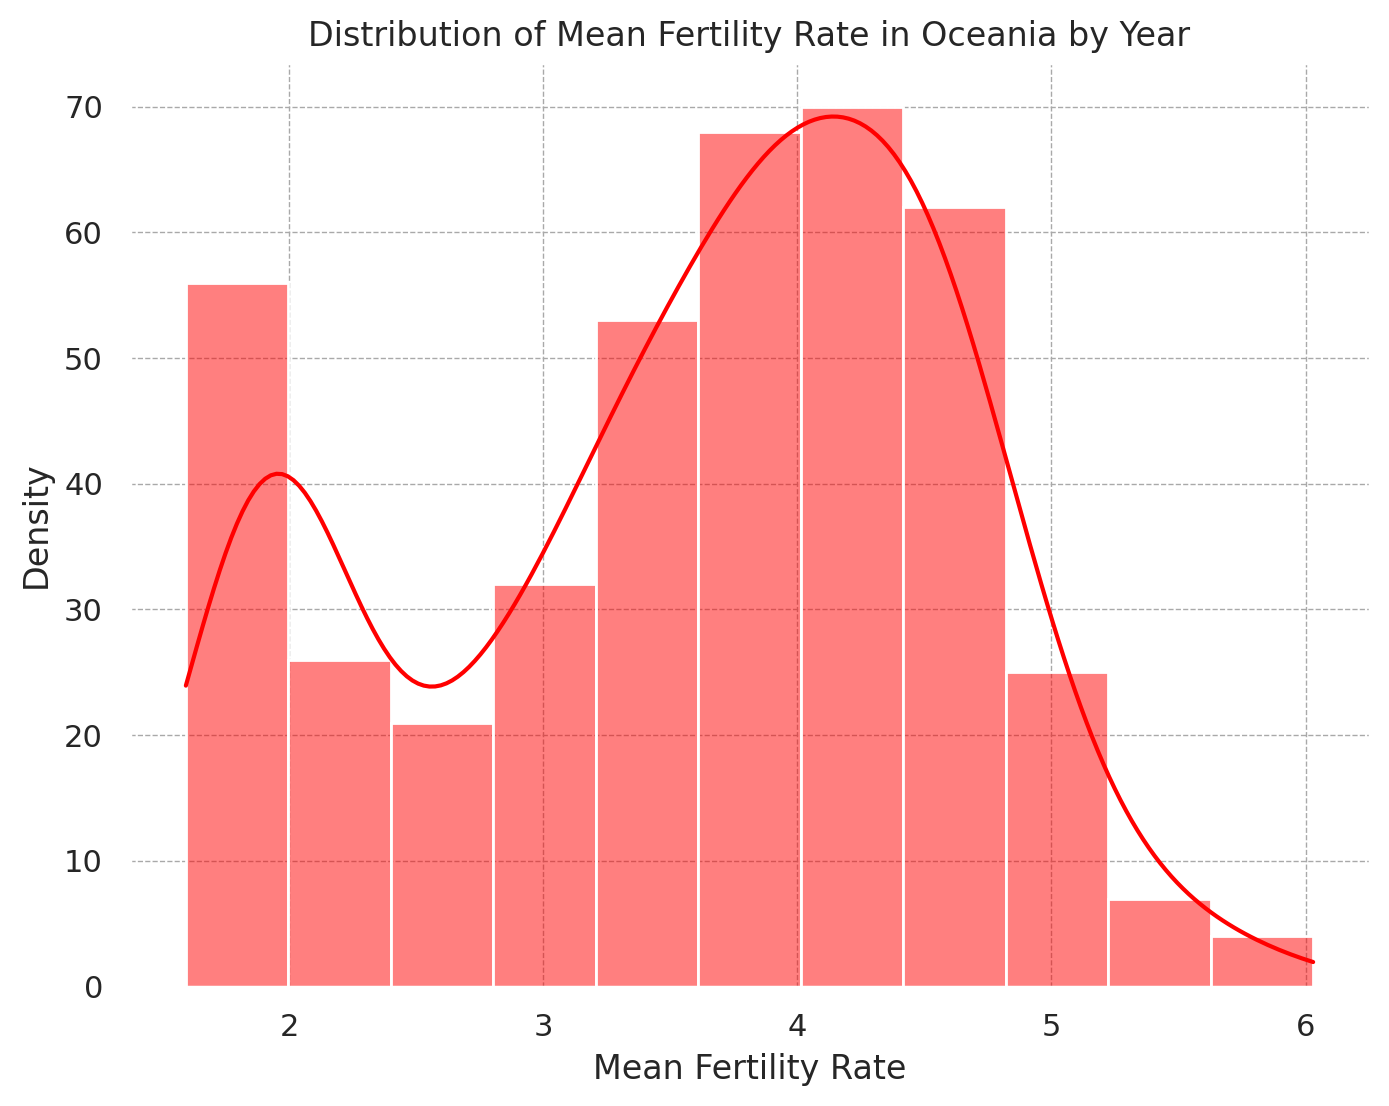

In [38]:
oceania_df = df_women_gdp[df_women_gdp['Continent'] == 'Oceania']

# Set the color palette
sns.set_palette("husl")

# Create distplot for GDP
plt.figure(figsize=(8, 6))
sns.histplot(data=oceania_df, x='GDP_Per_Capita', kde=True, color='blue')
plt.title('Distribution of Mean GDP per capita in Oceania by Year')
plt.xlabel('Mean GDP per capita (constant 2017 international $)')
plt.ylabel('Density')

plt.gca().set_facecolor('white')

plt.grid(color='darkgrey', linestyle='dashed', linewidth=0.5)

plt.show()

# Create distplot for Fertility Rate
plt.figure(figsize=(8, 6))
sns.histplot(data=oceania_df, x='Fertility_rate', kde=True, color='red')
plt.title('Distribution of Mean Fertility Rate in Oceania by Year')
plt.xlabel('Mean Fertility Rate')
plt.ylabel('Density')

plt.gca().set_facecolor('white')

plt.grid(color='darkgrey', linestyle='dashed', linewidth=0.5)

plt.show()


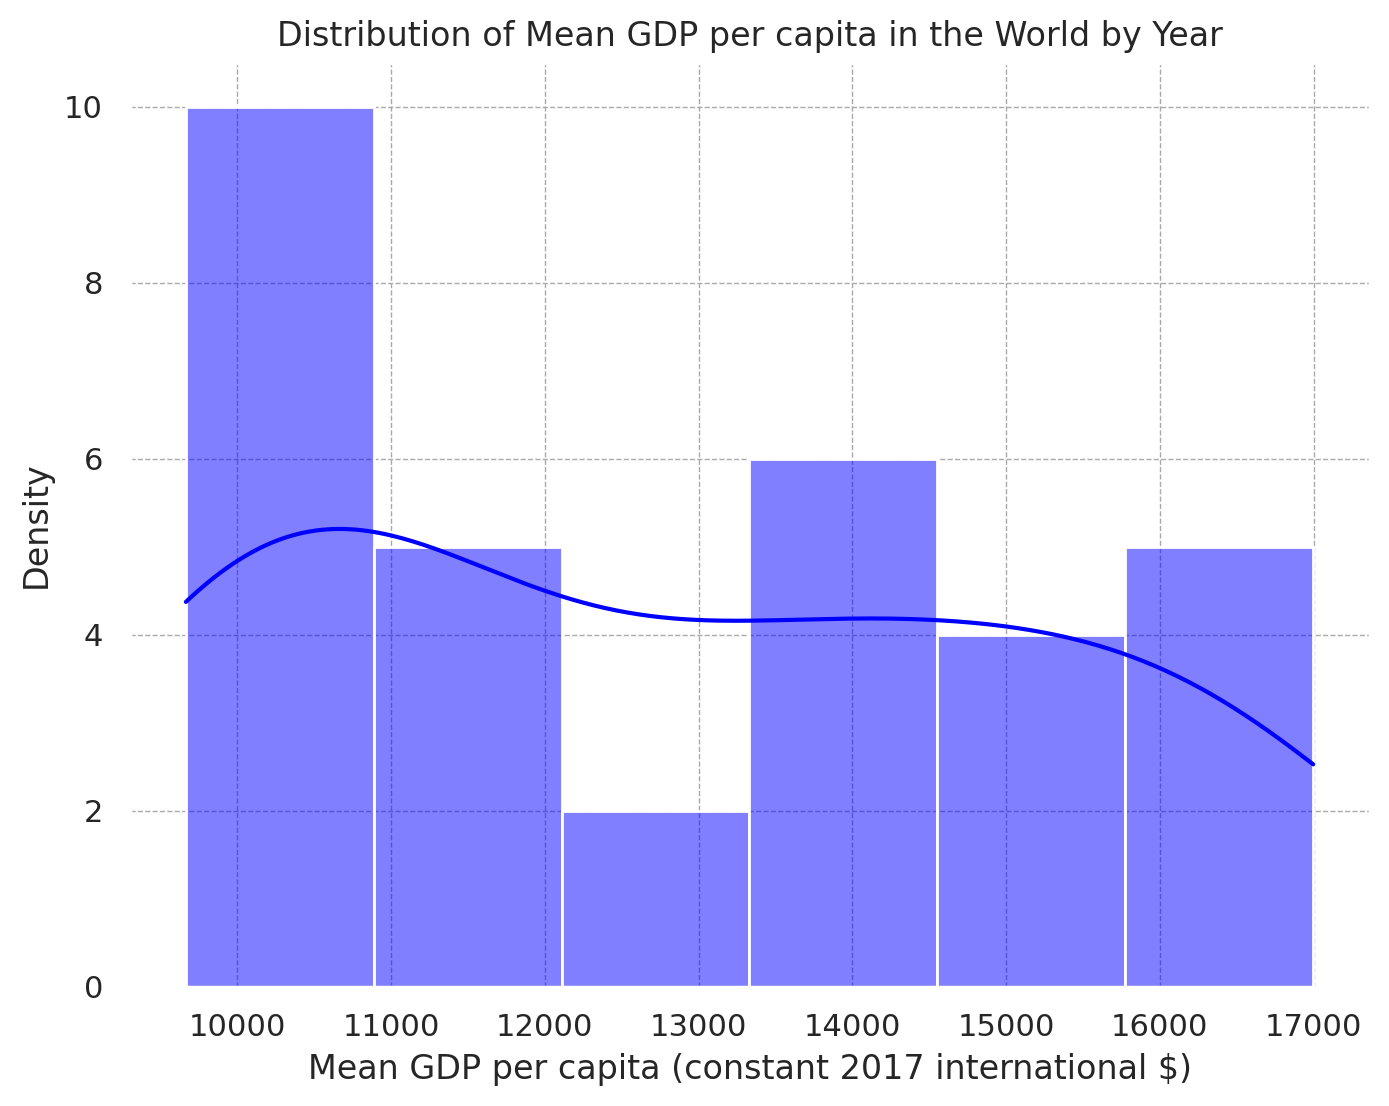

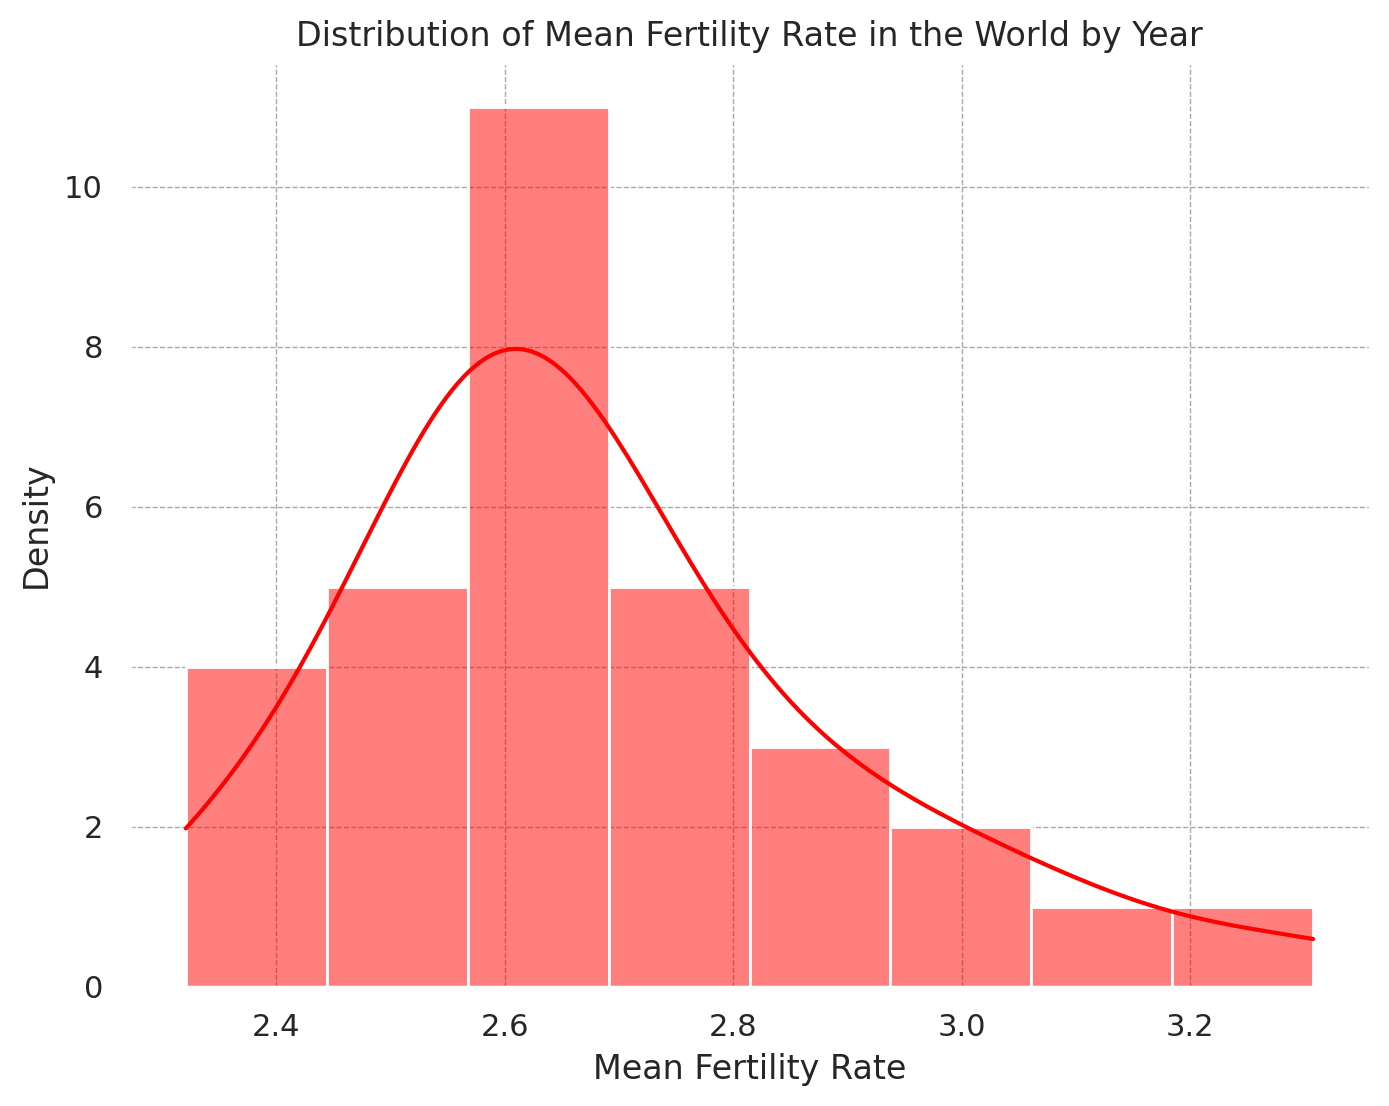

In [39]:
world_df = df_women_gdp[df_women_gdp['Continent'] == 'World']

# Set the color palette
sns.set_palette("husl")

# Create distplot for GDP
plt.figure(figsize=(8, 6))
sns.histplot(data=world_df, x='GDP_Per_Capita', kde=True, color='blue')
plt.title('Distribution of Mean GDP per capita in the World by Year')
plt.xlabel('Mean GDP per capita (constant 2017 international $)')
plt.ylabel('Density')

plt.gca().set_facecolor('white')

plt.grid(color='darkgrey', linestyle='dashed', linewidth=0.5)

plt.show()

# Create distplot for Fertility Rate
plt.figure(figsize=(8, 6))
sns.histplot(data=world_df, x='Fertility_rate', kde=True, color='red')
plt.title('Distribution of Mean Fertility Rate in the World by Year')
plt.xlabel('Mean Fertility Rate')
plt.ylabel('Density')

plt.gca().set_facecolor('white')

plt.grid(color='darkgrey', linestyle='dashed', linewidth=0.5)

plt.show()
